# Notebook 02 (Model B) — XGBoost Final Report Champion Comparison Against Logistic Regression — v10

**Module:** ITI113 Machine Learning & Operations  
**Team:** Team 2 - Explainable Diabetes Risk Screening  
**Focus Area:** B - Model Development (XGBoost) + AI Governance (fairness, explainability)  
**Primary ownership:** Fong Siang Yi (s202_8440104B) — Data & EDA and Model B: XGBoost  
**Model A evidence:** `02_Logistic_Regression_Experiments_MLflow_with_Evidence.ipynb` / `S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv`  
**Model B evidence:** `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` — current v10 evidence export  
**Comparison model:** XGBoost

---

## Objective

The lecturer's requirement is to use **Logistic Regression as Model A / baseline** and evaluate whether
**XGBoost provides a measurable improvement** under a controlled, apples-to-apples experiment.

The comparison therefore controls the following:

- **same cleaned S3 dataset**
- **same target definition**
- **same `DATA_PROFILE`**
- **same `RANDOM_STATE = 42`**
- **same deterministic stratified 80/20 split**
- **same Stratified 5-Fold CV validation framework**
- **same primary model-selection metric: PR-AUC**
- **training-only / out-of-fold threshold selection**
- **same held-out test rows for the final side-by-side comparison**

This notebook does **not** treat the untuned XGBoost configuration as another baseline. Logistic
Regression is the project baseline. The untuned XGBoost run is only a **reference configuration**
used to show whether XGBoost tuning improves the challenger itself.

The final question answered by this notebook is:

> **Does the tuned XGBoost challenger outperform the final Logistic Regression Model A when both are
> evaluated on the same held-out observations under the predefined PR-AUC-primary decision rule?**

> **Important methodological note:** Model A and Model B both use an 80% training / 20% held-out test
> design, with cross-validation acting as the training-stage validation mechanism. If the lecturer
> requires a literal train/validation/test three-way split, **both model notebooks must be changed
> together**.

## What this notebook does

1. Connects to the team's SageMaker MLflow App and validates the TeamId resource tag.
2. Recreates the common data sampling and stratified 80/20 split.
3. Generates reproducibility signatures for the dataset profile, training rows and test rows.
4. Logs an untuned **XGBoost reference configuration** for internal comparison only.
5. Runs a focused **30-candidate XGBoost tuning search** using training-only 5-fold CV.
6. Refines `n_estimators` using training-only cross-validation.
7. Selects the XGBoost threshold from out-of-fold training probabilities only.
8. Evaluates the tuned XGBoost challenger on the held-out test set.
9. Performs structured held-out error analysis.
10. Logs SHAP explanations and subgroup fairness evidence.
11. **Pins the Logistic Regression comparison to the Final Report evidence run**
    `82bc9a4720e04a50ae942128305eb90d`, verifies its candidate/threshold lineage, loads its model
    artifact, and re-scores it on this notebook's exact `X_test / y_test` rows.
12. Validates the live LR result against the locked LR evidence values and validates the live XGBoost
    execution against a locked Model B reference evidence snapshot. The refreshed
    `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` is retained as the **current v10 MLflow evidence
    export** for the execution recorded in this notebook.
13. Produces the direct Model A vs Model B comparison and applies the **predefined held-out PR-AUC
    champion rule**, with recall/FNR and other secondary trade-offs explicitly documented.

### v10 evidence-lock and current-export linkage

v9's saved comparison used an older unweighted LR run (`5915855b52af4f8e97be9637dc6e2e86`,
threshold `0.21`). v10 supersedes that historical comparison and uses the latest balanced LR evidence:

- **Logistic Regression final run:** `82bc9a4720e04a50ae942128305eb90d`
- **LR selected candidate:** `74e8884c230349f3ad29021db15f54a2` (`C=100`, `class_weight="balanced"`)
- **LR threshold:** `0.59`
- **LR held-out PR-AUC:** `0.432749`

For Model B, two XGBoost identifiers have different provenance roles and should not be confused:

- **Locked XGBoost reference evidence run:** `dca27f6422344d249069ab863b1541fa`
  - used by the v10 evidence-lock constants as the reproducibility reference;
  - reference held-out PR-AUC: `0.464397`.
- **Current v10 final XGBoost execution:** `057bb58d81564c0db9a628b224eab8f9`
  - recorded in the refreshed `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv`;
  - experiment batch: `20260822T033734Z`;
  - selected candidate: `02807641d2814f48a084c7c451414917` (`xgb_candidate_29`);
  - `n_estimators` refinement run: `e89987fd9aec4a11a1108c8afaf6561b`;
  - threshold-tuning run: `a1a47bcc23d844539d92f3a3ed8fec1e`;
  - threshold: `0.50`;
  - held-out PR-AUC: `0.464397`.

The current v10 execution reproduces the locked XGBoost reference configuration and final metrics.
Therefore, for the **Final Report submission evidence chain**, the refreshed
`S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` is the evidence export that should be retained
together with this executed notebook.

The historical cross-model champion tags inside older XGBoost exports are not used as the authoritative
Model A vs Model B decision because they were written against the older LR run. v10 recomputes the
champion against the latest balanced LR evidence.

- **PR-AUC delta (XGBoost − LR):** `+0.031649`
- **Final champion under the predefined primary metric:** **XGBoost**

### Fair-comparison principle

Algorithm-specific preprocessing and tuning may differ because Logistic Regression and XGBoost are
different algorithms. Apples-to-apples means the **data rows, target, validation discipline,
evaluation metrics, threshold-selection discipline and held-out comparison set** are controlled.

---

### v10 Final Champion decision policy

For the Final Report, **held-out PR-AUC is the predefined primary champion metric**. Recall/FNR, F2,
calibration (Brier score), subgroup fairness and other secondary measures remain mandatory
interpretation/governance evidence, but they do **not become new post-hoc hard blockers** unless the
team's original Proposal explicitly defined them as hard acceptance criteria before the final
held-out results were observed.


## Rubric alignment (Proficient tier, ITI113 Project Guide)

This notebook is structured so that each graded criterion has a concrete, inspectable artifact, not
just a claim in the report.

| Rubric criterion (Proficient band) | Evidence in this notebook |
| --- | --- |
| **Modelling (10%)** - excellent discussion of algorithm choice, experimental results, tuning and error analysis | Sections 5-9: XGBoost reference configuration, 30-candidate tuning search, cross-validated boosting-round refinement, threshold optimisation and final held-out evaluation. Section 11 adds confusion-matrix-level error analysis (representative false positives/negatives, borderline cases) and explains why each error type matters for the screening application. |
| **Data (10%)** - strong analysis and bias consideration | Section 3 recreates the identical Logistic Regression data profile and split; Section 11.4 examines subgroup error concentration (raw counts/shares) and Section 13 evaluates subgroup fairness rates, both by Sex, Age, Education and Income. |
| **MLOps Pipeline** - experiment tracking, reproducibility and model registry | Reference run, 30 tuning candidates, early stopping, threshold tuning, final holdout, error analysis, SHAP and fairness evidence are logged to SageMaker MLflow. Section 16 registers the champion when appropriate, and Section 18 records the environment. |
| **AI Governance Checklist** - risks, bias, explainability and mitigation | Section 11 provides confusion-matrix-level error analysis (incl. subgroup error concentration); Section 12 provides SHAP explanations; Section 13 checks subgroup fairness gaps; Sections 14-15 compare the challenger against the Logistic Regression baseline and apply a governance-aware selection rule. |
| **Problem Formulation / Overall Report** - clear baseline and evaluation metrics | Section 14 makes Logistic Regression the primary ML baseline and XGBoost the challenger, using a full metric suite (PR-AUC, recall, precision, F1/F2, specificity, FPR) rather than accuracy alone. Majority-class and rule-based approaches are retained only as supporting benchmarks. |
| **Test Report** - fairness, explainability and robustness testing with interpretation, not just screenshots | Appendix B (after Section 18): B1 formalises AI-Verify-aligned fairness metrics (Disparate Impact Ratio, Equal Opportunity Difference, Equalized Odds Difference, Predictive-Parity/FDR gap); B2 adds a SHAP explanation-stability check, a face-validity check on representative error cases, and an XGBoost-vs-LR driver comparison; B3 adds perturbation, missing-value, and determinism/consistency robustness testing. Every test includes a written Findings & Interpretation discussion, not only the metric/plot. |

**Assessment-ready comparison statement:** Logistic Regression is the baseline model. XGBoost is the
challenger model. A champion should only be selected after both are evaluated on the same held-out
rows with the same performance metrics and documented governance checks.

In [1]:
# Install/check only the SageMaker MLflow integration.
# Do NOT force-upgrade boto3, botocore, or the SageMaker SDK in the shared
# SageMaker Studio kernel; doing so can break preinstalled Studio packages.

%pip install -q sagemaker-mlflow

print("sagemaker-mlflow installation/check completed.")
print("If pip installed or changed a package, restart the kernel once before continuing.")

Note: you may need to restart the kernel to use updated packages.
sagemaker-mlflow installation/check completed.
If pip installed or changed a package, restart the kernel once before continuing.


In [2]:
# Install the two packages this notebook adds on top of the LR baseline:
#   - xgboost : gradient-boosted trees (Model B)
#   - shap    : model explainability required by the project proposal before
#               XGBoost can be approved for serving
#
# Versions are pinned to avoid silent behavioural drift between runs and
# between teammates' environments — a production-readiness practice, not
# just a classroom nicety.
#
# NOTE: shap<0.47 raises `TypeError: Converting np.inexact or np.floating to
# a dtype is not allowed` on import when numpy>=2.0 is present (a known
# shap/numpy-2.0 incompatibility in its vendored colour-conversion module,
# fixed in shap 0.47.0 - see shap release notes / GitHub #3785). The pin
# below was moved up to include that fix.

%pip install -q "xgboost>=2.0,<3.0" "shap>=0.47,<0.49"

print("xgboost and shap installation/check completed.")
print("If pip installed or changed a package, RESTART THE KERNEL once before continuing.")

Note: you may need to restart the kernel to use updated packages.
xgboost and shap installation/check completed.
If pip installed or changed a package, RESTART THE KERNEL once before continuing.


In [3]:
# Verify the packages used by this notebook without changing the AWS SDK stack.
import importlib.metadata as metadata
import boto3
import botocore
import mlflow

print("boto3            :", boto3.__version__)
print("botocore         :", botocore.__version__)
print("mlflow           :", mlflow.__version__)

for pkg in ["sagemaker-mlflow", "xgboost", "shap"]:
    try:
        print(f"{pkg:<17}:", metadata.version(pkg))
    except metadata.PackageNotFoundError:
        raise RuntimeError(
            f"{pkg} is not installed. Run the previous cells, restart the kernel, "
            "then continue."
        )

boto3            : 1.43.78
botocore         : 1.43.78
mlflow           : 3.15.1
sagemaker-mlflow : 0.5.0
xgboost          : 2.1.4
shap             : 0.48.0


## 0. Configuration

In [4]:
import json
from pathlib import Path
from datetime import datetime, timezone

import boto3

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team02"
STUDENT_ID = "s202"     # IMPORTANT: confirm this is the actual Model B owner/student identifier before submission

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "diabetes"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42          # Must match the LR notebook exactly for a fair comparison
MODEL_FAMILY = "XGBoost"

# A unique identifier lets this notebook compare only runs created
# in THIS execution, instead of accidentally selecting an old run.
EXPERIMENT_BATCH_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

# ============================================================
# AWS runtime identity — boto3 only, SDK-v2/v3 independent
# ============================================================
aws_session = boto3.Session(region_name=REGION)
sts_client = aws_session.client("sts")
sm_client = aws_session.client("sagemaker")

CALLER = sts_client.get_caller_identity()
ACCOUNT_ID = CALLER["Account"]
CALLER_ARN = CALLER["Arn"]

EXPECTED_ROLE_NAME = "SageMakerExecutionRole-ITI113-Team02"
if EXPECTED_ROLE_NAME not in CALLER_ARN:
    print(
        "[WARNING] The active AWS caller does not appear to be the Team02 SageMaker role.\n"
        f"Expected role name: {EXPECTED_ROLE_NAME}\n"
        f"Active caller ARN : {CALLER_ARN}\n"
        "Confirm that this notebook is running from the Team02 SageMaker profile."
    )

# ============================================================
# MLflow App config
# ============================================================
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")
TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")

config_candidates = [
    STUDENT_CONFIG_FILE,
    TEAM_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        candidate = json.loads(config_file.read_text(encoding="utf-8"))
        candidate_team = candidate.get("TEAM_ID") or candidate.get("team_id")
        candidate_project = candidate.get("PROJECT_NAME") or candidate.get("project_name")

        if candidate_team and candidate_team != TEAM_ID:
            continue
        if candidate_project and candidate_project != PROJECT_NAME:
            continue

        mlflow_app_config = candidate
        MLFLOW_APP_ARN = candidate.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = candidate.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# If the local config file is unavailable, discover the Team02 App by name.
MLFLOW_APP_NAME = f"iti113-26s1-{TEAM_ID}-mlflow-app"

if MLFLOW_APP_ARN is None:
    paginator = sm_client.get_paginator("list_mlflow_apps")
    for page in paginator.paginate():
        matches = [
            summary for summary in page.get("Summaries", [])
            if summary.get("Name") == MLFLOW_APP_NAME
        ]
        if matches:
            MLFLOW_APP_ARN = matches[0]["Arn"]
            print(f"Discovered MLflow App by name: {MLFLOW_APP_NAME}")
            break

if MLFLOW_APP_ARN is None:
    raise RuntimeError(
        f"Could not find the Team02 MLflow App {MLFLOW_APP_NAME!r}. "
        "Run the corrected MLflow setup notebook first."
    )

if config_used is not None:
    print(f"Loaded MLflow App config from {config_used}")

print("=" * 72)
print("ITI113 Diabetes Experiments — XGBoost (Model B) — SageMaker MLflow App")
print("=" * 72)
print(f"Team                : {TEAM_ID}")
print(f"Student             : {STUDENT_ID}")
print(f"Model family        : {MODEL_FAMILY}")
print(f"Project             : {PROJECT_NAME}")
print(f"S3 Prefix           : {PREFIX}")
print(f"MLflow App ARN      : {MLFLOW_APP_ARN}")
print(f"MLflow Experiment   : {MLFLOW_EXPERIMENT}")
print(f"Registered Model    : {REGISTERED_MODEL}")
print(f"Experiment Batch ID : {EXPERIMENT_BATCH_ID}")
print(f"AWS Caller          : {CALLER_ARN}")
print("=" * 72)


print("[CHECK] STUDENT_ID =", STUDENT_ID, "— confirm this matches the assessed Model B owner before final submission.")

Discovered MLflow App by name: iti113-26s1-team02-mlflow-app
ITI113 Diabetes Experiments — XGBoost (Model B) — SageMaker MLflow App
Team                : team02
Student             : s202
Model family        : XGBoost
Project             : diabetes
S3 Prefix           : iti113/team02/data/diabetes
MLflow App ARN      : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
MLflow Experiment   : ITI113/team02/Experiment1
Registered Model    : iti113-team02-diabetes
Experiment Batch ID : 20260822T033734Z
AWS Caller          : arn:aws:sts::044528205969:assumed-role/SageMakerExecutionRole-ITI113-Team02/SageMaker
[CHECK] STUDENT_ID = s202 — confirm this matches the assessed Model B owner before final submission.


## 1. Choose Dataset Profile

Set **one value only** in the next cell:

```text
quick = 10%
fast  = 25%
half  = 50%
large = 75%
full  = 100%
```

The selected subset is sampled **before** the train/test split using stratification on
`Diabetes_binary` — identical mechanism to the Logistic Regression notebook.

> 🧑‍💻 **Mentor note:** For an apples-to-apples comparison, run this notebook with the **same
> `DATA_PROFILE`** you used for the final Logistic Regression run. Comparing a `full`-profile XGBoost
> run against a `quick`-profile LR run is a common (and easy-to-miss) source of an invalid conclusion.

In [5]:
# ============================================================
# USER-SELECTABLE DATASET PROFILE
# ============================================================
#
# Change ONLY DATA_PROFILE to one of:
#   "quick" -> 10%
#   "fast"  -> 25%
#   "half"  -> 50%
#   "large" -> 75%
#   "full"  -> 100%
#
# IMPORTANT: use the SAME profile as the final Logistic Regression run
# so the two models are compared on identical data volumes.
# ============================================================

DATA_PROFILE = "full"

DATA_PROFILES = {
    "quick": {"fraction": 0.10, "description": "10% quick-development profile"},
    "fast":  {"fraction": 0.25, "description": "25% fast experiment profile"},
    "half":  {"fraction": 0.50, "description": "50% half-dataset profile"},
    "large": {"fraction": 0.75, "description": "75% near-full profile"},
    "full":  {"fraction": 1.00, "description": "100% full-scale profile"},
}

if DATA_PROFILE not in DATA_PROFILES:
    raise ValueError(
        f"Unknown DATA_PROFILE={DATA_PROFILE!r}. "
        f"Choose one of: {list(DATA_PROFILES)}"
    )

PROFILE_FRACTION = DATA_PROFILES[DATA_PROFILE]["fraction"]
PROFILE_DESCRIPTION = DATA_PROFILES[DATA_PROFILE]["description"]

print("Dataset profile selected")
print(f"  Profile     : {DATA_PROFILE}")
print(f"  Fraction    : {PROFILE_FRACTION:.0%}")
print(f"  Description : {PROFILE_DESCRIPTION}")

Dataset profile selected
  Profile     : full
  Fraction    : 100%
  Description : 100% full-scale profile


## 2. Connect to SageMaker MLflow App (Team-Tag Safety Check)

In [6]:
import mlflow
import boto3

# ============================================================
# Safety check for team-level MLflow restriction
# ------------------------------------------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before any logging occurs.
# ============================================================

try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, "
            f"notebook TEAM_ID={TEAM_ID}. Do not log to another team's MLflow App."
        )

    print(f"\n[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,          # kept for compatibility with previous notebooks
    "student": STUDENT_ID,    # kept for compatibility with previous notebooks
    "dataset": PROJECT_NAME,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
    "experiment_batch_id": EXPERIMENT_BATCH_ID,
    "data_profile": DATA_PROFILE,
    "profile_fraction": str(PROFILE_FRACTION),
    "data_source_s3_uri": "s3://nyp-26s1-iti113/iti113/team02/data/diabetes/cleaned/diabetes_binary_cleaned_dataset.csv",
}

print(f"\nTracking URI : {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment   : {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Optional: generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN,
        ExpiresInSeconds=300,
        SessionExpirationDurationInSeconds=3600,
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)

MLflow App tags:
  sagemaker:user-profile-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:user-profile/d-zjad5kjaiedi/team02-s203
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-zjad5kjaiedi
  ProjectName: diabetes-risk
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-zjad5kjaiedi/project-space-team02-s203
  Course: ITI113
  TeamId: team02
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: S202

[OK] MLflow App tag TeamId=team02 matches notebook TEAM_ID=team02

Tracking URI : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
Experiment   : ITI113/team02/Experiment1
Experiment ID: 1

Open the SageMaker MLflow UI:
https://app-YHNC33FF6GPZ.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IlNEM0hIWiIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNEN0TzBHaFR6cDN0RERITVB3UFpUSnNVeEJLaDBJQmdEVDE2eTk4VDJMaThBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MX

## 3. Load Cleaned EDA Dataset from S3 and Recreate the Logistic Regression Experiment Split

This section deliberately mirrors the Logistic Regression notebook:

- same S3 source
- same target
- same `DATA_PROFILE`
- same `RANDOM_STATE`
- same stratified profile sampling
- same stratified 80/20 train/test split

For the current Logistic Regression baseline experiment design, **5-fold CV on the 80% training set is the validation
mechanism**. The 20% held-out set is not used for XGBoost hyperparameter or threshold selection.

The cell also creates SHA-256 signatures of the selected profile, training rows and test rows. These
are logged to MLflow so future reruns can prove which exact data partition was used.

In [7]:
import io
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# ============================================================
# Canonical cleaned dataset produced by the EDA notebook
# (identical source to the Logistic Regression notebook)
# ============================================================
CLEANED_S3_URI = (
    "s3://nyp-26s1-iti113/"
    "iti113/team02/data/diabetes/cleaned/"
    "diabetes_binary_cleaned_dataset.csv"
)

TARGET_COLUMN = "Diabetes_binary"
TEST_SIZE = 0.20

s3 = aws_session.client("s3")


def parse_s3_uri(uri: str):
    if not uri.startswith("s3://"):
        raise ValueError(f"Expected an S3 URI, got: {uri}")
    bucket_and_key = uri[5:]
    bucket, key = bucket_and_key.split("/", 1)
    return bucket, key


def load_s3_csv(uri: str):
    bucket, key = parse_s3_uri(uri)
    response = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(response["Body"].read()))


# ------------------------------------------------------------
# 1. Load the complete cleaned EDA dataset
# ------------------------------------------------------------
df_clean_full = load_s3_csv(CLEANED_S3_URI)

print("Loaded cleaned dataset successfully.")
print(f"S3 source   : {CLEANED_S3_URI}")
print(f"Full shape  : {df_clean_full.shape[0]:,} rows x {df_clean_full.shape[1]} columns")

# ------------------------------------------------------------
# 2. Validate target / leakage assumptions
# ------------------------------------------------------------
if TARGET_COLUMN not in df_clean_full.columns:
    raise ValueError(
        f"Expected target column {TARGET_COLUMN!r} was not found. "
        f"Available columns: {df_clean_full.columns.tolist()}"
    )

if "Diabetes_012" in df_clean_full.columns:
    raise ValueError(
        "The original multiclass target Diabetes_012 is present. "
        "This would create target leakage. Use the cleaned binary EDA export."
    )

target_values = sorted(df_clean_full[TARGET_COLUMN].dropna().unique().tolist())
if target_values != [0, 1]:
    raise ValueError(f"Expected binary target values [0, 1], found: {target_values}")

# ------------------------------------------------------------
# 3. Apply the selected dataset profile (stratified sample)
# ------------------------------------------------------------
if PROFILE_FRACTION < 1.0:
    df_profile, _ = train_test_split(
        df_clean_full,
        train_size=PROFILE_FRACTION,
        random_state=RANDOM_STATE,
        stratify=df_clean_full[TARGET_COLUMN],
    )
    df_profile = df_profile.reset_index(drop=True)
else:
    df_profile = df_clean_full.copy().reset_index(drop=True)

PROFILE_ROWS = len(df_profile)
FULL_DATASET_ROWS = len(df_clean_full)

print("\nDataset profile applied:")
print(f"  Profile           : {DATA_PROFILE}")
print(f"  Requested fraction: {PROFILE_FRACTION:.0%}")
print(f"  Full rows         : {FULL_DATASET_ROWS:,}")
print(f"  Profile rows      : {PROFILE_ROWS:,}")
print(f"  Actual fraction   : {PROFILE_ROWS / FULL_DATASET_ROWS:.2%}")

# ------------------------------------------------------------
# 4. Separate predictors and target from the selected profile
# ------------------------------------------------------------
X = df_profile.drop(columns=[TARGET_COLUMN]).copy()
y = df_profile[TARGET_COLUMN].astype(int).copy()

# ------------------------------------------------------------
# 5. Reproducible stratified 80/20 experiment split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ------------------------------------------------------------
# 6. Execution checks
# ------------------------------------------------------------
print("\nExperiment split:")
print(f"Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features ({1 - TEST_SIZE:.0%} of profile)")
print(f"Test : {X_test.shape[0]:,} rows ({TEST_SIZE:.0%} of profile) — HELD OUT until final selection")

print("\nFull cleaned dataset target distribution:")
full_counts = df_clean_full[TARGET_COLUMN].value_counts().sort_index()
full_props = df_clean_full[TARGET_COLUMN].value_counts(normalize=True).sort_index()
for cls in full_counts.index:
    print(f"  Class {cls}: {full_counts.loc[cls]:,} ({full_props.loc[cls]:.2%})")

print("\nTraining target distribution:")
train_counts = y_train.value_counts().sort_index()
train_props = y_train.value_counts(normalize=True).sort_index()
for cls in train_counts.index:
    print(f"  Class {cls}: {train_counts.loc[cls]:,} ({train_props.loc[cls]:.2%})")

print("\nHeld-out test target distribution:")
test_counts = y_test.value_counts().sort_index()
test_props = y_test.value_counts(normalize=True).sort_index()
for cls in test_counts.index:
    print(f"  Class {cls}: {test_counts.loc[cls]:,} ({test_props.loc[cls]:.2%})")

# Class-imbalance ratio, used later to set XGBoost's scale_pos_weight candidates.
IMBALANCE_RATIO = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f"\nClass imbalance ratio (negative:positive) in training data: {IMBALANCE_RATIO:.3f}")


# ------------------------------------------------------------
# 7. Reproducibility signatures for apples-to-apples evidence
# ------------------------------------------------------------
import hashlib

def dataframe_sha256(frame: pd.DataFrame) -> str:
    """Stable content signature for the current ordered dataframe."""
    hashed = pd.util.hash_pandas_object(frame, index=False).values.tobytes()
    return hashlib.sha256(hashed).hexdigest()

profile_for_hash = pd.concat(
    [X.reset_index(drop=True), y.rename(TARGET_COLUMN).reset_index(drop=True)],
    axis=1,
)
train_for_hash = pd.concat(
    [X_train.reset_index(drop=True), y_train.rename(TARGET_COLUMN).reset_index(drop=True)],
    axis=1,
)
test_for_hash = pd.concat(
    [X_test.reset_index(drop=True), y_test.rename(TARGET_COLUMN).reset_index(drop=True)],
    axis=1,
)

PROFILE_SHA256 = dataframe_sha256(profile_for_hash)
TRAIN_SPLIT_SHA256 = dataframe_sha256(train_for_hash)
TEST_SPLIT_SHA256 = dataframe_sha256(test_for_hash)

print("\nApples-to-apples split signatures:")
print("  profile_sha256 :", PROFILE_SHA256)
print("  train_sha256   :", TRAIN_SPLIT_SHA256)
print("  test_sha256    :", TEST_SPLIT_SHA256)

Loaded cleaned dataset successfully.
S3 source   : s3://nyp-26s1-iti113/iti113/team02/data/diabetes/cleaned/diabetes_binary_cleaned_dataset.csv
Full shape  : 253,680 rows x 22 columns

Dataset profile applied:
  Profile           : full
  Requested fraction: 100%
  Full rows         : 253,680
  Profile rows      : 253,680
  Actual fraction   : 100.00%

Experiment split:
Train: 202,944 rows, 21 features (80% of profile)
Test : 50,736 rows (20% of profile) — HELD OUT until final selection

Full cleaned dataset target distribution:
  Class 0: 213,703 (84.24%)
  Class 1: 39,977 (15.76%)

Training target distribution:
  Class 0: 170,962 (84.24%)
  Class 1: 31,982 (15.76%)

Held-out test target distribution:
  Class 0: 42,741 (84.24%)
  Class 1: 7,995 (15.76%)

Class imbalance ratio (negative:positive) in training data: 5.346

Apples-to-apples split signatures:
  profile_sha256 : 6244bec277fe3cefce56d46c583a4c5eb73f179ef64c8a1b18557fd0200105c5
  train_sha256   : 93531a7b366471a63d29fd970abad

## 4. Helper Functions

The XGBoost reference configuration and all tuning candidates use the **same Stratified 5-Fold CV framework** as the Logistic
Regression notebook, plus three additions specific to a tree-ensemble governance workflow:

- **`log_feature_importance`** — logs XGBoost's gain-based feature importance.
- **`log_shap_summary` / `log_shap_waterfall`** — global and local SHAP explanations (Section 10).
- **`compute_subgroup_fairness` / `log_subgroup_fairness_plot`** — recall / FPR / precision by
  demographic subgroup (Section 12).

The primary model-selection metric remains **CV PR-AUC (Average Precision)** because the positive
diabetes/prediabetes class is imbalanced. The held-out test set is evaluated only after the winner
has been selected.

In [8]:
import tempfile
import matplotlib.pyplot as plt
import mlflow.xgboost

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

import time
from botocore.exceptions import BotoCoreError, ClientError
from mlflow.exceptions import MlflowException


def mlflow_call_with_retry(fn, *args, max_retries=4, base_delay_seconds=3, **kwargs):
    """
    Retry wrapper for MLflow/AWS calls (model logging, model loading, model
    registration) that can transiently fail with a container-credential-fetch
    timeout on SageMaker Studio (CredentialRetrievalError / ReadTimeoutError from
    the internal 169.254.170.2 metadata endpoint). This is an infrastructure
    hiccup, not a data or modelling bug -- retrying with a short linear backoff
    resolves it in the vast majority of cases without masking a real failure
    (the original exception is re-raised if every retry is exhausted).
    """
    last_exc = None
    for attempt in range(1, max_retries + 1):
        try:
            return fn(*args, **kwargs)
        except (BotoCoreError, ClientError, MlflowException, TimeoutError) as exc:
            last_exc = exc
            wait_s = base_delay_seconds * attempt
            print(f"[RETRY] MLflow/AWS call failed (attempt {attempt}/{max_retries}): "
                  f"{type(exc).__name__}: {exc}. Retrying in {wait_s}s...")
            time.sleep(wait_s)
    raise last_exc


CV_FOLDS = 5

CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

CV_SCORING = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
}

PRIMARY_SELECTION_METRIC = "cv_pr_auc_mean"


def cross_validate_model(model, X, y):
    scores = cross_validate(
        model, X, y,
        cv=CV,
        scoring=CV_SCORING,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )
    metrics = {}
    for metric_name in CV_SCORING:
        values = scores[f"test_{metric_name}"]
        metrics[f"cv_{metric_name}_mean"] = float(values.mean())
        metrics[f"cv_{metric_name}_std"] = float(values.std())
    return metrics


def predict_with_threshold(model, X, threshold=0.50):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pred, proba


def evaluate_final_model(model, X_tr, y_tr, X_te, y_te, threshold=0.50):
    # Full metric suite for an imbalanced screening problem: accuracy alone is
    # misleading here, so every call always reports PR-AUC, recall (sensitivity),
    # precision, F1/F2, specificity, false-positive rate (FPR), false-negative rate (FNR), plus the raw
    # confusion-matrix counts (tn/fp/fn/tp) used later for error analysis.
    metrics = {}
    for split, X, y in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        pred, proba = predict_with_threshold(model, X, threshold=threshold)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        metrics.update({
            f"{split}_accuracy": float(accuracy_score(y, pred)),
            f"{split}_balanced_accuracy": float(balanced_accuracy_score(y, pred)),
            f"{split}_f1": float(f1_score(y, pred, zero_division=0)),
            f"{split}_f2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
            f"{split}_precision": float(precision_score(y, pred, zero_division=0)),
            f"{split}_recall": float(recall_score(y, pred, zero_division=0)),
            f"{split}_specificity": float(specificity) if not np.isnan(specificity) else np.nan,
            f"{split}_fpr": float(fpr) if not np.isnan(fpr) else np.nan,
            f"{split}_fnr": float(fnr) if not np.isnan(fnr) else np.nan,
            f"{split}_auc_roc": float(roc_auc_score(y, proba)),
            f"{split}_pr_auc": float(average_precision_score(y, proba)),
            f"{split}_brier": float(brier_score_loss(y, proba)),
            f"{split}_tn": int(tn),
            f"{split}_fp": int(fp),
            f"{split}_fn": int(fn),
            f"{split}_tp": int(tp),
        })
    return metrics


def log_confusion_matrix(model, X_te, y_te, title, threshold=0.50):
    pred, _ = predict_with_threshold(model, X_te, threshold=threshold)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, pred,
        display_labels=["No Diabetes", "Prediabetes / Diabetes"],
        cmap="Blues", ax=ax,
    )
    ax.set_title(f"Confusion Matrix — {title}\nThreshold={threshold:.2f}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/confusion_matrix.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")
    plt.show()
    plt.close()


def log_roc_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax)
    ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
    ax.set_title(f"ROC Curve — {title}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/roc_curve.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")
    plt.show()
    plt.close()


def log_pr_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    PrecisionRecallDisplay.from_estimator(model, X_te, y_te, ax=ax)
    ax.set_title(f"Precision–Recall Curve — {title}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/precision_recall_curve.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")
    plt.show()
    plt.close()


def log_feature_importance(model, feature_names, title, importance_type="gain", top_n=21):
    booster_importance = model.get_booster().get_score(importance_type=importance_type)
    if not booster_importance:
        return
    imp = pd.Series(booster_importance).reindex(feature_names).fillna(0.0)
    imp = imp.sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(6, 6))
    imp.plot(kind="barh", ax=ax, color="#C0504D")
    ax.set_title(f"Feature Importance ({importance_type}) — {title}", fontweight="bold")
    ax.set_xlabel(importance_type)
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/feature_importance_{importance_type}.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="plots")
    plt.show()
    plt.close()
    return imp


def print_cv_metrics(title, metrics):
    print(title)
    for key, value in sorted(metrics.items()):
        if key.endswith("_mean"):
            print(f"  {key:<30}: {value}")


# ------------------------------------------------------------
# Subgroup fairness helpers
# ------------------------------------------------------------
# BRFSS 2015 codebook — used only to make fairness output human-readable.
# Values are model *inputs*, never used as model targets.
AGE_LABELS = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44", 6: "45-49",
    7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+",
}
SEX_LABELS = {0: "Female", 1: "Male"}
EDUCATION_LABELS = {
    1: "None/Kindergarten", 2: "Elementary", 3: "Some high school",
    4: "High school graduate", 5: "Some college/technical", 6: "College graduate",
}
INCOME_LABELS = {
    1: "<$10k", 2: "$10-15k", 3: "$15-20k", 4: "$20-25k",
    5: "$25-35k", 6: "$35-50k", 7: "$50-75k", 8: "$75k+",
}

SUBGROUP_COLUMNS = {
    "Sex": SEX_LABELS,
    "Age": AGE_LABELS,
    "Education": EDUCATION_LABELS,
    "Income": INCOME_LABELS,
}

FAIRNESS_MIN_SUBGROUP_N = 30          # below this, flag as "insufficient sample" rather than a verdict
FAIRNESS_RECALL_GAP_THRESHOLD = 0.10  # material-gap trigger, aligned with the risk register
FAIRNESS_FPR_GAP_THRESHOLD = 0.10


def compute_subgroup_fairness(model, X_te, y_te, threshold, subgroup_columns=SUBGROUP_COLUMNS):
    # Compute recall / false-positive rate / precision / support per subgroup value.
    #
    # This is descriptive monitoring output, not a fairness certification. Small subgroups
    # are flagged (sufficient_sample=False) rather than silently included in headline
    # comparisons or gap calculations.
    pred, _ = predict_with_threshold(model, X_te, threshold=threshold)
    rows = []
    for column, label_map in subgroup_columns.items():
        if column not in X_te.columns:
            continue
        for raw_value, group_label in label_map.items():
            mask = (X_te[column] == raw_value).to_numpy()
            n = int(mask.sum())
            if n == 0:
                continue
            y_group = y_te.to_numpy()[mask]
            pred_group = pred[mask]

            tn, fp, fn, tp = confusion_matrix(y_group, pred_group, labels=[0, 1]).ravel()
            recall_g = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            fpr_g = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            precision_g = tp / (tp + fp) if (tp + fp) > 0 else np.nan

            rows.append({
                "attribute": column,
                "group": group_label,
                "n": n,
                "positive_rate_actual": round(float(y_group.mean()), 4),
                "recall": round(float(recall_g), 4) if not np.isnan(recall_g) else np.nan,
                "false_positive_rate": round(float(fpr_g), 4) if not np.isnan(fpr_g) else np.nan,
                "precision": round(float(precision_g), 4) if not np.isnan(precision_g) else np.nan,
                "sufficient_sample": n >= FAIRNESS_MIN_SUBGROUP_N,
            })

    fairness_df = pd.DataFrame(rows)

    flags = []
    for attribute, group_df in fairness_df.groupby("attribute"):
        reliable = group_df[group_df["sufficient_sample"]]
        if reliable["recall"].notna().sum() < 2:
            continue
        recall_gap = reliable["recall"].max() - reliable["recall"].min()
        fpr_gap = reliable["false_positive_rate"].max() - reliable["false_positive_rate"].min()
        if recall_gap >= FAIRNESS_RECALL_GAP_THRESHOLD:
            flags.append(
                f"[FLAG] {attribute}: recall gap {recall_gap:.3f} >= "
                f"{FAIRNESS_RECALL_GAP_THRESHOLD:.2f} across reliable subgroups — investigate."
            )
        if fpr_gap >= FAIRNESS_FPR_GAP_THRESHOLD:
            flags.append(
                f"[FLAG] {attribute}: false-positive-rate gap {fpr_gap:.3f} >= "
                f"{FAIRNESS_FPR_GAP_THRESHOLD:.2f} across reliable subgroups — investigate."
            )

    return fairness_df, flags


def log_subgroup_fairness_plot(fairness_df, title, metric="recall"):
    attributes = fairness_df["attribute"].unique()
    fig, axes = plt.subplots(1, len(attributes), figsize=(5 * len(attributes), 4), squeeze=False)
    for ax, attribute in zip(axes[0], attributes):
        sub = fairness_df[fairness_df["attribute"] == attribute].sort_values("group")
        colors = ["#4472C4" if ok else "#BFBFBF" for ok in sub["sufficient_sample"]]
        ax.barh(sub["group"], sub[metric], color=colors)
        ax.set_title(attribute, fontweight="bold")
        ax.set_xlabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 1)
    fig.suptitle(f"Subgroup {metric.replace('_', ' ').title()} — {title}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/subgroup_{metric}.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="fairness")
    plt.show()
    plt.close()


print("XGBoost / governance helper functions ready.")
print(f"Primary selection metric: {PRIMARY_SELECTION_METRIC}")

XGBoost / governance helper functions ready.
Primary selection metric: cv_pr_auc_mean


## 5. XGBoost Reference Configuration (Untuned - Not the Project Baseline)

This is an **untuned reference run**, not the final model-selection candidate — the same convention
used in the Logistic Regression notebook.

Parameters:

- `n_estimators = 300`, `max_depth = 4`, `learning_rate = 0.10`
- `subsample = 0.8`, `colsample_bytree = 0.8` (fixed regularization defaults)
- `scale_pos_weight = 1` (imbalance handling is **not** applied in the reference configuration — it is a tuned
  hyperparameter in Section 6, so we can measure its effect)
- `objective = "binary:logistic"`, `eval_metric = "logloss"`, `tree_method = "hist"`

It uses the same Stratified 5-Fold CV metrics as the tuning runs so the optimized result can be
compared against the untuned XGBoost reference configuration.

In [9]:
from xgboost import XGBClassifier

run_name = f"{TEAM_ID}_{STUDENT_ID}_xgboost_reference"

XGB_REFERENCE_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "min_child_weight": 1,
    "scale_pos_weight": 1,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "reference_configuration",
        "model_family": MODEL_FAMILY,
        "selection_eligible": "false",
    })

    mlflow.log_params({
        **XGB_REFERENCE_PARAMS,
        "model_type": "XGBClassifier",
        "n_features": X_train.shape[1],
        "train_size": X_train.shape[0],
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
        "full_dataset_rows": FULL_DATASET_ROWS,
        "test_size": X_test.shape[0],
        "test_fraction": TEST_SIZE,
        "data_source_s3_uri": CLEANED_S3_URI,
        "cv_folds": CV_FOLDS,
        "selection_metric": PRIMARY_SELECTION_METRIC,
    })

    xgb_reference = XGBClassifier(**XGB_REFERENCE_PARAMS)

    cv_metrics = cross_validate_model(xgb_reference, X_train, y_train)
    mlflow.log_metrics(cv_metrics)

    # Fit once on all training data so this run has a reproducible model artifact.
    # This model is NOT evaluated on the held-out test set here.
    xgb_reference.fit(X_train, y_train)
    mlflow_call_with_retry(mlflow.xgboost.log_model, xgb_reference, name="model")

    XGB_REFERENCE_RUN_ID = run.info.run_id

print_cv_metrics("XGBOOST REFERENCE CONFIGURATION - CV RESULTS", cv_metrics)
print(f"Run ID: {XGB_REFERENCE_RUN_ID}")

🏃 View run team02_s202_xgboost_reference at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/a7c2afee1dc44b67bd0427eb8eb2ba2a
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
XGBOOST REFERENCE CONFIGURATION - CV RESULTS
  cv_balanced_accuracy_mean     : 0.587284884479799
  cv_f1_mean                    : 0.29951519015889694
  cv_pr_auc_mean                : 0.4586278642707648
  cv_precision_mean             : 0.5833763215549942
  cv_recall_mean                : 0.20148803335052987
  cv_roc_auc_mean               : 0.8252107542410521
Run ID: a7c2afee1dc44b67bd0427eb8eb2ba2a


## 6. XGBoost Hyperparameter Tuning - Focused Challenger Search

The objective is **not to force XGBoost to win**. The objective is to give XGBoost a fairer and
stronger challenger search while keeping the Logistic Regression baseline untouched.

The Final Report search keeps CV metrics at **full precision for selection** (rounding is display-only). The previous XGBoost search had two weaknesses:

1. `scale_pos_weight` included the full imbalance ratio (about 5.3), which produced very high recall
   but could reduce precision, F1, PR-AUC and calibration.
2. the search selected the absolute highest CV PR-AUC even when the difference between candidates
   was extremely small.

This revision uses **30 controlled XGBoost candidates**:

- six moderate class-weight settings: `1.0, 1.5, 2.0, 2.5, 3.0, 4.0`;
- five structural configurations that vary tree depth, learning rate, minimum child weight,
  subsampling, column sampling and L2 regularisation;
- the same **Stratified 5-Fold CV** used throughout the notebook;
- the same primary metric: **CV PR-AUC**.

### Near-best selection rule

A difference such as `0.4504` vs `0.4500` in CV PR-AUC is too small to justify choosing a much more
aggressive model automatically. Therefore:

1. identify the best CV PR-AUC;
2. keep all candidates within **0.002 PR-AUC** of that best score;
3. among those near-best candidates, prefer better **CV F1**, then balanced accuracy, then ROC-AUC;
4. use lower `scale_pos_weight` as the final tie-breaker.

This makes model selection more stable and reduces the chance of choosing a highly weighted model
only because of a negligible PR-AUC difference.


> **Robustness note (post progress-check):** this loop previously fit and
> uploaded a full XGBoost model artifact for every one of the 30 tuning
> candidates. That is unnecessary — `cross_validate_model` already fits the
> model internally per CV fold, so only the logged hyperparameters and CV
> metrics are needed for candidate selection — and the extra network calls
> were the most likely cause of an intermittent
> `CredentialRetrievalError` / container-credential-fetch timeout seen on
> SageMaker Studio. The candidate loop below now logs params + metrics only;
> the selected candidate is fit and its model artifact logged once, in
> Sections 8 and 10. Remaining MLflow model log/load calls elsewhere in the
> notebook are wrapped in `mlflow_call_with_retry` (defined in Section 4) as
> an extra safeguard against the same transient timeout.


In [10]:
from xgboost import XGBClassifier

# Moderate class weights. The previous full imbalance ratio (~5.3) was intentionally removed
# because threshold optimisation is performed later using OOF probabilities.
SCALE_POS_WEIGHTS = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

# Five deliberately different structural configurations x six class weights = 30 candidates.
STRUCTURAL_CONFIGS = [
    {"max_depth": 2, "learning_rate": 0.03, "min_child_weight": 1,
     "subsample": 0.90, "colsample_bytree": 0.90, "reg_lambda": 1.0,
     "reg_alpha": 0.00, "gamma": 0.0},
    {"max_depth": 2, "learning_rate": 0.05, "min_child_weight": 3,
     "subsample": 0.90, "colsample_bytree": 0.90, "reg_lambda": 3.0,
     "reg_alpha": 0.05, "gamma": 0.0},
    {"max_depth": 3, "learning_rate": 0.03, "min_child_weight": 3,
     "subsample": 0.85, "colsample_bytree": 0.90, "reg_lambda": 5.0,
     "reg_alpha": 0.05, "gamma": 0.0},
    {"max_depth": 3, "learning_rate": 0.05, "min_child_weight": 5,
     "subsample": 0.85, "colsample_bytree": 0.85, "reg_lambda": 5.0,
     "reg_alpha": 0.10, "gamma": 0.0},
    {"max_depth": 4, "learning_rate": 0.03, "min_child_weight": 5,
     "subsample": 0.80, "colsample_bytree": 0.80, "reg_lambda": 10.0,
     "reg_alpha": 0.10, "gamma": 0.05},
]

XGB_PARAM_GRID = []
for structural_id, structural in enumerate(STRUCTURAL_CONFIGS, start=1):
    for spw in SCALE_POS_WEIGHTS:
        XGB_PARAM_GRID.append({**structural, "scale_pos_weight": spw, "structural_id": structural_id})

FIXED_XGB_PARAMS = {
    "n_estimators": 350,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

PR_AUC_NEAR_BEST_TOLERANCE = 0.002
candidate_records = []

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_xgb_tuning_parent") as parent:
    mlflow.set_tags({**COMMON_TAGS, "run_type": "tuning_parent", "model_family": MODEL_FAMILY,
                     "selection_eligible": "false"})
    mlflow.log_params({
        "n_candidates": len(XGB_PARAM_GRID), "cv_folds": CV_FOLDS,
        "primary_selection_metric": PRIMARY_SELECTION_METRIC,
        "near_best_pr_auc_tolerance": PR_AUC_NEAR_BEST_TOLERANCE,
        "data_profile": DATA_PROFILE, "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS, "imbalance_ratio_reference_only": round(IMBALANCE_RATIO, 3),
        "profile_sha256": PROFILE_SHA256, "train_split_sha256": TRAIN_SPLIT_SHA256,
        "test_split_sha256": TEST_SPLIT_SHA256, "search_scale_pos_weights": str(SCALE_POS_WEIGHTS),
        "n_structural_configs": len(STRUCTURAL_CONFIGS),
    })
    XGB_TUNING_RUN_ID = parent.info.run_id

    for i, params in enumerate(XGB_PARAM_GRID, start=1):
        structural_id = params["structural_id"]
        model_params = {k: v for k, v in params.items() if k != "structural_id"}
        all_params = {**FIXED_XGB_PARAMS, **model_params}
        candidate_name = f"xgb_candidate_{i:02d}"

        with mlflow.start_run(run_name=candidate_name, nested=True) as child:
            mlflow.set_tags({**COMMON_TAGS, "run_type": "tuning_candidate", "model_family": MODEL_FAMILY,
                             "selection_eligible": "true", "candidate_index": str(i),
                             "structural_id": str(structural_id)})
            mlflow.log_params({**all_params, "structural_id": structural_id,
                               "model_type": "XGBClassifier", "cv_folds": CV_FOLDS,
                               "data_profile": DATA_PROFILE, "profile_fraction": PROFILE_FRACTION,
                               "profile_rows": PROFILE_ROWS, "profile_sha256": PROFILE_SHA256,
                               "train_split_sha256": TRAIN_SPLIT_SHA256,
                               "test_split_sha256": TEST_SPLIT_SHA256})

            model = XGBClassifier(**all_params)
            candidate_metrics = cross_validate_model(model, X_train, y_train)
            mlflow.log_metrics(candidate_metrics)
            # NOTE: we deliberately do NOT fit/log a full model artifact for every
            # one of the 30 candidates here. Selection only needs the CV metrics
            # (cross_validate_model already fits internally per fold); persisting
            # 30 near-duplicate XGBoost binaries is unnecessary storage/network
            # overhead and was the most likely trigger for the transient
            # CredentialRetrievalError seen when this loop was first run. The
            # selected candidate is refit from its hyperparameters and logged
            # once in Sections 8 and 10.

            candidate_records.append({"candidate_name": candidate_name, "run_id": child.info.run_id,
                                      "structural_id": structural_id, **model_params, **candidate_metrics})
            print(f"Candidate {i:02d} | structure={structural_id} | depth={model_params['max_depth']} | "
                  f"lr={model_params['learning_rate']} | spw={model_params['scale_pos_weight']} | "
                  f"CV PR-AUC={candidate_metrics['cv_pr_auc_mean']:.4f} | "
                  f"CV F1={candidate_metrics['cv_f1_mean']:.4f} | "
                  f"CV ROC-AUC={candidate_metrics['cv_roc_auc_mean']:.4f}")

candidate_results = pd.DataFrame(candidate_records)
best_pr_auc = float(candidate_results["cv_pr_auc_mean"].max())
near_best_cutoff = best_pr_auc - PR_AUC_NEAR_BEST_TOLERANCE
near_best_candidates = candidate_results[candidate_results["cv_pr_auc_mean"] >= near_best_cutoff].copy()
near_best_candidates = near_best_candidates.sort_values(
    by=["cv_f1_mean", "cv_balanced_accuracy_mean", "cv_roc_auc_mean", "cv_pr_auc_mean", "scale_pos_weight"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)
selected_record = near_best_candidates.iloc[0]

best_xgb_candidate_run_id = selected_record["run_id"]
best_xgb_candidate_name = selected_record["candidate_name"]
best_xgb_cv_pr_auc = float(selected_record["cv_pr_auc_mean"])
best_xgb_cv_roc_auc = float(selected_record["cv_roc_auc_mean"])

print("\n" + "=" * 84)
print("FOCUSED XGBOOST SEARCH COMPLETE")
print("=" * 84)
print(f"Absolute best CV PR-AUC       : {best_pr_auc:.4f}")
print(f"Near-best PR-AUC cutoff       : {near_best_cutoff:.4f}")
print(f"Near-best candidates retained : {len(near_best_candidates)} / {len(candidate_results)}")
print(f"Selected candidate            : {best_xgb_candidate_name}")
print(f"Selected CV PR-AUC            : {best_xgb_cv_pr_auc:.4f}")
print(f"Selected CV F1                : {float(selected_record['cv_f1_mean']):.4f}")
print(f"Selected CV ROC-AUC           : {best_xgb_cv_roc_auc:.4f}")
print(f"Selected scale_pos_weight     : {float(selected_record['scale_pos_weight']):.2f}")
print("=" * 84)

with mlflow.start_run(run_id=XGB_TUNING_RUN_ID):
    mlflow.log_metrics({"absolute_best_cv_pr_auc": float(best_pr_auc),
                        "selected_cv_pr_auc": float(best_xgb_cv_pr_auc),
                        "selected_cv_roc_auc": float(best_xgb_cv_roc_auc),
                        "selected_cv_f1": float(selected_record["cv_f1_mean"]),
                        "near_best_candidate_count": int(len(near_best_candidates))})
    with tempfile.TemporaryDirectory() as tmp:
        all_csv = Path(tmp) / "all_xgboost_candidates.csv"
        candidate_results.to_csv(all_csv, index=False)
        mlflow.log_artifact(str(all_csv), artifact_path="tuning")
        near_csv = Path(tmp) / "near_best_xgboost_candidates.csv"
        near_best_candidates.to_csv(near_csv, index=False)
        mlflow.log_artifact(str(near_csv), artifact_path="tuning")


Candidate 01 | structure=1 | depth=2 | lr=0.03 | spw=1.0 | CV PR-AUC=0.4549 | CV F1=0.2748 | CV ROC-AUC=0.8234
🏃 View run xgb_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/cec4a6e8485847caa9b2bc9957a71319
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 02 | structure=1 | depth=2 | lr=0.03 | spw=1.5 | CV PR-AUC=0.4549 | CV F1=0.3994 | CV ROC-AUC=0.8235
🏃 View run xgb_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/d1f4ab9f85184b768c16c8ceb1b40a66
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 03 | structure=1 | depth=2 | lr=0.03 | spw=2.0 | CV PR-AUC=0.4547 | CV F1=0.4575 | CV ROC-AUC=0.8235
🏃 View run xgb_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/74c72de7f1d34f8cb49ae59ce137003e
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candida

## 7. Select the Stable Near-Best XGBoost Configuration

The tuning section has already identified a **near-best set** of candidates whose CV PR-AUC is within
`0.002` of the absolute best candidate.

This section retrieves the current experiment-batch candidates from MLflow and applies the same
stable selection rule again for auditability using the **full-precision MLflow metrics**:

**PR-AUC near-best band -> F1 -> balanced accuracy -> ROC-AUC -> lower class weight**

The held-out test set remains untouched.


In [11]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.experiment_batch_id = '{EXPERIMENT_BATCH_ID}'",
    order_by=["metrics.cv_pr_auc_mean DESC"],
)
if runs.empty:
    raise ValueError("No runs found for this experiment batch.")

eligible = runs[
    (runs.get("tags.selection_eligible", pd.Series(index=runs.index, dtype=object)) == "true")
    & (runs.get("tags.model_family", pd.Series(index=runs.index, dtype=object)) == MODEL_FAMILY)
    & (runs.get("tags.run_type", pd.Series(index=runs.index, dtype=object)) == "tuning_candidate")
].copy()
if eligible.empty:
    raise ValueError("No eligible XGBoost tuning candidates were found.")

best_mlflow_pr_auc = float(eligible["metrics.cv_pr_auc_mean"].max())
near_best_cutoff = best_mlflow_pr_auc - PR_AUC_NEAR_BEST_TOLERANCE
eligible["near_best_pr_auc"] = eligible["metrics.cv_pr_auc_mean"] >= near_best_cutoff
near_best = eligible[eligible["near_best_pr_auc"]].copy()
near_best["params.scale_pos_weight_numeric"] = pd.to_numeric(near_best["params.scale_pos_weight"], errors="coerce")
near_best = near_best.sort_values(
    by=["metrics.cv_f1_mean", "metrics.cv_balanced_accuracy_mean", "metrics.cv_roc_auc_mean",
        "metrics.cv_pr_auc_mean", "params.scale_pos_weight_numeric"],
    ascending=[False, False, False, False, True],
)

comparison_cols = [
    "tags.mlflow.runName", "params.structural_id", "params.max_depth", "params.learning_rate",
    "params.min_child_weight", "params.subsample", "params.colsample_bytree", "params.reg_lambda",
    "params.reg_alpha", "params.gamma", "params.scale_pos_weight", "metrics.cv_pr_auc_mean",
    "metrics.cv_roc_auc_mean", "metrics.cv_balanced_accuracy_mean", "metrics.cv_f1_mean",
    "metrics.cv_precision_mean", "metrics.cv_recall_mean", "run_id",
]
available_cols = [c for c in comparison_cols if c in near_best.columns]
print("NEAR-BEST XGBOOST CANDIDATES")
print(f"Absolute best CV PR-AUC : {best_mlflow_pr_auc:.4f}")
print(f"Near-best cutoff        : {near_best_cutoff:.4f}")
print(near_best[available_cols].to_string(index=False))

selected_candidate = near_best.iloc[0]
SELECTED_CANDIDATE_RUN_ID = selected_candidate["run_id"]
SELECTED_CANDIDATE_NAME = selected_candidate.get("tags.mlflow.runName", "unknown")
SELECTED_MODEL_FAMILY = MODEL_FAMILY
BEST_CV_PR_AUC = float(selected_candidate.get("metrics.cv_pr_auc_mean", np.nan))
BEST_CV_ROC_AUC = float(selected_candidate.get("metrics.cv_roc_auc_mean", np.nan))
SELECTED_MAX_DEPTH = int(float(selected_candidate["params.max_depth"]))
SELECTED_LEARNING_RATE = float(selected_candidate["params.learning_rate"])
SELECTED_MIN_CHILD_WEIGHT = float(selected_candidate["params.min_child_weight"])
SELECTED_SUBSAMPLE = float(selected_candidate["params.subsample"])
SELECTED_COLSAMPLE_BYTREE = float(selected_candidate["params.colsample_bytree"])
SELECTED_REG_LAMBDA = float(selected_candidate["params.reg_lambda"])
SELECTED_REG_ALPHA = float(selected_candidate["params.reg_alpha"])
SELECTED_GAMMA = float(selected_candidate["params.gamma"])
SELECTED_SCALE_POS_WEIGHT = float(selected_candidate["params.scale_pos_weight"])

SELECTED_STRUCTURE_PARAMS = {
    "max_depth": SELECTED_MAX_DEPTH,
    "learning_rate": SELECTED_LEARNING_RATE,
    "min_child_weight": SELECTED_MIN_CHILD_WEIGHT,
    "subsample": SELECTED_SUBSAMPLE,
    "colsample_bytree": SELECTED_COLSAMPLE_BYTREE,
    "reg_lambda": SELECTED_REG_LAMBDA,
    "reg_alpha": SELECTED_REG_ALPHA,
    "gamma": SELECTED_GAMMA,
    "scale_pos_weight": SELECTED_SCALE_POS_WEIGHT,
}

print("\nSelected stable XGBoost structural configuration")
for key, value in SELECTED_STRUCTURE_PARAMS.items():
    print(f"  {key:<22}: {value}")
print(f"  CV PR-AUC             : {BEST_CV_PR_AUC:.4f}")
print(f"  CV ROC-AUC            : {BEST_CV_ROC_AUC:.4f}")
print(f"  Run ID                : {SELECTED_CANDIDATE_RUN_ID}")
print("\nHeld-out test has not been evaluated yet.")


NEAR-BEST XGBOOST CANDIDATES
Absolute best CV PR-AUC : 0.4600
Near-best cutoff        : 0.4580
tags.mlflow.runName params.structural_id params.max_depth params.learning_rate params.min_child_weight params.subsample params.colsample_bytree params.reg_lambda params.reg_alpha params.gamma params.scale_pos_weight  metrics.cv_pr_auc_mean  metrics.cv_roc_auc_mean  metrics.cv_balanced_accuracy_mean  metrics.cv_f1_mean  metrics.cv_precision_mean  metrics.cv_recall_mean                           run_id
   xgb_candidate_29                    5                4                 0.03                       5              0.8                     0.8              10.0              0.1         0.05                     3.0                0.459491                 0.825414                           0.727011            0.492713                   0.407033                0.624101 02807641d2814f48a084c7c451414917
   xgb_candidate_23                    4                3                 0.05                   

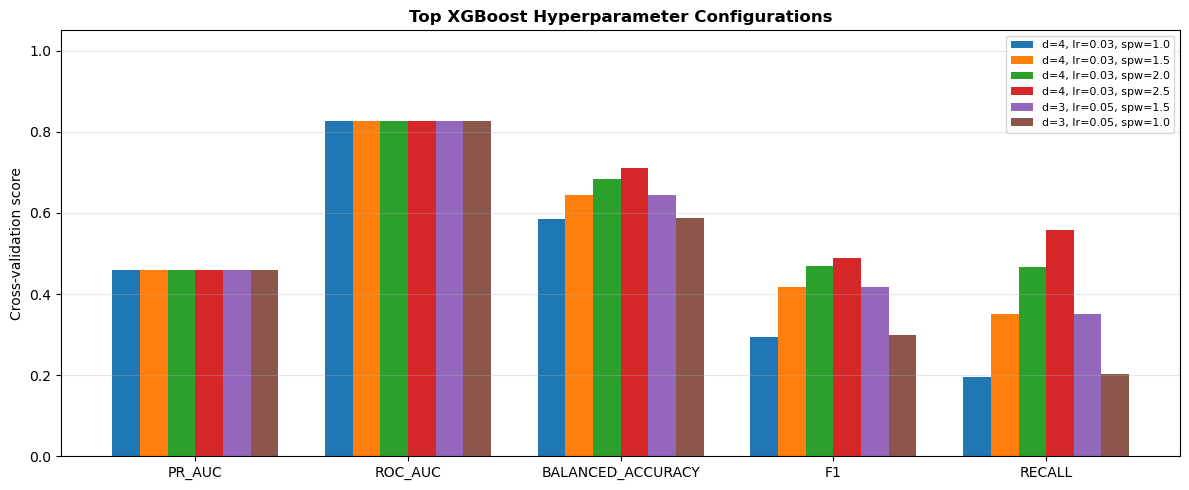

In [12]:
# Compare the top XGBoost hyperparameter configurations.
top_runs = eligible.head(6)

metric_cols = [
    "metrics.cv_pr_auc_mean",
    "metrics.cv_roc_auc_mean",
    "metrics.cv_balanced_accuracy_mean",
    "metrics.cv_f1_mean",
    "metrics.cv_recall_mean",
]
available_metrics = [c for c in metric_cols if c in top_runs.columns]

fig, ax = plt.subplots(figsize=(12, 5))

labels = [c.replace("metrics.cv_", "").replace("_mean", "").upper() for c in available_metrics]
x = np.arange(len(labels))
n_runs = max(len(top_runs), 1)
width = min(0.13, 0.78 / n_runs)

for idx, (_, row) in enumerate(top_runs.iterrows()):
    values = [row.get(metric, np.nan) for metric in available_metrics]
    run_label = (
        f"d={row.get('params.max_depth', '?')}, "
        f"lr={row.get('params.learning_rate', '?')}, "
        f"spw={row.get('params.scale_pos_weight', '?')}"
    )
    ax.bar(x + idx * width, values, width, label=run_label)

ax.set_xticks(x + width * (n_runs - 1) / 2)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cross-validation score")
ax.set_title("Top XGBoost Hyperparameter Configurations", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Cross-Validated Boosting-Round Refinement (`n_estimators`)

The earlier notebook used a **single internal 10% validation split** for early stopping. In the
executed run, this reduced the model to only 67 trees even though the structural configuration had
been selected using 5-fold CV. That single split could override a much more robust CV result.

This revision removes that instability.

The selected XGBoost structure is now tested with:

`n_estimators = [150, 250, 350, 450, 600]`

using the **same Stratified 5-Fold CV** and training data only.

Selection again uses a near-best PR-AUC band followed by F1, balanced accuracy and ROC-AUC.
The held-out test is still untouched.


In [13]:
from xgboost import XGBClassifier

N_ESTIMATOR_CANDIDATES = [150, 250, 350, 450, 600]
N_ESTIMATOR_NEAR_BEST_TOLERANCE = 0.0015
round_records = []

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_xgb_n_estimators_refinement") as refinement_run:
    mlflow.set_tags({**COMMON_TAGS, "run_type": "n_estimators_refinement", "model_family": MODEL_FAMILY,
                     "selection_eligible": "false", "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID})
    mlflow.log_params({**SELECTED_STRUCTURE_PARAMS, "n_estimator_candidates": str(N_ESTIMATOR_CANDIDATES),
                       "cv_folds": CV_FOLDS, "primary_selection_metric": PRIMARY_SELECTION_METRIC,
                       "near_best_pr_auc_tolerance": N_ESTIMATOR_NEAR_BEST_TOLERANCE})

    for n_estimators in N_ESTIMATOR_CANDIDATES:
        params = {**FIXED_XGB_PARAMS, **SELECTED_STRUCTURE_PARAMS, "n_estimators": n_estimators}
        model = XGBClassifier(**params)
        metrics = cross_validate_model(model, X_train, y_train)
        round_records.append({"n_estimators": n_estimators, **metrics})
        print(f"n_estimators={n_estimators:>3} | CV PR-AUC={metrics['cv_pr_auc_mean']:.4f} | "
              f"CV F1={metrics['cv_f1_mean']:.4f} | CV ROC-AUC={metrics['cv_roc_auc_mean']:.4f}")

    round_results = pd.DataFrame(round_records)
    best_round_pr_auc = float(round_results["cv_pr_auc_mean"].max())
    round_cutoff = best_round_pr_auc - N_ESTIMATOR_NEAR_BEST_TOLERANCE
    near_best_rounds = round_results[round_results["cv_pr_auc_mean"] >= round_cutoff].copy()
    near_best_rounds = near_best_rounds.sort_values(
        by=["cv_f1_mean", "cv_balanced_accuracy_mean", "cv_roc_auc_mean", "cv_pr_auc_mean", "n_estimators"],
        ascending=[False, False, False, False, True],
    ).reset_index(drop=True)
    best_round = near_best_rounds.iloc[0]
    BEST_N_ESTIMATORS = int(best_round["n_estimators"])

    mlflow.log_metrics({"absolute_best_round_cv_pr_auc": round(best_round_pr_auc, 4),
                        "selected_n_estimators": BEST_N_ESTIMATORS,
                        "selected_round_cv_pr_auc": round(float(best_round["cv_pr_auc_mean"]), 4),
                        "selected_round_cv_f1": round(float(best_round["cv_f1_mean"]), 4),
                        "selected_round_cv_roc_auc": round(float(best_round["cv_roc_auc_mean"]), 4)})
    with tempfile.TemporaryDirectory() as tmp:
        rounds_csv = Path(tmp) / "n_estimators_cv_refinement.csv"
        round_results.to_csv(rounds_csv, index=False)
        mlflow.log_artifact(str(rounds_csv), artifact_path="n_estimators_refinement")
    N_ESTIMATORS_REFINEMENT_RUN_ID = refinement_run.info.run_id

print("\n" + "=" * 80)
print("BOOSTING-ROUND REFINEMENT COMPLETE")
print("=" * 80)
print(f"Absolute best round CV PR-AUC : {best_round_pr_auc:.4f}")
print(f"Near-best cutoff              : {round_cutoff:.4f}")
print(f"Selected n_estimators         : {BEST_N_ESTIMATORS}")
print(f"Selected round CV PR-AUC      : {float(best_round['cv_pr_auc_mean']):.4f}")
print(f"Selected round CV F1          : {float(best_round['cv_f1_mean']):.4f}")
print(f"Selected round CV ROC-AUC     : {float(best_round['cv_roc_auc_mean']):.4f}")
print("=" * 80)
print("Held-out test remains untouched.")


n_estimators=150 | CV PR-AUC=0.4552 | CV F1=0.4911 | CV ROC-AUC=0.8237
n_estimators=250 | CV PR-AUC=0.4583 | CV F1=0.4923 | CV ROC-AUC=0.8250
n_estimators=350 | CV PR-AUC=0.4595 | CV F1=0.4927 | CV ROC-AUC=0.8254
n_estimators=450 | CV PR-AUC=0.4603 | CV F1=0.4937 | CV ROC-AUC=0.8256
n_estimators=600 | CV PR-AUC=0.4606 | CV F1=0.4933 | CV ROC-AUC=0.8257
🏃 View run team02_s202_xgb_n_estimators_refinement at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e89987fd9aec4a11a1108c8afaf6561b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

BOOSTING-ROUND REFINEMENT COMPLETE
Absolute best round CV PR-AUC : 0.4606
Near-best cutoff              : 0.4591
Selected n_estimators         : 450
Selected round CV PR-AUC      : 0.4603
Selected round CV F1          : 0.4937
Selected round CV ROC-AUC     : 0.8256
Held-out test remains untouched.


## 9. Threshold Search and Optimization

The best XGBoost hyperparameters (`max_depth`, `learning_rate`, `scale_pos_weight`, `n_estimators`)
are now fixed. The next step optimizes the **classification threshold** used to convert predicted
probabilities into class `0` or class `1` — same protocol as the Logistic Regression notebook.

The standard `0.50` threshold is included as a reference, but the search evaluates thresholds from
`0.05` to `0.95` in `0.01` increments.

To prevent leakage, the search uses **out-of-fold probabilities from the training set only**. Each
training row is scored by a fold model that was not trained on that row. The default objective is
**F1 score**, with balanced accuracy and recall used as tie-breakers.

XGBOOST THRESHOLD TUNING — OOF TRAINING DATA
Selected max_depth         : 4
Selected learning_rate     : 0.03
Selected scale_pos_weight  : 3.0
Selected n_estimators      : 450
Search range               : 0.05 - 0.95
Search step                : 0.01
------------------------------------------------------------------------
DEFAULT THRESHOLD
Threshold                  : 0.50
OOF F1                     : 0.4937
OOF balanced accuracy      : 0.7278
OOF precision              : 0.4076
OOF recall                 : 0.6258
OOF specificity            : 0.8299
OOF FPR                    : 0.1701
OOF FNR                    : 0.3742
------------------------------------------------------------------------
OPTIMIZED THRESHOLD
Threshold                  : 0.50
OOF F1                     : 0.4937
OOF balanced accuracy      : 0.7278
OOF precision              : 0.4076
OOF recall                 : 0.6258
OOF specificity            : 0.8299
OOF FPR                    : 0.1701
OOF FNR                    : 

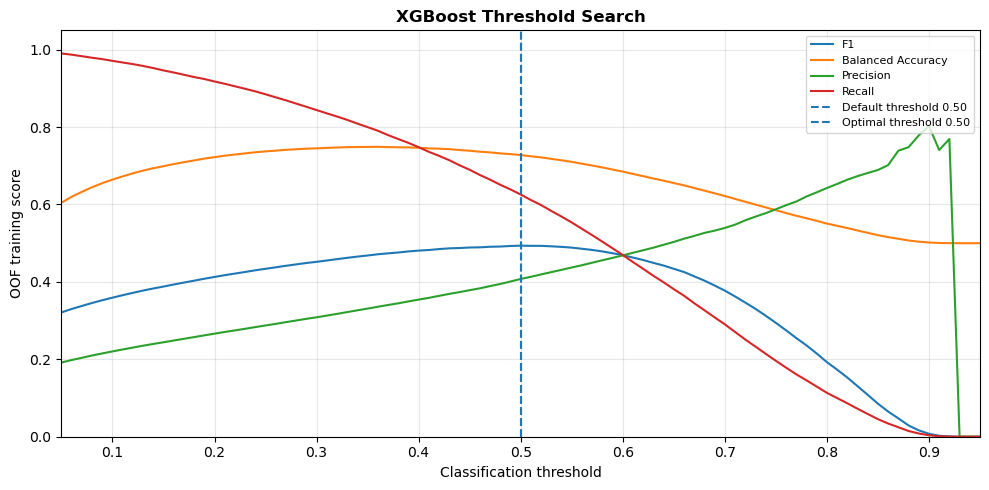

🏃 View run team02_s202_xgb_threshold_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/a1a47bcc23d844539d92f3a3ed8fec1e
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Threshold tuning run ID: a1a47bcc23d844539d92f3a3ed8fec1e

Held-out test is still untouched. The optimized threshold will be applied only in the final evaluation.


In [14]:
from sklearn.model_selection import cross_val_predict

# ============================================================
# Threshold-search settings
# ============================================================
THRESHOLD_OBJECTIVE = "f1"
THRESHOLD_MIN = 0.05
THRESHOLD_MAX = 0.95
THRESHOLD_STEP = 0.01

thresholds = np.round(
    np.arange(THRESHOLD_MIN, THRESHOLD_MAX + THRESHOLD_STEP / 2, THRESHOLD_STEP), 2
)

# Recreate the CV-selected XGBoost structure and CV-refined boosting-round count.
threshold_model = XGBClassifier(
    **{
        **FIXED_XGB_PARAMS,
        **SELECTED_STRUCTURE_PARAMS,
        "n_estimators": BEST_N_ESTIMATORS,
    }
)

# ------------------------------------------------------------
# OUT-OF-FOLD probabilities from TRAINING DATA ONLY.
# ------------------------------------------------------------
oof_proba = cross_val_predict(
    threshold_model, X_train, y_train,
    cv=CV, method="predict_proba", n_jobs=-1,
)[:, 1]

threshold_rows = []
for threshold in thresholds:
    oof_pred = (oof_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, oof_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    threshold_rows.append({
        "threshold": float(threshold),
        "f1": float(f1_score(y_train, oof_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_train, oof_pred)),
        "precision": float(precision_score(y_train, oof_pred, zero_division=0)),
        "recall": float(recall_score(y_train, oof_pred, zero_division=0)),
        "specificity": float(specificity) if not np.isnan(specificity) else np.nan,
        "fpr": float(fpr) if not np.isnan(fpr) else np.nan,
        "fnr": float(fnr) if not np.isnan(fnr) else np.nan,
        "accuracy": float(accuracy_score(y_train, oof_pred)),
    })

threshold_results = pd.DataFrame(threshold_rows)

threshold_results = threshold_results.sort_values(
    by=["f1", "balanced_accuracy", "recall"],
    ascending=[False, False, False],
).reset_index(drop=True)

best_threshold_row = threshold_results.iloc[0]
OPTIMAL_THRESHOLD = float(best_threshold_row["threshold"])
OOF_THRESHOLD_F1 = float(best_threshold_row["f1"])
OOF_THRESHOLD_BALANCED_ACCURACY = float(best_threshold_row["balanced_accuracy"])
OOF_THRESHOLD_PRECISION = float(best_threshold_row["precision"])
OOF_THRESHOLD_RECALL = float(best_threshold_row["recall"])
OOF_THRESHOLD_SPECIFICITY = float(best_threshold_row["specificity"])
OOF_THRESHOLD_FPR = float(best_threshold_row["fpr"])
OOF_THRESHOLD_FNR = float(best_threshold_row["fnr"])

default_match = threshold_results[np.isclose(threshold_results["threshold"], 0.50)]
if default_match.empty:
    raise RuntimeError("Default threshold 0.50 is missing from the threshold search.")

default_threshold_row = default_match.iloc[0]
DEFAULT_THRESHOLD_F1 = float(default_threshold_row["f1"])
DEFAULT_THRESHOLD_BALANCED_ACCURACY = float(default_threshold_row["balanced_accuracy"])
DEFAULT_THRESHOLD_PRECISION = float(default_threshold_row["precision"])
DEFAULT_THRESHOLD_RECALL = float(default_threshold_row["recall"])
DEFAULT_THRESHOLD_SPECIFICITY = float(default_threshold_row["specificity"])
DEFAULT_THRESHOLD_FPR = float(default_threshold_row["fpr"])
DEFAULT_THRESHOLD_FNR = float(default_threshold_row["fnr"])

print("=" * 72)
print("XGBOOST THRESHOLD TUNING — OOF TRAINING DATA")
print("=" * 72)
print(f"Selected max_depth         : {SELECTED_MAX_DEPTH}")
print(f"Selected learning_rate     : {SELECTED_LEARNING_RATE}")
print(f"Selected scale_pos_weight  : {SELECTED_SCALE_POS_WEIGHT}")
print(f"Selected n_estimators      : {BEST_N_ESTIMATORS}")
print(f"Search range               : {THRESHOLD_MIN:.2f} - {THRESHOLD_MAX:.2f}")
print(f"Search step                : {THRESHOLD_STEP:.2f}")
print("-" * 72)
print("DEFAULT THRESHOLD")
print(f"Threshold                  : 0.50")
print(f"OOF F1                     : {DEFAULT_THRESHOLD_F1:.4f}")
print(f"OOF balanced accuracy      : {DEFAULT_THRESHOLD_BALANCED_ACCURACY:.4f}")
print(f"OOF precision              : {DEFAULT_THRESHOLD_PRECISION:.4f}")
print(f"OOF recall                 : {DEFAULT_THRESHOLD_RECALL:.4f}")
print(f"OOF specificity            : {DEFAULT_THRESHOLD_SPECIFICITY:.4f}")
print(f"OOF FPR                    : {DEFAULT_THRESHOLD_FPR:.4f}")
print(f"OOF FNR                    : {DEFAULT_THRESHOLD_FNR:.4f}")
print("-" * 72)
print("OPTIMIZED THRESHOLD")
print(f"Threshold                  : {OPTIMAL_THRESHOLD:.2f}")
print(f"OOF F1                     : {OOF_THRESHOLD_F1:.4f}")
print(f"OOF balanced accuracy      : {OOF_THRESHOLD_BALANCED_ACCURACY:.4f}")
print(f"OOF precision              : {OOF_THRESHOLD_PRECISION:.4f}")
print(f"OOF recall                 : {OOF_THRESHOLD_RECALL:.4f}")
print(f"OOF specificity            : {OOF_THRESHOLD_SPECIFICITY:.4f}")
print(f"OOF FPR                    : {OOF_THRESHOLD_FPR:.4f}")
print(f"OOF FNR                    : {OOF_THRESHOLD_FNR:.4f}")
print("=" * 72)

print("\nTop 10 threshold candidates:")
print(threshold_results.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# Log threshold search to MLflow.
# ------------------------------------------------------------
with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_xgb_threshold_tuning") as threshold_run:
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "threshold_tuning",
        "model_family": MODEL_FAMILY,
        "selection_eligible": "false",
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
    })

    mlflow.log_params({
        "selected_max_depth": SELECTED_MAX_DEPTH,
        "selected_learning_rate": SELECTED_LEARNING_RATE,
        "selected_scale_pos_weight": SELECTED_SCALE_POS_WEIGHT,
        "selected_n_estimators": BEST_N_ESTIMATORS,
        "threshold_objective": THRESHOLD_OBJECTIVE,
        "threshold_min": THRESHOLD_MIN,
        "threshold_max": THRESHOLD_MAX,
        "threshold_step": THRESHOLD_STEP,
        "n_thresholds": len(thresholds),
        "cv_folds": CV_FOLDS,
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
    })

    mlflow.log_metrics({
        "default_threshold": 0.50,
        "default_oof_f1": round(DEFAULT_THRESHOLD_F1, 4),
        "default_oof_balanced_accuracy": round(DEFAULT_THRESHOLD_BALANCED_ACCURACY, 4),
        "default_oof_precision": round(DEFAULT_THRESHOLD_PRECISION, 4),
        "default_oof_recall": float(DEFAULT_THRESHOLD_RECALL),
        "default_oof_specificity": float(DEFAULT_THRESHOLD_SPECIFICITY),
        "default_oof_fpr": float(DEFAULT_THRESHOLD_FPR),
        "default_oof_fnr": float(DEFAULT_THRESHOLD_FNR),
        "optimal_threshold": float(OPTIMAL_THRESHOLD),
        "optimal_oof_f1": float(OOF_THRESHOLD_F1),
        "optimal_oof_balanced_accuracy": float(OOF_THRESHOLD_BALANCED_ACCURACY),
        "optimal_oof_precision": float(OOF_THRESHOLD_PRECISION),
        "optimal_oof_recall": float(OOF_THRESHOLD_RECALL),
        "optimal_oof_specificity": float(OOF_THRESHOLD_SPECIFICITY),
        "optimal_oof_fpr": float(OOF_THRESHOLD_FPR),
        "optimal_oof_fnr": float(OOF_THRESHOLD_FNR),
    })

    with tempfile.TemporaryDirectory() as tmp:
        tmp_path = Path(tmp)
        csv_path = tmp_path / "threshold_search.csv"
        threshold_results.sort_values("threshold").to_csv(csv_path, index=False)
        mlflow.log_artifact(str(csv_path), artifact_path="threshold_tuning")

        threshold_plot = threshold_results.sort_values("threshold")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(threshold_plot["threshold"], threshold_plot["f1"], label="F1")
        ax.plot(threshold_plot["threshold"], threshold_plot["balanced_accuracy"], label="Balanced Accuracy")
        ax.plot(threshold_plot["threshold"], threshold_plot["precision"], label="Precision")
        ax.plot(threshold_plot["threshold"], threshold_plot["recall"], label="Recall")
        ax.axvline(0.50, linestyle="--", label="Default threshold 0.50")
        ax.axvline(OPTIMAL_THRESHOLD, linestyle="--", label=f"Optimal threshold {OPTIMAL_THRESHOLD:.2f}")
        ax.set_xlabel("Classification threshold")
        ax.set_ylabel("OOF training score")
        ax.set_title("XGBoost Threshold Search", fontweight="bold")
        ax.set_xlim(THRESHOLD_MIN, THRESHOLD_MAX)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()

        plot_path = tmp_path / "threshold_search.png"
        fig.savefig(plot_path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(str(plot_path), artifact_path="threshold_tuning")
        plt.show()
        plt.close()

    THRESHOLD_TUNING_RUN_ID = threshold_run.info.run_id

print(f"\nThreshold tuning run ID: {THRESHOLD_TUNING_RUN_ID}")
print("\nHeld-out test is still untouched. The optimized threshold will be applied "
      "only in the final evaluation.")

## 10. Final Held-Out Evaluation + Quality Gate

This is the **first point in the notebook where `X_test` / `y_test` are used for model evaluation**
— identical discipline to the Logistic Regression notebook. The CV-selected, early-stopping-refined
configuration is refit on all training data and evaluated on the held-out test set **once**.

The quality gate (`Test ROC-AUC >= 0.75`) matches the threshold used for Logistic Regression and the
original team-tag-check template, so both models are held to the same bar before either can be
promoted.

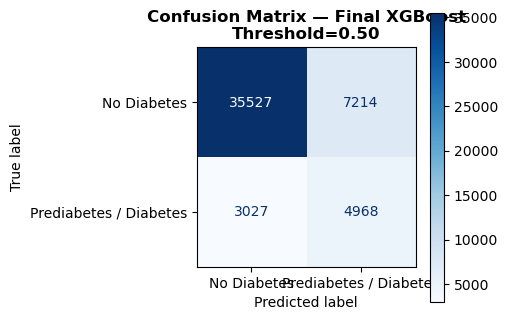

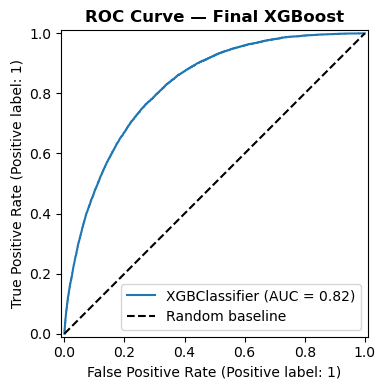

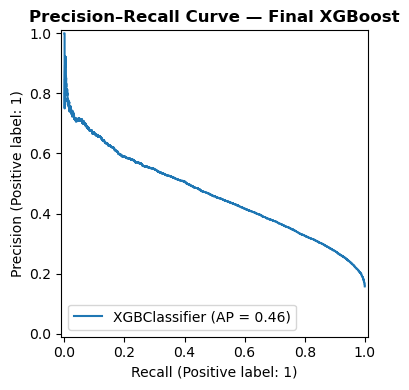

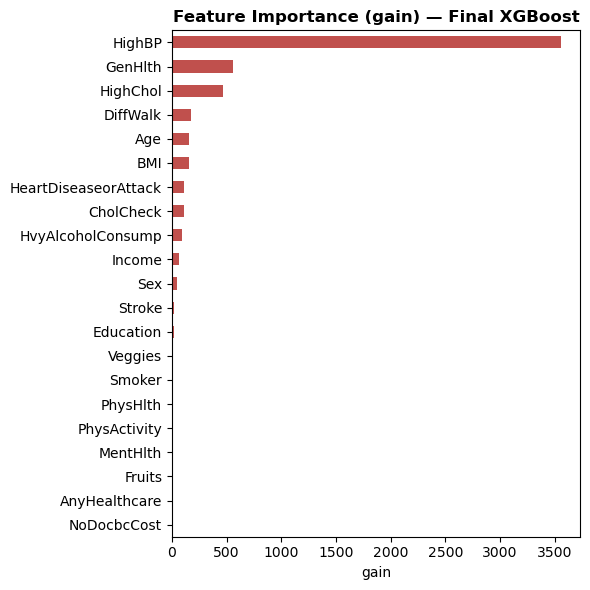

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
FINAL HELD-OUT TEST RESULTS — XGBOOST
Selected candidate : xgb_candidate_29
Model family       : XGBoost
Selection CV PR-AUC: 0.4595
Selection CV ROC   : 0.8254
n_estimators       : 450
Decision threshold : 0.50
Threshold OOF F1   : 0.4937
------------------------------------------------------------------------
test_accuracy               : 0.7981512141280354
test_auc_roc                : 0.8248201732385823
test_balanced_accuracy      : 0.7263021481146992
test_brier                  : 0.13392609827383717
test_f1                     : 0.49244188927987315
test_f2                     : 0.5624745256102531
test_fn                     : 3027
test_fnr                    : 0.37861163227016886
test_fp                     : 7214
test_fpr                    : 0.1687840715

In [15]:
# ==========================================================
# Final Held-Out Evaluation + Quality Gate
# ==========================================================
QUALITY_GATE = 0.75  # Preserve the same ROC-AUC gate used for Logistic Regression.

selected_final_params = {
    **FIXED_XGB_PARAMS,
    "max_depth": SELECTED_MAX_DEPTH,
    "learning_rate": SELECTED_LEARNING_RATE,
    "scale_pos_weight": SELECTED_SCALE_POS_WEIGHT,
    "n_estimators": BEST_N_ESTIMATORS,
}

selected_model = XGBClassifier(**selected_final_params)
selected_model.fit(X_train, y_train)

# Evaluate the held-out test ONCE after selection.
final_metrics = evaluate_final_model(
    selected_model, X_train, y_train, X_test, y_test, threshold=OPTIMAL_THRESHOLD,
)

final_run_name = f"{TEAM_ID}_{STUDENT_ID}_final_xgboost"

with mlflow.start_run(run_name=final_run_name) as final_run:
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "final_holdout_evaluation",
        "model_family": SELECTED_MODEL_FAMILY,
        "selection_eligible": "false",
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
        "selected_candidate_name": SELECTED_CANDIDATE_NAME,
    })

    mlflow.log_params({
        **selected_final_params,
        "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
        "selected_candidate_name": SELECTED_CANDIDATE_NAME,
        "selected_model_family": SELECTED_MODEL_FAMILY,
        "primary_selection_metric": PRIMARY_SELECTION_METRIC,
        "cv_folds": CV_FOLDS,
        "quality_gate_metric": "test_auc_roc",
        "quality_gate_threshold": QUALITY_GATE,
        "classification_threshold": OPTIMAL_THRESHOLD,
        "threshold_objective": THRESHOLD_OBJECTIVE,
        "threshold_tuning_run_id": THRESHOLD_TUNING_RUN_ID,
        "n_estimators_refinement_run_id": N_ESTIMATORS_REFINEMENT_RUN_ID,
        "data_profile": DATA_PROFILE,
        "profile_fraction": PROFILE_FRACTION,
        "profile_rows": PROFILE_ROWS,
        "full_dataset_rows": FULL_DATASET_ROWS,
        "profile_sha256": PROFILE_SHA256,
        "train_split_sha256": TRAIN_SPLIT_SHA256,
        "test_split_sha256": TEST_SPLIT_SHA256,
    })

    mlflow.log_metrics({
        "selection_cv_pr_auc": round(BEST_CV_PR_AUC, 4),
        "selection_cv_roc_auc": round(BEST_CV_ROC_AUC, 4),
        "selected_threshold": round(OPTIMAL_THRESHOLD, 4),
        "threshold_oof_f1": round(OOF_THRESHOLD_F1, 4),
        "default_threshold_oof_f1": round(DEFAULT_THRESHOLD_F1, 4),
        **final_metrics,
    })

    log_confusion_matrix(selected_model, X_test, y_test, "Final XGBoost", threshold=OPTIMAL_THRESHOLD)
    log_roc_curve(selected_model, X_test, y_test, "Final XGBoost")
    log_pr_curve(selected_model, X_test, y_test, "Final XGBoost")
    log_feature_importance(selected_model, X_train.columns.tolist(), "Final XGBoost")

    mlflow_call_with_retry(mlflow.xgboost.log_model, selected_model, name="model")

    FINAL_RUN_ID = final_run.info.run_id

FINAL_TEST_AUC_ROC = final_metrics["test_auc_roc"]
FINAL_TEST_PR_AUC = final_metrics["test_pr_auc"]

QUALITY_GATE_PASSED = FINAL_TEST_AUC_ROC >= QUALITY_GATE

# Downstream compatibility (matches the naming convention used by Notebook 03):
BEST_RUN_ID = FINAL_RUN_ID
BEST_RUN_NAME = final_run_name
BEST_AUC = FINAL_TEST_AUC_ROC
BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model" if QUALITY_GATE_PASSED else None

client.set_tag(FINAL_RUN_ID, "quality_gate_passed", str(QUALITY_GATE_PASSED).lower())

print("=" * 72)
print("FINAL HELD-OUT TEST RESULTS — XGBOOST")
print("=" * 72)
print(f"Selected candidate : {SELECTED_CANDIDATE_NAME}")
print(f"Model family       : {SELECTED_MODEL_FAMILY}")
print(f"Selection CV PR-AUC: {BEST_CV_PR_AUC:.4f}")
print(f"Selection CV ROC   : {BEST_CV_ROC_AUC:.4f}")
print(f"n_estimators       : {BEST_N_ESTIMATORS}")
print(f"Decision threshold : {OPTIMAL_THRESHOLD:.2f}")
print(f"Threshold OOF F1   : {OOF_THRESHOLD_F1:.4f}")
print("-" * 72)
for key, value in sorted(final_metrics.items()):
    print(f"{key:<28}: {value}")
print("-" * 72)

if QUALITY_GATE_PASSED:
    print("QUALITY GATE: PASSED")
    print(f"Final Test ROC-AUC {FINAL_TEST_AUC_ROC:.4f} >= {QUALITY_GATE:.2f}")
    print(f"Final model URI: {BEST_MODEL_URI}")
else:
    print("QUALITY GATE: FAILED")
    print(f"Final Test ROC-AUC {FINAL_TEST_AUC_ROC:.4f} < {QUALITY_GATE:.2f}")
    print("Do not promote this model to the next stage.")
print("=" * 72)

## 11. Error Analysis — Confusion Matrix Breakdown, Representative Errors, Borderline Cases & Subgroup Error Concentration

Per the ITI113 Progress Check briefing (*"Perform error analysis, not just metric reporting ... Examine
representative false positives, false negatives, difficult/borderline cases, and important subgroups.
Explain why errors matter for the actual application."*), this section goes beyond the single-number
metrics reported in Section 10.

For an **imbalanced diabetes/prediabetes screening problem**, accuracy alone is misleading — a model
that always predicts "No Diabetes" would still score highly on accuracy while catching zero at-risk
people. This section therefore reports the **full confusion-matrix-derived metric set**
(recall/sensitivity, precision, F1, F2, **specificity**, **false-positive rate**), and then examines:

1. **Confusion matrix breakdown** (11.1) — the raw TN/FP/FN/TP counts behind the headline metrics.
2. **Representative false positives and false negatives** (11.2) — the cases the model got most
   confidently wrong, with their clinical feature profile.
3. **Borderline / difficult cases** (11.3) — held-out rows whose predicted probability sits close to
   the decision threshold, where the model is genuinely uncertain rather than confidently right or
   wrong.
4. **Subgroup error concentration** (11.4) — which `Sex` / `Age` / `Education` / `Income` groups the
   false negatives and false positives are concentrated in, in **raw counts and share of all errors**
   — a complement to the rate-based gaps reported later in Section 13 (Subgroup Fairness).
5. **Why these errors matter** (11.5) for a diabetes risk *screening* tool, and what that implies for
   threshold choice, human-in-the-loop review, and equity follow-up.

All artifacts below are logged to the same `FINAL_RUN_ID` MLflow run as Section 10, so they stay
reproducible and versioned alongside the model that produced them.


CONFUSION MATRIX — FINAL XGBOOST, HELD-OUT TEST SET (threshold=0.50)
                                  Predicted: No Diabetes (0)  Predicted: Prediabetes/Diabetes (1)
Actual: No Diabetes (0)                                35527                                 7214
Actual: Prediabetes/Diabetes (1)                        3027                                 4968
------------------------------------------------------------------------------------
True Negatives  (TN) : 35,527  — correctly cleared
False Positives (FP) :  7,214  — unnecessarily flagged (unwarranted follow-up)
False Negatives (FN) :  3,027  — MISSED at-risk person (main screening harm)
True Positives  (TP) :  4,968  — correctly flagged for follow-up
------------------------------------------------------------------------------------
FULL METRIC REPORT (held-out test set)
PR-AUC                       0.4644
ROC-AUC                      0.8248
Recall (Sensitivity)         0.6214
Precision                    0.4078
F1          

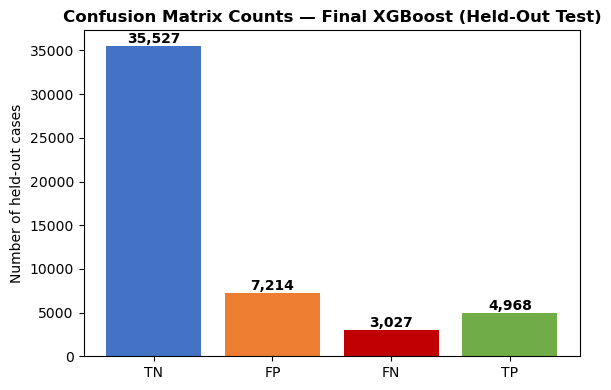

In [16]:
# ==========================================================
# 11.1 Confusion Matrix Breakdown & Full Metric Report (Held-Out Test Set)
# ==========================================================
TEST_TN = final_metrics["test_tn"]
TEST_FP = final_metrics["test_fp"]
TEST_FN = final_metrics["test_fn"]
TEST_TP = final_metrics["test_tp"]
TEST_SPECIFICITY = final_metrics["test_specificity"]
TEST_FPR = final_metrics["test_fpr"]

confusion_summary = pd.DataFrame(
    [[TEST_TN, TEST_FP], [TEST_FN, TEST_TP]],
    index=["Actual: No Diabetes (0)", "Actual: Prediabetes/Diabetes (1)"],
    columns=["Predicted: No Diabetes (0)", "Predicted: Prediabetes/Diabetes (1)"],
)

print("=" * 84)
print(f"CONFUSION MATRIX \u2014 FINAL XGBOOST, HELD-OUT TEST SET (threshold={OPTIMAL_THRESHOLD:.2f})")
print("=" * 84)
print(confusion_summary.to_string())
print("-" * 84)
print(f"True Negatives  (TN) : {TEST_TN:>6,}  \u2014 correctly cleared")
print(f"False Positives (FP) : {TEST_FP:>6,}  \u2014 unnecessarily flagged (unwarranted follow-up)")
print(f"False Negatives (FN) : {TEST_FN:>6,}  \u2014 MISSED at-risk person (main screening harm)")
print(f"True Positives  (TP) : {TEST_TP:>6,}  \u2014 correctly flagged for follow-up")
print("-" * 84)

full_metric_report = pd.Series({
    "PR-AUC": final_metrics["test_pr_auc"],
    "ROC-AUC": final_metrics["test_auc_roc"],
    "Recall (Sensitivity)": final_metrics["test_recall"],
    "Precision": final_metrics["test_precision"],
    "F1": final_metrics["test_f1"],
    "F2 (recall-weighted)": final_metrics["test_f2"],
    "Specificity": TEST_SPECIFICITY,
    "False Positive Rate (FPR)": TEST_FPR,
    "Balanced Accuracy": final_metrics["test_balanced_accuracy"],
    "Accuracy": final_metrics["test_accuracy"],
    "Brier Score": final_metrics["test_brier"],
})
print("FULL METRIC REPORT (held-out test set)")
print(full_metric_report.round(4).to_string())
print("=" * 84)
print(
    "Note: Recall and Specificity are complementary \u2014 Recall measures how many actual at-risk "
    "people were caught; Specificity measures how many actual healthy people were correctly cleared. "
    "FPR = 1 - Specificity."
)

# ------------------------------------------------------------
# Confusion matrix count bar chart (paired with the sklearn heat-map
# already logged in Section 10)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
cm_labels = ["TN", "FP", "FN", "TP"]
cm_values = [TEST_TN, TEST_FP, TEST_FN, TEST_TP]
cm_colors = ["#4472C4", "#ED7D31", "#C00000", "#70AD47"]
ax.bar(cm_labels, cm_values, color=cm_colors)
for i, v in enumerate(cm_values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Confusion Matrix Counts \u2014 Final XGBoost (Held-Out Test)", fontweight="bold")
ax.set_ylabel("Number of held-out cases")
plt.tight_layout()

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/confusion_matrix_counts_bar.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="error_analysis")

        csv_path = f"{tmp}/confusion_matrix_breakdown.csv"
        confusion_summary.to_csv(csv_path)
        mlflow.log_artifact(csv_path, artifact_path="error_analysis")

        report_path = f"{tmp}/full_metric_report.csv"
        full_metric_report.round(4).to_csv(report_path, header=["value"])
        mlflow.log_artifact(report_path, artifact_path="error_analysis")

plt.show()
plt.close()


In [17]:
# ==========================================================
# 11.2 Representative False Positives & False Negatives
# ==========================================================
KEY_CLINICAL_FEATURES = [c for c in [
    "HighBP", "HighChol", "BMI", "GenHlth", "PhysHlth", "MentHlth",
    "DiffWalk", "HeartDiseaseorAttack", "Age", "Sex", "Income", "Education",
] if c in X_test.columns]

test_pred, test_proba = predict_with_threshold(selected_model, X_test, threshold=OPTIMAL_THRESHOLD)

error_results = X_test.copy()
error_results["actual"] = y_test.to_numpy()
error_results["predicted"] = test_pred
error_results["predicted_proba"] = test_proba.round(4)
error_results["distance_from_threshold"] = (
    (error_results["predicted_proba"] - OPTIMAL_THRESHOLD).abs().round(4)
)


def _classify_error(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "TP"
    if row["actual"] == 0 and row["predicted"] == 0:
        return "TN"
    if row["actual"] == 0 and row["predicted"] == 1:
        return "FP"
    return "FN"


error_results["error_type"] = error_results.apply(_classify_error, axis=1)

# Sanity check: these must reconcile exactly with the confusion matrix in 11.1.
assert int((error_results["error_type"] == "FP").sum()) == TEST_FP
assert int((error_results["error_type"] == "FN").sum()) == TEST_FN

N_ERROR_EXAMPLES = 8
display_cols = KEY_CLINICAL_FEATURES + ["actual", "predicted", "predicted_proba"]

most_confident_false_positives = (
    error_results[error_results["error_type"] == "FP"]
    .sort_values("predicted_proba", ascending=False)
    .head(N_ERROR_EXAMPLES)
)
most_confident_false_negatives = (
    error_results[error_results["error_type"] == "FN"]
    .sort_values("predicted_proba", ascending=True)
    .head(N_ERROR_EXAMPLES)
)

print("=" * 104)
print(f"MOST CONFIDENT FALSE POSITIVES (flagged high-risk, actually no diabetes) \u2014 top {N_ERROR_EXAMPLES}")
print("=" * 104)
print(most_confident_false_positives[display_cols].to_string(index=False))

print("\n" + "=" * 104)
print(f"MOST CONFIDENT FALSE NEGATIVES (missed at-risk person) \u2014 top {N_ERROR_EXAMPLES}")
print("=" * 104)
print(most_confident_false_negatives[display_cols].to_string(index=False))

# ------------------------------------------------------------
# Feature-profile comparison across error types \u2014 what distinguishes
# false negatives from true positives, and false positives from true negatives?
# ------------------------------------------------------------
error_feature_profile = (
    error_results.groupby("error_type")[KEY_CLINICAL_FEATURES]
    .mean()
    .round(2)
    .reindex(["TN", "FP", "FN", "TP"])
)
print("\n" + "=" * 104)
print("MEAN CLINICAL FEATURE VALUES BY ERROR TYPE (held-out test set)")
print("=" * 104)
print(error_feature_profile.to_string())
print(
    "\nReading guide: compare FN (missed at-risk) against TP (correctly flagged) to see which "
    "features look 'healthier' despite the person actually having diabetes/prediabetes \u2014 these "
    "are the atypical presentations the model currently under-weights. Compare FP against TN the "
    "same way to see which features push the model to over-flag healthy people."
)

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        fp_path = f"{tmp}/representative_false_positives.csv"
        most_confident_false_positives[display_cols].to_csv(fp_path, index=False)
        mlflow.log_artifact(fp_path, artifact_path="error_analysis")

        fn_path = f"{tmp}/representative_false_negatives.csv"
        most_confident_false_negatives[display_cols].to_csv(fn_path, index=False)
        mlflow.log_artifact(fn_path, artifact_path="error_analysis")

        profile_path = f"{tmp}/error_type_feature_profile.csv"
        error_feature_profile.to_csv(profile_path)
        mlflow.log_artifact(profile_path, artifact_path="error_analysis")


MOST CONFIDENT FALSE POSITIVES (flagged high-risk, actually no diabetes) — top 8
 HighBP  HighChol  BMI  GenHlth  PhysHlth  MentHlth  DiffWalk  HeartDiseaseorAttack  Age  Sex  Income  Education  actual  predicted  predicted_proba
    1.0       1.0 44.0      5.0      30.0       0.0       1.0                   1.0  9.0  1.0     4.0        6.0       0          1           0.9232
    1.0       1.0 37.0      5.0       6.0       2.0       1.0                   1.0  9.0  0.0     2.0        2.0       0          1           0.9226
    1.0       1.0 58.0      5.0      20.0       0.0       1.0                   1.0 10.0  0.0     2.0        5.0       0          1           0.9120
    1.0       1.0 38.0      5.0      30.0      30.0       1.0                   1.0  8.0  1.0     7.0        6.0       0          1           0.9064
    1.0       1.0 35.0      5.0       0.0      30.0       1.0                   0.0 11.0  0.0     2.0        2.0       0          1           0.9035
    1.0       1.0 50.0   

BORDERLINE CASES — within +/-0.05 of the decision threshold (0.50)
4,375 of 50,736 held-out cases (8.6%) fall in this band — these are cases where the model is genuinely uncertain, not confidently right or wrong.

Outcome mix within the borderline band:
error_type
TN    1724
FP    1566
FN     513
TP     572

Sample of 10 borderline cases closest to the threshold:
 HighBP  HighChol  BMI  GenHlth  PhysHlth  MentHlth  DiffWalk  HeartDiseaseorAttack  Age  Sex  Income  Education  actual  predicted  predicted_proba error_type  distance_from_threshold
    1.0       1.0 27.0      2.0       0.0       0.0       0.0                   0.0 11.0  1.0     4.0        5.0       0          0           0.5000         TN                   0.0000
    0.0       1.0 28.0      5.0      30.0      15.0       0.0                   0.0  7.0  0.0     8.0        6.0       0          0           0.5000         TN                   0.0000
    1.0       0.0 29.0      3.0       0.0       7.0       0.0                  

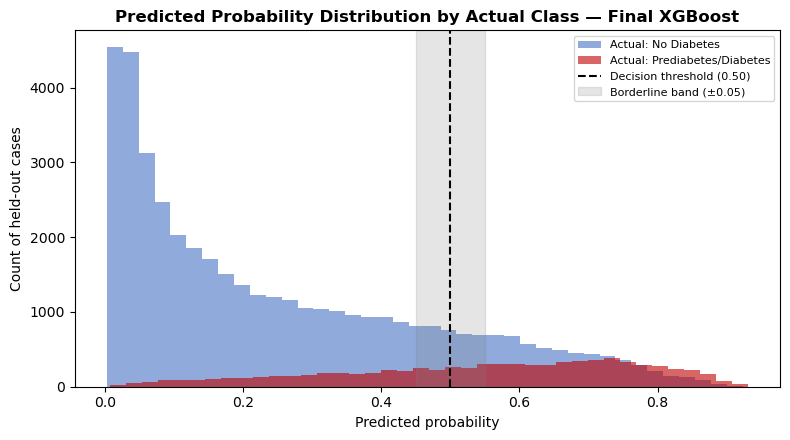

In [18]:
# ==========================================================
# 11.3 Borderline / Difficult Cases
# ==========================================================
BORDERLINE_BAND = 0.05  # +/- around the decision threshold

borderline_cases = (
    error_results[error_results["distance_from_threshold"] <= BORDERLINE_BAND]
    .sort_values("distance_from_threshold")
    .copy()
)

borderline_share = len(borderline_cases) / len(error_results)
print("=" * 104)
print(
    f"BORDERLINE CASES \u2014 within +/-{BORDERLINE_BAND:.2f} of the decision threshold "
    f"({OPTIMAL_THRESHOLD:.2f})"
)
print("=" * 104)
print(
    f"{len(borderline_cases):,} of {len(error_results):,} held-out cases "
    f"({borderline_share:.1%}) fall in this band \u2014 these are cases where the model is "
    f"genuinely uncertain, not confidently right or wrong."
)
print("\nOutcome mix within the borderline band:")
print(
    borderline_cases["error_type"]
    .value_counts()
    .reindex(["TN", "FP", "FN", "TP"])
    .fillna(0)
    .astype(int)
    .to_string()
)

print(f"\nSample of {min(10, len(borderline_cases))} borderline cases closest to the threshold:")
print(
    borderline_cases[display_cols + ["error_type", "distance_from_threshold"]]
    .head(10)
    .to_string(index=False)
)

# Visualise where the probability distribution sits relative to the threshold,
# split by actual class \u2014 the overlap zone IS the borderline band.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(
    error_results.loc[error_results["actual"] == 0, "predicted_proba"],
    bins=40, alpha=0.6, label="Actual: No Diabetes", color="#4472C4",
)
ax.hist(
    error_results.loc[error_results["actual"] == 1, "predicted_proba"],
    bins=40, alpha=0.6, label="Actual: Prediabetes/Diabetes", color="#C00000",
)
ax.axvline(
    OPTIMAL_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
    label=f"Decision threshold ({OPTIMAL_THRESHOLD:.2f})",
)
ax.axvspan(
    OPTIMAL_THRESHOLD - BORDERLINE_BAND, OPTIMAL_THRESHOLD + BORDERLINE_BAND,
    color="gray", alpha=0.2, label=f"Borderline band (\u00b1{BORDERLINE_BAND:.2f})",
)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Count of held-out cases")
ax.set_title("Predicted Probability Distribution by Actual Class \u2014 Final XGBoost", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/probability_distribution_borderline.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="error_analysis")

        csv_path = f"{tmp}/borderline_cases.csv"
        borderline_cases[display_cols + ["error_type", "distance_from_threshold"]].to_csv(
            csv_path, index=False
        )
        mlflow.log_artifact(csv_path, artifact_path="error_analysis")

    mlflow.log_metric("borderline_case_share", round(borderline_share, 4))
    mlflow.log_metric("borderline_case_count", int(len(borderline_cases)))

plt.show()
plt.close()


In [19]:
# ==========================================================
# 11.4 Subgroup Error Concentration (raw counts, not just rates)
# ==========================================================
# Section 13 (Subgroup Fairness) reports RATE-based gaps (recall, FPR) per subgroup.
# This complements that view with RAW error counts and each subgroup's SHARE of all
# false negatives / false positives \u2014 i.e. where the harm is concentrated in absolute
# terms, which matters for prioritising review even when a subgroup's rate looks fine
# but its small size gives a rate-based gap check low statistical power.

def subgroup_error_counts(results_df, subgroup_columns=SUBGROUP_COLUMNS):
    total_fn = int((results_df["error_type"] == "FN").sum())
    total_fp = int((results_df["error_type"] == "FP").sum())

    rows = []
    for column, label_map in subgroup_columns.items():
        if column not in results_df.columns:
            continue
        for raw_value, group_label in label_map.items():
            sub = results_df[results_df[column] == raw_value]
            n = len(sub)
            if n == 0:
                continue
            actual_positive_n = int((sub["actual"] == 1).sum())
            fn = int((sub["error_type"] == "FN").sum())
            fp = int((sub["error_type"] == "FP").sum())
            rows.append({
                "attribute": column,
                "group": group_label,
                "n": n,
                "actual_positive_n": actual_positive_n,
                "false_negative_count": fn,
                "false_negative_rate_of_actual_positive": (
                    round(fn / actual_positive_n, 4) if actual_positive_n > 0 else np.nan
                ),
                "share_of_all_false_negatives": (
                    round(fn / total_fn, 4) if total_fn > 0 else np.nan
                ),
                "false_positive_count": fp,
                "share_of_all_false_positives": (
                    round(fp / total_fp, 4) if total_fp > 0 else np.nan
                ),
                "sufficient_sample": n >= FAIRNESS_MIN_SUBGROUP_N,
            })
    return pd.DataFrame(rows)


subgroup_error_df = subgroup_error_counts(error_results)

print("=" * 104)
print("SUBGROUP ERROR CONCENTRATION \u2014 HELD-OUT TEST SET")
print("=" * 104)
print("Subgroups ranked by SHARE of all false negatives (missed at-risk people):")
print(
    subgroup_error_df.sort_values("share_of_all_false_negatives", ascending=False)
    .head(10)
    .to_string(index=False)
)

print("\nSubgroups ranked by SHARE of all false positives (unnecessary flags):")
print(
    subgroup_error_df.sort_values("share_of_all_false_positives", ascending=False)
    .head(10)
    .to_string(index=False)
)

# Flag subgroups (with sufficient sample) whose share of false negatives is
# disproportionate to their share of the actual-positive population \u2014 i.e. this
# subgroup contributes more missed cases than its prevalence alone would predict.
total_actual_positive = int((error_results["actual"] == 1).sum())
subgroup_error_df["share_of_actual_positive_population"] = (
    subgroup_error_df["actual_positive_n"] / total_actual_positive
).round(4)
subgroup_error_df["fn_concentration_ratio"] = (
    subgroup_error_df["share_of_all_false_negatives"]
    / subgroup_error_df["share_of_actual_positive_population"]
).round(2)

concentration_flags = subgroup_error_df[
    subgroup_error_df["sufficient_sample"]
    & (subgroup_error_df["fn_concentration_ratio"] >= 1.3)
    & (subgroup_error_df["false_negative_count"] >= 5)
].sort_values("fn_concentration_ratio", ascending=False)

print(
    "\nSubgroups where false negatives are disproportionately concentrated "
    "(fn_concentration_ratio >= 1.3, i.e. this group's share of missed cases is "
    ">=30% higher than its share of the actual at-risk population):"
)
if concentration_flags.empty:
    print(
        "  None \u2014 false negatives are roughly proportionate to subgroup prevalence "
        "across all reliable subgroups."
    )
else:
    print(concentration_flags[[
        "attribute", "group", "n", "actual_positive_n", "false_negative_count",
        "share_of_all_false_negatives", "share_of_actual_positive_population",
        "fn_concentration_ratio",
    ]].to_string(index=False))

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        csv_path = f"{tmp}/subgroup_error_concentration.csv"
        subgroup_error_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path, artifact_path="error_analysis")

    mlflow.log_metric("subgroup_fn_concentration_flag_count", int(len(concentration_flags)))

ERROR_ANALYSIS_SUBGROUP_FLAGS = int(len(concentration_flags))


SUBGROUP ERROR CONCENTRATION — HELD-OUT TEST SET
Subgroups ranked by SHARE of all false negatives (missed at-risk people):
attribute                  group     n  actual_positive_n  false_negative_count  false_negative_rate_of_actual_positive  share_of_all_false_negatives  false_positive_count  share_of_all_false_positives  sufficient_sample
      Sex                 Female 28192               4172                  1560                                  0.3739                        0.5154                  3623                        0.5022               True
      Sex                   Male 22544               3823                  1467                                  0.3837                        0.4846                  3591                        0.4978               True
Education       College graduate 21445               2291                  1183                                  0.5164                        0.3908                  1866                        0.2587             

### 11.5 Why these errors matter for a diabetes risk *screening* tool

**False negatives are the primary harm.** This project's stated fairness objective (Section 13,
citing the AI Risk and Impact Assessment) is *equal opportunity*: a missed at-risk person is the most
significant screening harm, because it delays the follow-up test, lifestyle counselling, or clinical
referral that an earlier flag would have triggered. The out-of-fold threshold selection rule
(Section 9) already prioritises F1 — which weights recall equally with precision — rather than
accuracy, precisely to avoid a model that minimises false negatives by refusing to flag anyone. The
representative false negatives above (11.2) show the specific clinical profiles the model currently
under-weights; these are candidates for future feature engineering or a lower decision threshold,
traded off against the resulting increase in false positives.

**False positives are a real but lower-severity cost.** An unnecessarily flagged person faces
follow-up testing (e.g. an HbA1c confirmation), possible anxiety, and marginal healthcare system cost
— but not a missed diagnosis. This is consistent with the proposal's framing of the model as a
**screening aid, not a diagnostic tool** (Proposal §6.3): a false positive is corrected at the next
clinical step, whereas a false negative may not be caught until symptoms appear. This asymmetry is
why the notebook accepts a non-trivial false-positive rate (`FPR`, Section 11.1) in exchange for
higher recall, rather than optimising for accuracy or specificity alone.

**Borderline cases (11.3) are where human review adds the most value.** A measurable share of
held-out cases sit within ±0.05 of the decision threshold (see the printed count and histogram in
11.3) — the model's probability estimate here should be read as genuine uncertainty, not a confident
verdict either way. In the intended Streamlit interface, these cases are good candidates for an
explicit "borderline — recommend confirmatory screening" band rather than a hard binary flag, and the
SHAP local explanations (Section 12) are most useful precisely for cases like these.

**Subgroup error concentration (11.4) is an equity signal, not a verdict.** A subgroup whose false
negatives are disproportionate to its share of the actual at-risk population (flagged by
`fn_concentration_ratio >= 1.3` above) means the model is systematically under-detecting risk for that
population specifically — which can compound existing healthcare access disparities if the model is
deployed as a screening aid. Any flag here should be cross-checked against the rate-based subgroup
gaps in Section 13, investigated for likely cause (proxy features, subgroup prevalence differences, or
genuinely lower sample size), and escalated to the same human review process described in the
project's risk register that governs the Section 13 fairness flags.

**Practical follow-ups suggested by this analysis:**
- Treat the borderline band as a distinct UI/UX state (not silently rounded to a binary flag).
- Prioritise any subgroup flagged in 11.4 for additional data collection or a subgroup-aware review,
  not an automatic threshold change (which risks trading one group's false negatives for another's
  false positives without governance sign-off).
- Revisit the representative false-negative feature profile (11.2) when the team next engineers
  features or evaluates alternative model families.


## 12. Explainability — SHAP Global and Local Explanations

Per the project's AI Risk and Impact Assessment (Section III.3.2): *"XGBoost will use SHAP for global
feature summaries and local prediction explanations. Explanations will be described as model
contributions, not evidence that a factor caused diabetes."* This is a **governance requirement**,
not an optional nicety — the proposal states XGBoost cannot be approved for serving without it.

This section:

1. Computes SHAP values on a held-out test sample using `TreeExplainer` (exact for tree ensembles,
   no approximation needed).
2. Logs a **global summary (beeswarm) plot** and a **mean-|SHAP| bar plot** — "which features matter
   most, and in which direction, across the population."
3. Logs **local waterfall explanations** for a correctly-classified positive case and a
   false-negative case — "why did the model say what it said for this person."

> ⚠️ **Non-causal framing (required):** every SHAP value below is a **model contribution**, i.e. how
> much a feature moved *this model's* output relative to its average output. It is **not** medical
> evidence that the feature caused the person's diabetes risk. The Streamlit interface must carry
> this same caveat, per Proposal Section 6.3.

In [20]:
import shap

SHAP_SAMPLE_SIZE = min(500, X_test.shape[0])
shap_sample_positions = X_test.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_shap_sample = X_test.loc[shap_sample_positions].reset_index(drop=True)
y_shap_sample = y_test.loc[shap_sample_positions].reset_index(drop=True)

explainer = shap.TreeExplainer(selected_model)
shap_values = explainer.shap_values(X_shap_sample)

# shap>=0.47 with TreeExplainer on a binary XGBClassifier returns a single 2D array
# of shape (n_samples, n_features) representing the positive-class log-odds contribution.
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

mean_abs_shap = pd.Series(
    np.abs(shap_values_positive).mean(axis=0), index=X_shap_sample.columns
).sort_values(ascending=True)

# Reference cases for the local waterfall explanations rendered in Appendix B2.
sample_proba = selected_model.predict_proba(X_shap_sample)[:, 1]
sample_pred = (sample_proba >= OPTIMAL_THRESHOLD).astype(int)

true_positive_mask = (sample_pred == 1) & (y_shap_sample.to_numpy() == 1)
false_negative_mask = (sample_pred == 0) & (y_shap_sample.to_numpy() == 1)

local_examples = {}
if true_positive_mask.any():
    local_examples["true_positive"] = int(np.flatnonzero(true_positive_mask)[0])
if false_negative_mask.any():
    local_examples["false_negative"] = int(np.flatnonzero(false_negative_mask)[0])

with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_param("shap_sample_size", SHAP_SAMPLE_SIZE)
    mlflow.log_param("shap_explainer", "TreeExplainer")
    mlflow.set_tag("shap_explainability_logged", "true")

print(f"SHAP values computed on {SHAP_SAMPLE_SIZE} held-out test rows using TreeExplainer "
      "(exact for tree ensembles).")
print("Top 5 features by mean |SHAP| (model contribution, not medical causation):")
print(mean_abs_shap.sort_values(ascending=False).head(5).to_string())
print(
    "\nThe full global summary/importance visuals, local waterfall explanations, an explanation-"
    "STABILITY check, a FACE-VALIDITY check against the representative error cases from Section 11, "
    "and an XGBoost-vs-Logistic-Regression driver comparison are presented together in Appendix B2 "
    "(Tables B2-1 to B2-3, Figures B2-1 onward)."
)

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
SHAP values computed on 500 held-out test rows using TreeExplainer (exact for tree ensembles).
Top 5 features by mean |SHAP| (model contribution, not medical causation):
GenHlth     0.572336
HighBP      0.446461
BMI         0.412694
Age         0.390558
HighChol    0.306313

The full global summary/importance visuals, local waterfall explanations, an explanation-STABILITY check, a FACE-VALIDITY check against the representative error cases from Section 11, and an XGBoost-vs-Logistic-Regression driver comparison are presented together in Appendix B2 (Tables B2-1 to B2-3, Figures B2-1 onward).


## 13. Subgroup Fairness Evaluation

Per the AI Risk and Impact Assessment (Section IV.2.1), the project's fairness objective is **equal
opportunity**: comparable groups should not have materially different positive-class recall, because
a missed higher-risk person (a false negative) is the most significant screening harm. This section
evaluates recall, false-positive rate, and precision on the **held-out test set** — using the
already-selected `OPTIMAL_THRESHOLD` — across `Sex`, `Age` band, `Education`, and `Income`.

Subgroups with fewer than `FAIRNESS_MIN_SUBGROUP_N = 30` held-out rows are shown for transparency but
excluded from the gap calculation, to avoid over-interpreting noisy small-sample estimates — this
mirrors Proposal Section IV.2.1's caution about sample-size checks.

> 🧑‍💻 **Mentor note:** A flagged gap here is **not** an automatic rejection of the model — it is a
> trigger for the human review process described in the risk register (owner: Fong Siang Yi,
> deadline 27 Aug 2026). Document the flag, investigate the likely cause (proxy features, subgroup
> prevalence differences, sample size), and record the decision — don't silently suppress it.

In [21]:
fairness_df, fairness_flags = compute_subgroup_fairness(
    selected_model, X_test, y_test, threshold=OPTIMAL_THRESHOLD,
)

print("SUBGROUP FAIRNESS — HELD-OUT TEST SET (threshold={:.2f})".format(OPTIMAL_THRESHOLD))
print(f"Evaluated {fairness_df['attribute'].nunique()} attributes "
      f"({', '.join(sorted(fairness_df['attribute'].unique()))}) across {len(fairness_df)} subgroup values.")

print("\nFairness review flags:")
if fairness_flags:
    for flag in fairness_flags:
        print(" ", flag)
else:
    print("  No subgroup recall or false-positive-rate gap exceeded the review threshold "
          f"({FAIRNESS_RECALL_GAP_THRESHOLD:.2f}) among subgroups with n >= {FAIRNESS_MIN_SUBGROUP_N}.")

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        csv_path = f"{tmp}/subgroup_fairness.csv"
        fairness_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path, artifact_path="fairness")

        flags_path = f"{tmp}/subgroup_fairness_flags.txt"
        with open(flags_path, "w") as fh:
            if fairness_flags:
                fh.write("\n".join(fairness_flags))
            else:
                fh.write("No material subgroup gaps detected at review thresholds.")
        mlflow.log_artifact(flags_path, artifact_path="fairness")

    mlflow.log_metric("subgroup_fairness_flag_count", len(fairness_flags))
    mlflow.set_tag("subgroup_fairness_logged", "true")

FAIRNESS_MATERIAL_GAP = len(fairness_flags) > 0
print(f"\nMaterial subgroup gap detected: {FAIRNESS_MATERIAL_GAP}")
print(
    "\nThe full subgroup metrics table, recall/FPR bar charts, and formal AI-Verify-aligned "
    "Disparate Impact Ratio, Equal Opportunity Difference, Equalized Odds Difference and "
    "Predictive-Parity (FDR) gap metrics — with root-cause hypotheses and mitigation recommendations "
    "for any flagged gap — are presented in Appendix B1 (Table B1-1, Table B1-2, Figure B1-1, "
    "Figure B1-2)."
)

SUBGROUP FAIRNESS — HELD-OUT TEST SET (threshold=0.50)
Evaluated 4 attributes (Age, Education, Income, Sex) across 29 subgroup values.

Fairness review flags:
  [FLAG] Age: recall gap 0.727 >= 0.10 across reliable subgroups — investigate.
  [FLAG] Age: false-positive-rate gap 0.329 >= 0.10 across reliable subgroups — investigate.
  [FLAG] Education: recall gap 0.373 >= 0.10 across reliable subgroups — investigate.
  [FLAG] Education: false-positive-rate gap 0.377 >= 0.10 across reliable subgroups — investigate.
  [FLAG] Income: recall gap 0.389 >= 0.10 across reliable subgroups — investigate.
  [FLAG] Income: false-positive-rate gap 0.347 >= 0.10 across reliable subgroups — investigate.
🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Material subgroup gap detected: True

The full subgroup metrics table, rec

## 14. Final Report Apples-to-Apples Comparison — Evidence-Locked LR vs XGBoost on the Exact Same Held-Out Rows

This section is the controlling cross-model comparison for the Final Report.

### v10 Model A evidence lock

Instead of searching for whichever Logistic Regression run happens to be newest in MLflow, v10
**pins Model A to the exact final run identified by the supplied LR evidence CSV**:

- Evidence file: `S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv`
- Final LR run: `82bc9a4720e04a50ae942128305eb90d`
- Selected candidate: `74e8884c230349f3ad29021db15f54a2` (`lr_candidate_12`)
- Candidate configuration: `C=100`, `class_weight="balanced"`
- Threshold-tuning run: `4d0a1f65fd754905bb85a4459886cb10`
- Final LR threshold: `0.59`

### v10 Model B evidence linkage

The XGBoost validation code uses a **locked reference evidence snapshot** to make sure the live v10
execution reproduces the expected Model B configuration and held-out metrics. That locked reference
corresponds to:

- Locked reference XGBoost run: `dca27f6422344d249069ab863b1541fa`
- Reference held-out PR-AUC: `0.464397`

After the current v10 notebook was executed, MLflow produced a fresh set of Run IDs. The refreshed
`S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` records the **current execution**:

- Current final XGBoost run: `057bb58d81564c0db9a628b224eab8f9`
- Experiment batch: `20260822T033734Z`
- Current selected candidate: `02807641d2814f48a084c7c451414917` (`xgb_candidate_29`)
- Current `n_estimators` refinement run: `e89987fd9aec4a11a1108c8afaf6561b`
- Current threshold-tuning run: `a1a47bcc23d844539d92f3a3ed8fec1e`
- Final XGBoost threshold: `0.50`
- Held-out PR-AUC: `0.464397`

The current v10 execution reproduces the locked XGBoost evidence configuration and metrics. The
refreshed XGBoost CSV is therefore the **submission evidence export for this executed notebook**.
The historical `champion_rationale` from older XGBoost evidence is not reused because it referenced
the older unweighted LR result.

### Evidence safeguards used by v10

1. load the **evidence-pinned LR final run** by exact MLflow Run ID;
2. verify the LR data profile, row counts, feature count, selected-candidate lineage and threshold;
3. verify that the selected LR candidate is the expected balanced candidate (`C=100`,
   `class_weight="balanced"`);
4. load the LR model artifact and verify its fitted feature schema against this notebook's `X_test`;
5. **re-score LR on this notebook's exact `X_test / y_test` observations** using threshold `0.59`;
6. verify the re-scored LR metrics against the locked LR evidence values;
7. verify this notebook's XGBoost configuration and final metrics against the locked XGBoost
   reference evidence snapshot;
8. retain the refreshed `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` as the external MLflow
   evidence export containing the current v10 Run IDs and matching final results;
9. compare held-out **PR-AUC as the primary metric**, then report recall, precision, F1/F2,
   specificity, FPR/FNR, balanced accuracy, ROC-AUC and Brier score as supporting evidence/trade-offs.

Because LR is re-evaluated on the XGBoost-held-out rows, the runtime comparison uses exactly the same
50,736 observations. If any evidence-lock or exact-row validation fails, v10 must **not** silently
declare a champion.

### Final submission evidence linkage and held-out comparison

| Evidence item | Logistic Regression | XGBoost |
|---|---|---|
| Evidence CSV | `S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv` | `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` |
| Final run used for submitted evidence | `82bc9a4720e04a50ae942128305eb90d` | `057bb58d81564c0db9a628b224eab8f9` |
| Selected candidate run | `74e8884c230349f3ad29021db15f54a2` | `02807641d2814f48a084c7c451414917` |
| Threshold-tuning run | `4d0a1f65fd754905bb85a4459886cb10` | `a1a47bcc23d844539d92f3a3ed8fec1e` |
| Final threshold | `0.59` | `0.50` |
| Common held-out test rows | 50,736 | 50,736 |

| Held-out metric | Logistic Regression | XGBoost | Result |
|---|---:|---:|---|
| **PR-AUC — primary** | 0.432749 | **0.464397** | **XGBoost** |
| ROC-AUC | 0.817565 | **0.824820** | XGBoost |
| Accuracy | 0.777594 | **0.798151** | XGBoost |
| Balanced accuracy | **0.728438** | 0.726302 | LR |
| Precision | 0.380738 | **0.407815** | XGBoost |
| Recall | **0.656660** | 0.621388 | LR |
| F1 | 0.482005 | **0.492442** | XGBoost |
| Specificity | 0.800215 | **0.831216** | XGBoost |
| FPR ↓ | 0.199785 | **0.168784** | XGBoost |
| FNR ↓ | **0.343340** | 0.378612 | LR |
| TN | 34,202 | **35,527** | — |
| FP ↓ | 8,539 | **7,214** | — |
| FN ↓ | **2,745** | 3,027 | — |
| TP | **5,250** | 4,968 | — |

**Primary-metric decision:** XGBoost improves held-out PR-AUC by approximately **+0.031649**
(`0.464397 − 0.432749`) and remains the Final Report champion. The latest balanced LR retains the
important screening trade-off of higher recall and fewer false negatives.

> **Execution status:** Section 14 has been rerun successfully in v10. The runtime LR and XGBoost
> evidence checks passed, the current final XGBoost execution is
> `057bb58d81564c0db9a628b224eab8f9`, and the refreshed
> `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` contains the matching current MLflow evidence.


V10 VERIFIED EVIDENCE-PINNED LOGISTIC REGRESSION FINAL RUN
  Evidence CSV           : S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv
  Final LR Run ID        : 82bc9a4720e04a50ae942128305eb90d
  Run start time         : 2026-08-21 23:34:06.573000+00:00
  Selected candidate     : 74e8884c230349f3ad29021db15f54a2
  Candidate C            : 100.0
  Candidate class_weight : balanced
  Threshold tuning run   : 4d0a1f65fd754905bb85a4459886cb10
  LR selected threshold  : 0.59
  Common test SHA256     : 12de3cf4074e8656a059c938acbe27143794910116dda3dc217a101698a368c1
  Feature schema match   : True
  Re-evaluated on X_test : True
  Evidence metric checks : {'accuracy': True, 'balanced_accuracy': True, 'f1': True, 'precision': True, 'recall': True, 'specificity': True, 'fpr': True, 'fnr': True, 'pr_auc': True, 'roc_auc': True}
  Evidence validated     : True

V10 XGBOOST EVIDENCE VALIDATION
  Evidence CSV           : S202_8440104B_XGBost_Experiments_Evidence_Runs.csv
  Cited evi

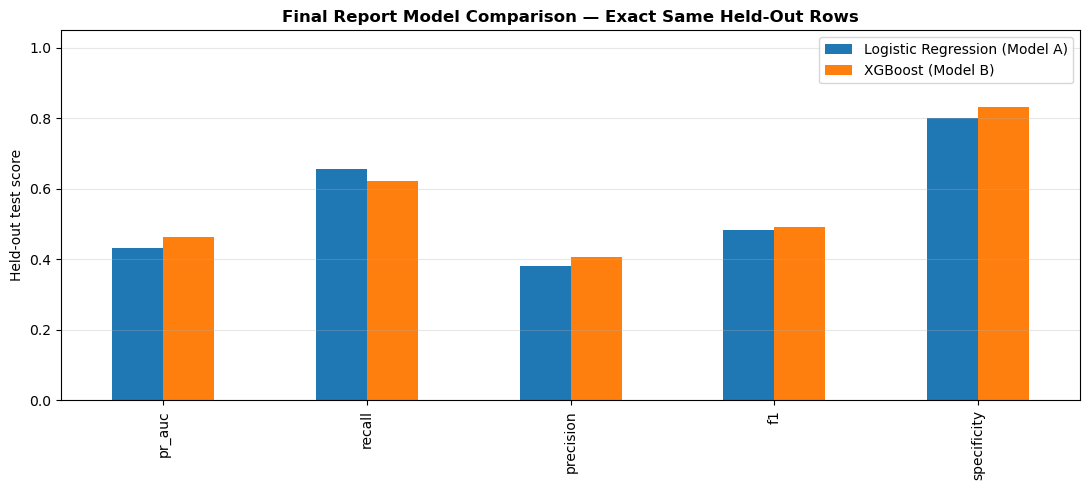

In [22]:
from mlflow.tracking import MlflowClient
import mlflow.sklearn

client = MlflowClient()

# ------------------------------------------------------------
# 1. Majority-class naive benchmark
# ------------------------------------------------------------
majority_class = int(y_train.mode().iloc[0])
majority_pred = np.full(shape=y_test.shape, fill_value=majority_class)
majority_proba = np.full(shape=y_test.shape, fill_value=float(y_train.mean()))

_tn_maj, _fp_maj, _fn_maj, _tp_maj = confusion_matrix(y_test, majority_pred, labels=[0, 1]).ravel()

majority_metrics = {
    "accuracy": round(accuracy_score(y_test, majority_pred), 4),
    "balanced_accuracy": round(balanced_accuracy_score(y_test, majority_pred), 4),
    "f1": round(f1_score(y_test, majority_pred, zero_division=0), 4),
    "f2": round(fbeta_score(y_test, majority_pred, beta=2, zero_division=0), 4),
    "precision": round(precision_score(y_test, majority_pred, zero_division=0), 4),
    "recall": round(recall_score(y_test, majority_pred, zero_division=0), 4),
    "specificity": round(_tn_maj / (_tn_maj + _fp_maj), 4) if (_tn_maj + _fp_maj) > 0 else np.nan,
    "fpr": float(_fp_maj / (_fp_maj + _tn_maj)) if (_fp_maj + _tn_maj) > 0 else np.nan,
    "fnr": float(_fn_maj / (_fn_maj + _tp_maj)) if (_fn_maj + _tp_maj) > 0 else np.nan,
    "pr_auc": round(average_precision_score(y_test, majority_proba), 4),
    "roc_auc": np.nan,
    "brier": round(brier_score_loss(y_test, majority_proba), 4),
}

# ------------------------------------------------------------
# 2. Rule-based heuristic — context, not the main ML baseline
# ------------------------------------------------------------
def heuristic_score(df):
    score = pd.Series(0, index=df.index)
    if "HighBP" in df.columns:
        score += (df["HighBP"] == 1).astype(int)
    if "HighChol" in df.columns:
        score += (df["HighChol"] == 1).astype(int)
    if "BMI" in df.columns:
        score += (df["BMI"] >= 30).astype(int)
    if "Age" in df.columns:
        score += (df["Age"] >= 9).astype(int)
    if "GenHlth" in df.columns:
        score += (df["GenHlth"] >= 4).astype(int)
    return score

HEURISTIC_FLAG_THRESHOLD = 2
heuristic_raw_score = heuristic_score(X_test)
heuristic_pred = (heuristic_raw_score >= HEURISTIC_FLAG_THRESHOLD).astype(int).to_numpy()
heuristic_proba = (heuristic_raw_score / max(float(heuristic_raw_score.max()), 1.0)).to_numpy()

_tn_heu, _fp_heu, _fn_heu, _tp_heu = confusion_matrix(y_test, heuristic_pred, labels=[0, 1]).ravel()

heuristic_metrics = {
    "accuracy": round(accuracy_score(y_test, heuristic_pred), 4),
    "balanced_accuracy": round(balanced_accuracy_score(y_test, heuristic_pred), 4),
    "f1": round(f1_score(y_test, heuristic_pred, zero_division=0), 4),
    "f2": round(fbeta_score(y_test, heuristic_pred, beta=2, zero_division=0), 4),
    "precision": round(precision_score(y_test, heuristic_pred, zero_division=0), 4),
    "recall": round(recall_score(y_test, heuristic_pred, zero_division=0), 4),
    "specificity": round(_tn_heu / (_tn_heu + _fp_heu), 4) if (_tn_heu + _fp_heu) > 0 else np.nan,
    "fpr": float(_fp_heu / (_fp_heu + _tn_heu)) if (_fp_heu + _tn_heu) > 0 else np.nan,
    "fnr": float(_fn_heu / (_fn_heu + _tp_heu)) if (_fn_heu + _tp_heu) > 0 else np.nan,
    "pr_auc": round(average_precision_score(y_test, heuristic_proba), 4),
    "roc_auc": np.nan,
    "brier": round(brier_score_loss(y_test, heuristic_proba), 4),
}

# ------------------------------------------------------------
# 3. v10 Final Report evidence lock — Logistic Regression
#    Pin the exact latest LR final run from the supplied evidence CSV,
#    verify candidate/threshold lineage, then re-score it on THIS X_test.
# ------------------------------------------------------------
LR_EVIDENCE_FILE = "S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv"
XGB_EVIDENCE_FILE = "S202_8440104B_XGBost_Experiments_Evidence_Runs.csv"

LR_EVIDENCE_RUN_ID = "82bc9a4720e04a50ae942128305eb90d"
LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID = "74e8884c230349f3ad29021db15f54a2"
LR_EVIDENCE_THRESHOLD_TUNING_RUN_ID = "4d0a1f65fd754905bb85a4459886cb10"
LR_EVIDENCE_C = 100.0
LR_EVIDENCE_CLASS_WEIGHT = "balanced"
LR_EVIDENCE_THRESHOLD = 0.59

LR_EVIDENCE_METRICS = {
    "accuracy": 0.777593819,
    "balanced_accuracy": 0.728437831,
    "f1": 0.482005141,
    "precision": 0.38073827,
    "recall": 0.656660413,
    "specificity": 0.80021525,
    "fpr": 0.19978475,
    "fnr": 0.343339587,
    "pr_auc": 0.432748858,
    "roc_auc": 0.817565379,
}

XGB_EVIDENCE_RUN_ID = "dca27f6422344d249069ab863b1541fa"
XGB_EVIDENCE_SELECTED_CANDIDATE_RUN_ID = "1a5d70bd05f546748e6a8357214e22c3"
XGB_EVIDENCE_THRESHOLD_TUNING_RUN_ID = "a37746ea4fa7404cb09ddebcf520daba"
XGB_EVIDENCE_THRESHOLD = 0.5
XGB_EVIDENCE_CONFIG = {
    "max_depth": 4,
    "learning_rate": 0.03,
    "scale_pos_weight": 3.0,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 10.0,
    "gamma": 0.05,
    "n_estimators": 450,
}
XGB_EVIDENCE_METRICS = {
    "accuracy": 0.798151214,
    "balanced_accuracy": 0.726302148,
    "f1": 0.492441889,
    "precision": 0.407814809,
    "recall": 0.621388368,
    "specificity": 0.831215928,
    "fpr": 0.168784072,
    "fnr": 0.378611632,
    "pr_auc": 0.464397478,
    "roc_auc": 0.824820173,
}

# Tight enough to catch a different experiment, but tolerant of harmless
# floating-point representation differences in exported CSVs.
EVIDENCE_METRIC_ATOL = 1e-6
EVIDENCE_PARAM_ATOL = 1e-12

LR_COMPARISON_AVAILABLE = False
LR_FINAL_RUN_ID = LR_EVIDENCE_RUN_ID
LR_FINAL_RUN_START_TIME = None
LR_FEATURE_SET_MATCH = False
LR_REEVALUATED_ON_XGB_TEST_ROWS = False
LR_COMPATIBILITY_CHECKS = {}
LR_EVIDENCE_METRIC_CHECKS = {}
LR_EVIDENCE_VALIDATED = False
lr_model = None
lr_threshold = None
lr_metrics = {k: np.nan for k in [
    "accuracy", "balanced_accuracy", "f1", "f2", "precision", "recall",
    "specificity", "fpr", "fnr", "pr_auc", "roc_auc", "brier"
]}

try:
    pinned_lr_run = mlflow_call_with_retry(client.get_run, LR_EVIDENCE_RUN_ID)
except Exception as exc:
    raise RuntimeError(
        "Could not load the evidence-pinned Logistic Regression final run "
        f"{LR_EVIDENCE_RUN_ID} from MLflow. v10 will not fall back to a different LR run."
    ) from exc

LR_FINAL_RUN_START_TIME = pd.to_datetime(
    pinned_lr_run.info.start_time, unit="ms", utc=True
)

lr_params = pinned_lr_run.data.params
lr_tags = pinned_lr_run.data.tags

def _optional_num_match(raw_value, expected, cast=float, tol=EVIDENCE_PARAM_ATOL):
    if raw_value in (None, ""):
        return True
    try:
        return abs(float(cast(float(raw_value))) - float(cast(float(expected)))) <= tol
    except Exception:
        return False

source_value = lr_tags.get("data_source_s3_uri") or lr_params.get("data_source_s3_uri")
LR_COMPATIBILITY_CHECKS = {
    "run_id_is_evidence_pinned": pinned_lr_run.info.run_id == LR_EVIDENCE_RUN_ID,
    "run_type_final_holdout": lr_tags.get("run_type") in (None, "", "final_holdout_evaluation"),
    "data_profile_match": (lr_tags.get("data_profile") or lr_params.get("data_profile")) in (None, "", DATA_PROFILE),
    "data_source_match": source_value in (None, "", CLEANED_S3_URI),
    "profile_rows_match": _optional_num_match(lr_params.get("profile_rows"), PROFILE_ROWS, int),
    "full_dataset_rows_match": _optional_num_match(
        lr_params.get("full_dataset_rows"), FULL_DATASET_ROWS, int
    ),
    "profile_fraction_match": _optional_num_match(
        lr_params.get("profile_fraction"), PROFILE_FRACTION, float
    ),
    "feature_count_match": _optional_num_match(
        lr_params.get("n_features"), X_test.shape[1], int
    ),
    "selected_candidate_run_id_match": (
        lr_params.get("selected_candidate_run_id") == LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID
    ),
    "threshold_tuning_run_id_match": (
        lr_params.get("threshold_tuning_run_id") == LR_EVIDENCE_THRESHOLD_TUNING_RUN_ID
    ),
}

threshold_raw = lr_params.get("classification_threshold")
if threshold_raw in (None, ""):
    raise ValueError(
        f"Pinned LR final run {LR_EVIDENCE_RUN_ID} does not record classification_threshold."
    )
lr_threshold = float(threshold_raw)
LR_COMPATIBILITY_CHECKS["classification_threshold_match"] = bool(
    np.isclose(lr_threshold, LR_EVIDENCE_THRESHOLD, atol=EVIDENCE_PARAM_ATOL, rtol=0.0)
)

# Verify the selected LR candidate itself is the balanced candidate declared
# in the latest LR evidence CSV.
try:
    pinned_lr_candidate_run = mlflow_call_with_retry(
        client.get_run, LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID
    )
except Exception as exc:
    raise RuntimeError(
        "Could not load the LR selected-candidate run recorded by the latest evidence CSV: "
        f"{LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID}"
    ) from exc

candidate_params = pinned_lr_candidate_run.data.params
candidate_c = float(candidate_params.get("C"))
candidate_class_weight = candidate_params.get("class_weight")
LR_COMPATIBILITY_CHECKS["candidate_C_match"] = bool(
    np.isclose(candidate_c, LR_EVIDENCE_C, atol=EVIDENCE_PARAM_ATOL, rtol=0.0)
)
LR_COMPATIBILITY_CHECKS["candidate_class_weight_match"] = (
    str(candidate_class_weight) == LR_EVIDENCE_CLASS_WEIGHT
)
LR_COMPATIBILITY_CHECKS["candidate_cv_pr_auc_match"] = bool(
    np.isclose(
        float(pinned_lr_candidate_run.data.metrics.get("cv_pr_auc_mean")),
        0.429812989,
        atol=EVIDENCE_METRIC_ATOL, rtol=0.0
    )
)
LR_COMPATIBILITY_CHECKS["candidate_cv_roc_auc_match"] = bool(
    np.isclose(
        float(pinned_lr_candidate_run.data.metrics.get("cv_roc_auc_mean")),
        0.817737061,
        atol=EVIDENCE_METRIC_ATOL, rtol=0.0
    )
)

if not all(LR_COMPATIBILITY_CHECKS.values()):
    failed = [name for name, passed in LR_COMPATIBILITY_CHECKS.items() if not passed]
    raise ValueError(
        "Evidence-pinned LR run failed v10 lineage/compatibility checks: "
        + ", ".join(failed)
    )

lr_model_uri = f"runs:/{LR_EVIDENCE_RUN_ID}/model"
lr_model = mlflow_call_with_retry(mlflow.sklearn.load_model, lr_model_uri)

feature_names = getattr(lr_model, "feature_names_in_", None)
if feature_names is not None:
    LR_FEATURE_SET_MATCH = list(feature_names) == list(X_test.columns)
else:
    LR_FEATURE_SET_MATCH = (
        getattr(lr_model, "n_features_in_", X_test.shape[1]) == X_test.shape[1]
    )

if not LR_FEATURE_SET_MATCH:
    raise ValueError(
        "Evidence-pinned LR model feature schema does not match this XGBoost notebook's X_test."
    )

# Critical apples-to-apples step: recompute LR on THIS notebook's exact held-out rows.
lr_eval = evaluate_final_model(
    lr_model, X_train, y_train, X_test, y_test, threshold=lr_threshold,
)
lr_metrics = {
    "accuracy": lr_eval["test_accuracy"],
    "balanced_accuracy": lr_eval["test_balanced_accuracy"],
    "f1": lr_eval["test_f1"],
    "f2": lr_eval["test_f2"],
    "precision": lr_eval["test_precision"],
    "recall": lr_eval["test_recall"],
    "specificity": lr_eval["test_specificity"],
    "fpr": lr_eval["test_fpr"],
    "fnr": lr_eval["test_fnr"],
    "pr_auc": lr_eval["test_pr_auc"],
    "roc_auc": lr_eval["test_auc_roc"],
    "brier": lr_eval["test_brier"],
}

LR_REEVALUATED_ON_XGB_TEST_ROWS = True

# Validate the metrics that are present in the supplied LR evidence CSV.
for metric_name, expected_value in LR_EVIDENCE_METRICS.items():
    actual_value = float(lr_metrics[metric_name])
    LR_EVIDENCE_METRIC_CHECKS[metric_name] = bool(
        np.isclose(
            actual_value, expected_value,
            atol=EVIDENCE_METRIC_ATOL, rtol=0.0
        )
    )

LR_EVIDENCE_VALIDATED = bool(
    LR_FEATURE_SET_MATCH
    and LR_REEVALUATED_ON_XGB_TEST_ROWS
    and all(LR_COMPATIBILITY_CHECKS.values())
    and all(LR_EVIDENCE_METRIC_CHECKS.values())
)
LR_COMPARISON_AVAILABLE = LR_EVIDENCE_VALIDATED

if not LR_EVIDENCE_VALIDATED:
    failed_metrics = [
        name for name, passed in LR_EVIDENCE_METRIC_CHECKS.items() if not passed
    ]
    raise ValueError(
        "The pinned LR model did not reproduce the supplied latest LR evidence metrics "
        f"on this notebook's exact X_test. Failed metric checks: {failed_metrics}. "
        "Do not declare a Final Report champion until the data split/evidence mismatch is resolved."
    )

print("=" * 96)
print("V10 VERIFIED EVIDENCE-PINNED LOGISTIC REGRESSION FINAL RUN")
print("=" * 96)
print("  Evidence CSV           :", LR_EVIDENCE_FILE)
print("  Final LR Run ID        :", LR_FINAL_RUN_ID)
print("  Run start time         :", LR_FINAL_RUN_START_TIME)
print("  Selected candidate     :", LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID)
print("  Candidate C            :", candidate_c)
print("  Candidate class_weight :", candidate_class_weight)
print("  Threshold tuning run   :", LR_EVIDENCE_THRESHOLD_TUNING_RUN_ID)
print("  LR selected threshold  :", lr_threshold)
print("  Common test SHA256     :", TEST_SPLIT_SHA256)
print("  Feature schema match   :", LR_FEATURE_SET_MATCH)
print("  Re-evaluated on X_test :", LR_REEVALUATED_ON_XGB_TEST_ROWS)
print("  Evidence metric checks :", LR_EVIDENCE_METRIC_CHECKS)
print("  Evidence validated     :", LR_EVIDENCE_VALIDATED)
print("=" * 96)

# ------------------------------------------------------------
# 4. XGBoost metrics — same evaluation metric definitions as LR
# ------------------------------------------------------------
xgb_metrics = {
    "accuracy": final_metrics["test_accuracy"],
    "balanced_accuracy": final_metrics["test_balanced_accuracy"],
    "f1": final_metrics["test_f1"],
    "f2": final_metrics["test_f2"],
    "precision": final_metrics["test_precision"],
    "recall": final_metrics["test_recall"],
    "specificity": final_metrics["test_specificity"],
    "fpr": final_metrics["test_fpr"],
    "fnr": final_metrics["test_fnr"],
    "pr_auc": final_metrics["test_pr_auc"],
    "roc_auc": final_metrics["test_auc_roc"],
    "brier": final_metrics["test_brier"],
}

# v10: validate this XGBoost result against the supplied Model B evidence CSV.
XGB_EVIDENCE_CONFIG_CHECKS = {
    "max_depth": int(SELECTED_MAX_DEPTH) == XGB_EVIDENCE_CONFIG["max_depth"],
    "learning_rate": bool(np.isclose(
        float(SELECTED_LEARNING_RATE), XGB_EVIDENCE_CONFIG["learning_rate"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "scale_pos_weight": bool(np.isclose(
        float(SELECTED_SCALE_POS_WEIGHT), XGB_EVIDENCE_CONFIG["scale_pos_weight"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "min_child_weight": bool(np.isclose(
        float(SELECTED_MIN_CHILD_WEIGHT), XGB_EVIDENCE_CONFIG["min_child_weight"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "subsample": bool(np.isclose(
        float(SELECTED_SUBSAMPLE), XGB_EVIDENCE_CONFIG["subsample"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "colsample_bytree": bool(np.isclose(
        float(SELECTED_COLSAMPLE_BYTREE), XGB_EVIDENCE_CONFIG["colsample_bytree"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "reg_alpha": bool(np.isclose(
        float(SELECTED_REG_ALPHA), XGB_EVIDENCE_CONFIG["reg_alpha"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "reg_lambda": bool(np.isclose(
        float(SELECTED_REG_LAMBDA), XGB_EVIDENCE_CONFIG["reg_lambda"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "gamma": bool(np.isclose(
        float(SELECTED_GAMMA), XGB_EVIDENCE_CONFIG["gamma"],
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "n_estimators": int(BEST_N_ESTIMATORS) == XGB_EVIDENCE_CONFIG["n_estimators"],
    "threshold": bool(np.isclose(
        float(OPTIMAL_THRESHOLD), XGB_EVIDENCE_THRESHOLD,
        atol=EVIDENCE_PARAM_ATOL, rtol=0.0
    )),
    "selection_cv_pr_auc": bool(np.isclose(
        float(BEST_CV_PR_AUC), 0.459491315,
        atol=EVIDENCE_METRIC_ATOL, rtol=0.0
    )),
    "selection_cv_roc_auc": bool(np.isclose(
        float(BEST_CV_ROC_AUC), 0.825413606,
        atol=EVIDENCE_METRIC_ATOL, rtol=0.0
    )),
}

XGB_EVIDENCE_METRIC_CHECKS = {}
for metric_name, expected_value in XGB_EVIDENCE_METRICS.items():
    actual_value = float(xgb_metrics[metric_name])
    XGB_EVIDENCE_METRIC_CHECKS[metric_name] = bool(
        np.isclose(
            actual_value, expected_value,
            atol=EVIDENCE_METRIC_ATOL, rtol=0.0
        )
    )

XGB_EVIDENCE_VALIDATED = bool(
    all(XGB_EVIDENCE_CONFIG_CHECKS.values())
    and all(XGB_EVIDENCE_METRIC_CHECKS.values())
)

if not XGB_EVIDENCE_VALIDATED:
    failed_config = [
        name for name, passed in XGB_EVIDENCE_CONFIG_CHECKS.items() if not passed
    ]
    failed_metrics = [
        name for name, passed in XGB_EVIDENCE_METRIC_CHECKS.items() if not passed
    ]
    raise ValueError(
        "This XGBoost execution does not reproduce the supplied latest XGBoost evidence. "
        f"Config mismatches={failed_config}; metric mismatches={failed_metrics}. "
        "Review before declaring a Final Report champion."
    )

print("\nV10 XGBOOST EVIDENCE VALIDATION")
print("  Evidence CSV           :", XGB_EVIDENCE_FILE)
print("  Cited evidence Run ID  :", XGB_EVIDENCE_RUN_ID)
print("  Current execution Run  :", FINAL_RUN_ID)
print("  Config checks          :", XGB_EVIDENCE_CONFIG_CHECKS)
print("  Metric checks          :", XGB_EVIDENCE_METRIC_CHECKS)
print("  Evidence validated     :", XGB_EVIDENCE_VALIDATED)

# ------------------------------------------------------------
# 5. Side-by-side comparison and deltas
# ------------------------------------------------------------
comparison_table = pd.DataFrame({
    "Majority-class naive benchmark": majority_metrics,
    "Rule-based heuristic": heuristic_metrics,
    "Logistic Regression (Model A)": lr_metrics,
    "XGBoost (Model B)": xgb_metrics,
}).T

metric_order = [
    "pr_auc", "roc_auc", "recall", "precision", "f1", "f2",
    "specificity", "fpr", "fnr", "balanced_accuracy", "accuracy", "brier"
]
comparison_table = comparison_table[[c for c in metric_order if c in comparison_table.columns]]

print("\n" + "=" * 112)
print("FINAL REPORT STRICT MODEL COMPARISON — EXACT SAME HELD-OUT TEST ROWS")
print("=" * 112)
print(comparison_table.to_string(float_format=lambda v: f"{v:.6f}" if pd.notna(v) else "n/a"))
print("=" * 112)

if LR_COMPARISON_AVAILABLE:
    # Positive delta means XGBoost is better. For lower-is-better metrics
    # (FPR, FNR, Brier), calculate LR - XGB.
    higher_is_better = [
        "pr_auc", "roc_auc", "recall", "precision", "f1", "f2",
        "specificity", "balanced_accuracy", "accuracy"
    ]
    deltas = {
        metric: float(xgb_metrics[metric] - lr_metrics[metric])
        for metric in higher_is_better
    }
    for metric in ["fpr", "fnr", "brier"]:
        deltas[metric] = float(lr_metrics[metric] - xgb_metrics[metric])

    delta_df = pd.DataFrame([
        {
            "metric": metric,
            "xgboost_advantage": value,
            "direction": "higher better" if metric in higher_is_better else "lower better",
        }
        for metric, value in deltas.items()
    ])

    print("\nXGBoost advantage over Logistic Regression")
    print("(positive always means XGBoost is better after direction adjustment)")
    print(delta_df.to_string(index=False, float_format=lambda v: f"{v:+.6f}"))

# ------------------------------------------------------------
# 6. Log comparison evidence
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
plot_metrics = ["pr_auc", "recall", "precision", "f1", "specificity"]
plot_df = comparison_table.loc[
    ["Logistic Regression (Model A)", "XGBoost (Model B)"], plot_metrics
] if LR_COMPARISON_AVAILABLE else comparison_table.loc[
    ["XGBoost (Model B)"], plot_metrics
]
plot_df.T.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Held-out test score")
ax.set_title("Final Report Model Comparison — Exact Same Held-Out Rows", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.set_tag("strict_lr_comparison_available", str(LR_COMPARISON_AVAILABLE).lower())
    mlflow.set_tag("lr_re_evaluated_on_xgb_test_rows", str(LR_REEVALUATED_ON_XGB_TEST_ROWS).lower())
    mlflow.set_tag("lr_feature_schema_match", str(LR_FEATURE_SET_MATCH).lower())
    mlflow.log_param("comparison_test_split_sha256", TEST_SPLIT_SHA256)
    mlflow.log_param("comparison_method", "evidence_pinned_lr_run_and_rescore_on_xgb_test_rows")
    if LR_FINAL_RUN_ID:
        mlflow.log_param("comparison_lr_run_id", LR_FINAL_RUN_ID)
        mlflow.log_param("comparison_lr_threshold", float(lr_threshold))

    with tempfile.TemporaryDirectory() as tmp:
        comparison_csv = f"{tmp}/strict_model_comparison.csv"
        comparison_table.to_csv(comparison_csv)
        mlflow.log_artifact(comparison_csv, artifact_path="comparison")

        fig_path = f"{tmp}/strict_model_comparison.png"
        fig.savefig(fig_path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(fig_path, artifact_path="comparison")

        if LR_COMPARISON_AVAILABLE:
            delta_csv = f"{tmp}/xgb_vs_lr_deltas.csv"
            delta_df.to_csv(delta_csv, index=False)
            mlflow.log_artifact(delta_csv, artifact_path="comparison")

            proof_path = f"{tmp}/apples_to_apples_proof.json"
            with open(proof_path, "w") as fh:
                json.dump({
                    "comparison_lr_run_id": LR_FINAL_RUN_ID,
                    "comparison_lr_threshold": float(lr_threshold),
                    "lr_evidence_file": LR_EVIDENCE_FILE,
                    "lr_evidence_run_id": LR_EVIDENCE_RUN_ID,
                    "lr_evidence_selected_candidate_run_id": LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID,
                    "lr_evidence_threshold_tuning_run_id": LR_EVIDENCE_THRESHOLD_TUNING_RUN_ID,
                    "lr_evidence_validated": bool(LR_EVIDENCE_VALIDATED),
                    "lr_evidence_metric_checks": LR_EVIDENCE_METRIC_CHECKS,
                    "xgb_evidence_file": XGB_EVIDENCE_FILE,
                    "xgb_evidence_run_id": XGB_EVIDENCE_RUN_ID,
                    "xgb_evidence_validated": bool(XGB_EVIDENCE_VALIDATED),
                    "xgb_evidence_config_checks": XGB_EVIDENCE_CONFIG_CHECKS,
                    "xgb_evidence_metric_checks": XGB_EVIDENCE_METRIC_CHECKS,
                    "lr_feature_schema_match": bool(LR_FEATURE_SET_MATCH),
                    "lr_re_evaluated_on_xgb_test_rows": bool(LR_REEVALUATED_ON_XGB_TEST_ROWS),
                    "xgb_test_split_sha256": TEST_SPLIT_SHA256,
                    "test_rows": int(len(X_test)),
                    "feature_columns": list(X_test.columns),
                    "compatibility_checks": LR_COMPATIBILITY_CHECKS,
                }, fh, indent=2, default=str)
            mlflow.log_artifact(proof_path, artifact_path="comparison")

plt.show()


## 15. Final Report Champion Decision — PR-AUC Primary, Governance Trade-offs Explicit

The project treats **PR-AUC as the predefined primary model-selection metric** because the positive
class is imbalanced. The champion decision therefore follows the predeclared metric hierarchy rather
than requiring one model to beat the other on every secondary measure.

This section uses two layers:

1. **Champion performance rule:** Logistic Regression and XGBoost are compared on the **exact same
   held-out rows**, with held-out PR-AUC primary. ROC-AUC, F1/F2, precision, recall, specificity,
   FPR/FNR, balanced accuracy and Brier score are reported as supporting evidence and trade-offs.
2. **Hard execution controls:** the apples-to-apples comparison must be verified, the selected
   XGBoost run must pass the notebook's existing quality gate, and explainability evidence must be
   available. These controls confirm that the comparison/evidence is usable; they are not newly
   invented performance criteria.

**Calibration and subgroup fairness remain important governance findings, not silent blockers.**
For example, poorer Brier score is reported as a calibration limitation and higher recall/FNR gaps
are reported as screening/fairness trade-offs. They should override PR-AUC only if the team's
**original Proposal explicitly made them hard champion gates before the final test results were
known**.

This prevents post-hoc model selection while keeping all Final Report limitations visible.

### v10 current evidence outcome

Using the latest supplied evidence, XGBoost remains the champion on the predefined primary metric:
held-out PR-AUC is **0.464397 for XGBoost versus 0.432749 for Logistic Regression**
(**+0.031649** absolute). XGBoost also improves ROC-AUC, precision, F1, specificity and overall
accuracy, while the balanced LR retains higher recall (**0.656660 vs 0.621388**) and fewer false
negatives (**2,745 vs 3,027**). The champion conclusion is therefore **XGBoost**, with the recall/FNR
trade-off explicitly retained in the Final Report rather than hidden.


In [23]:
# ==========================================================
# Final Report champion decision:
# PR-AUC primary + explicit governance observations
# ==========================================================
PRIMARY_CHAMPION_METRIC = "pr_auc"
MIN_PR_AUC_IMPROVEMENT = 0.0

# These tolerances are retained for INTERPRETATION only.
# They are not hard champion gates unless they were explicitly predeclared
# in the original Proposal before final held-out results were observed.
CALIBRATION_OBSERVATION_TOLERANCE = 0.01
FAIRNESS_OBSERVATION_TOLERANCE = 0.05

heuristic_context_pass = (
    xgb_metrics["f1"] > heuristic_metrics["f1"]
    and xgb_metrics["pr_auc"] > heuristic_metrics["pr_auc"]
)

if LR_COMPARISON_AVAILABLE:
    # Recompute LR fairness on the exact same held-out rows and its own selected threshold.
    lr_fairness_df, lr_fairness_flags = compute_subgroup_fairness(
        lr_model, X_test, y_test, threshold=lr_threshold,
    )

    def fairness_gap_summary(fairness_df):
        rows = []
        for attribute, group_df in fairness_df.groupby("attribute"):
            reliable = group_df[group_df["sufficient_sample"]]
            if reliable.empty:
                continue
            recall_values = reliable["recall"].dropna()
            fpr_values = reliable["false_positive_rate"].dropna()
            rows.append({
                "attribute": attribute,
                "recall_gap": float(recall_values.max() - recall_values.min())
                if len(recall_values) >= 2 else np.nan,
                "fpr_gap": float(fpr_values.max() - fpr_values.min())
                if len(fpr_values) >= 2 else np.nan,
            })
        return pd.DataFrame(rows)

    xgb_gap_df = fairness_gap_summary(fairness_df).set_index("attribute")
    lr_gap_df = fairness_gap_summary(lr_fairness_df).set_index("attribute")
    fairness_compare = xgb_gap_df.join(
        lr_gap_df, lsuffix="_xgb", rsuffix="_lr", how="outer"
    )
    fairness_compare["recall_gap_worsening"] = (
        fairness_compare["recall_gap_xgb"] - fairness_compare["recall_gap_lr"]
    )
    fairness_compare["fpr_gap_worsening"] = (
        fairness_compare["fpr_gap_xgb"] - fairness_compare["fpr_gap_lr"]
    )

    materially_worse_fairness = (
        (fairness_compare["recall_gap_worsening"] > FAIRNESS_OBSERVATION_TOLERANCE)
        | (fairness_compare["fpr_gap_worsening"] > FAIRNESS_OBSERVATION_TOLERANCE)
    ).fillna(False).any()
    fairness_not_materially_worse = not materially_worse_fairness

    pr_auc_delta = float(xgb_metrics["pr_auc"] - lr_metrics["pr_auc"])
    brier_delta = float(xgb_metrics["brier"] - lr_metrics["brier"])
    calibration_not_materially_worse = (
        brier_delta <= CALIBRATION_OBSERVATION_TOLERANCE
    )

    # Secondary metrics are evidence/trade-offs, not hard champion gates.
    model_comparison_checks = {
        "Primary PR-AUC improves over LR": pr_auc_delta > MIN_PR_AUC_IMPROVEMENT,
        "ROC-AUC >= LR (supporting)": xgb_metrics["roc_auc"] >= lr_metrics["roc_auc"],
        "F1 >= LR (supporting)": xgb_metrics["f1"] >= lr_metrics["f1"],
        "F2 >= LR (trade-off)": xgb_metrics["f2"] >= lr_metrics["f2"],
        "Recall >= LR (trade-off)": xgb_metrics["recall"] >= lr_metrics["recall"],
        "Precision >= LR (supporting)": xgb_metrics["precision"] >= lr_metrics["precision"],
        "Specificity >= LR (supporting)": xgb_metrics["specificity"] >= lr_metrics["specificity"],
        "FPR <= LR (supporting)": xgb_metrics["fpr"] <= lr_metrics["fpr"],
        "FNR <= LR (trade-off)": xgb_metrics["fnr"] <= lr_metrics["fnr"],
        "Balanced accuracy >= LR (supporting)": (
            xgb_metrics["balanced_accuracy"] >= lr_metrics["balanced_accuracy"]
        ),
        "Calibration within interpretation tolerance": calibration_not_materially_worse,
        "Fairness gaps within interpretation tolerance": fairness_not_materially_worse,
    }

    secondary_tradeoffs = {
        "recall_delta_xgb_minus_lr": float(
            xgb_metrics["recall"] - lr_metrics["recall"]
        ),
        "fnr_delta_xgb_minus_lr": float(
            xgb_metrics["fnr"] - lr_metrics["fnr"]
        ),
        "f2_delta_xgb_minus_lr": float(
            xgb_metrics["f2"] - lr_metrics["f2"]
        ),
        "balanced_accuracy_delta_xgb_minus_lr": float(
            xgb_metrics["balanced_accuracy"] - lr_metrics["balanced_accuracy"]
        ),
        "brier_delta_xgb_minus_lr": brier_delta,
    }

    # Hard controls confirm the comparison and evidence are valid.
    # Calibration/fairness are governance observations unless the Proposal
    # explicitly predeclared them as hard champion criteria.
    hard_selection_gates = {
        "Verified exact-row LR comparison": bool(LR_COMPARISON_AVAILABLE),
        "Latest LR evidence snapshot validated": bool(LR_EVIDENCE_VALIDATED),
        "Latest XGBoost evidence snapshot validated": bool(XGB_EVIDENCE_VALIDATED),
        "XGBoost existing quality gate passed": bool(QUALITY_GATE_PASSED),
        "SHAP explainability logged": True,
    }

    governance_observations = {
        "Calibration not materially worse than LR": bool(
            calibration_not_materially_worse
        ),
        "Fairness gaps not materially worse than LR": bool(
            fairness_not_materially_worse
        ),
        "XGBoost recall >= LR": bool(
            xgb_metrics["recall"] >= lr_metrics["recall"]
        ),
        "XGBoost FNR <= LR": bool(
            xgb_metrics["fnr"] <= lr_metrics["fnr"]
        ),
    }

    # Champion performance hierarchy:
    # 1) PR-AUC primary
    # 2) exact/near tie -> F1
    # 3) remaining tie -> ROC-AUC
    if pr_auc_delta > MIN_PR_AUC_IMPROVEMENT:
        PERFORMANCE_RECOMMENDATION = "XGBoost"
    elif pr_auc_delta < -MIN_PR_AUC_IMPROVEMENT:
        PERFORMANCE_RECOMMENDATION = "Logistic Regression"
    else:
        if xgb_metrics["f1"] > lr_metrics["f1"]:
            PERFORMANCE_RECOMMENDATION = "XGBoost"
        elif xgb_metrics["f1"] < lr_metrics["f1"]:
            PERFORMANCE_RECOMMENDATION = "Logistic Regression"
        else:
            PERFORMANCE_RECOMMENDATION = (
                "XGBoost"
                if xgb_metrics["roc_auc"] >= lr_metrics["roc_auc"]
                else "Logistic Regression"
            )

    if (
        PERFORMANCE_RECOMMENDATION == "XGBoost"
        and all(hard_selection_gates.values())
    ):
        CHAMPION_MODEL = "XGBoost"
    elif (
        PERFORMANCE_RECOMMENDATION == "Logistic Regression"
        and bool(LR_COMPARISON_AVAILABLE)
    ):
        CHAMPION_MODEL = "Logistic Regression"
    else:
        CHAMPION_MODEL = "UNDETERMINED"

    CHAMPION_RATIONALE = (
        f"Using the v10 evidence-pinned latest LR run, PR-AUC is the predefined primary metric. "
        f"On the exact same held-out rows, "
        f"XGBoost PR-AUC={xgb_metrics['pr_auc']:.6f} versus "
        f"LR={lr_metrics['pr_auc']:.6f} (delta={pr_auc_delta:+.6f}). "
        f"Performance recommendation={PERFORMANCE_RECOMMENDATION}. "
        f"Recall trade-off: XGBoost={xgb_metrics['recall']:.6f}, "
        f"LR={lr_metrics['recall']:.6f}; "
        f"FNR: XGBoost={xgb_metrics['fnr']:.6f}, LR={lr_metrics['fnr']:.6f}. "
        f"Calibration trade-off (Brier, lower is better): "
        f"XGBoost={xgb_metrics['brier']:.6f}, LR={lr_metrics['brier']:.6f}. "
        f"Calibration/fairness are documented governance observations rather than "
        f"new post-hoc hard blockers. Final champion={CHAMPION_MODEL}."
    )
else:
    lr_fairness_df = None
    fairness_compare = None
    model_comparison_checks = {}
    secondary_tradeoffs = {}
    hard_selection_gates = {
        "Verified exact-row LR comparison": False,
        "Latest LR evidence snapshot validated": bool(
            globals().get("LR_EVIDENCE_VALIDATED", False)
        ),
        "Latest XGBoost evidence snapshot validated": bool(
            globals().get("XGB_EVIDENCE_VALIDATED", False)
        ),
        "XGBoost existing quality gate passed": bool(QUALITY_GATE_PASSED),
        "SHAP explainability logged": True,
    }
    governance_observations = {}
    PERFORMANCE_RECOMMENDATION = "UNDETERMINED"
    CHAMPION_MODEL = "UNDETERMINED"
    CHAMPION_RATIONALE = (
        "No verified latest Logistic Regression final model was available for "
        "exact-row re-evaluation. Run the full-data LR Final Report notebook first, "
        "then rerun this notebook."
    )
    pr_auc_delta = np.nan
    brier_delta = np.nan

selection_checks = {
    "Verified apples-to-apples LR comparison available": bool(
        LR_COMPARISON_AVAILABLE
    ),
    "Primary metric comparison completed": bool(LR_COMPARISON_AVAILABLE),
    "XGBoost beats heuristic on F1 and PR-AUC (context)": bool(
        heuristic_context_pass
    ),
    **hard_selection_gates,
}

print("=" * 96)
print("FINAL REPORT CHAMPION DECISION — XGBOOST VS LOGISTIC REGRESSION")
print("=" * 96)
print("Primary metric             : PR-AUC")
print(f"Performance recommendation : {PERFORMANCE_RECOMMENDATION}")
print(f"Champion model             : {CHAMPION_MODEL}")
print(f"Rationale                  : {CHAMPION_RATIONALE}")

if LR_COMPARISON_AVAILABLE:
    print("\nMetric checks / trade-offs "
          "(secondary metrics are not automatically hard gates):")
    for check, passed in model_comparison_checks.items():
        label = "PASS" if passed else "TRADE-OFF"
        print(f"  [{label:<9}] {check}")

    print("\nSecondary trade-off deltas:")
    for name, value in secondary_tradeoffs.items():
        print(f"  {name:<44}: {value:+.6f}")

    print("\nHard selection controls:")
    for check, passed in hard_selection_gates.items():
        print(f"  [{'PASS' if passed else 'FAIL':<4}] {check}")

    print("\nGovernance observations "
          "(reported limitations; not post-hoc champion blockers):")
    for check, passed in governance_observations.items():
        print(f"  [{'PASS' if passed else 'LIMITATION':<10}] {check}")

    print("\nFairness gap comparison "
          "(positive worsening means XGBoost gap is larger):")
    print(
        fairness_compare.to_string(
            float_format=lambda v: f"{v:+.4f}" if pd.notna(v) else "n/a"
        )
    )

XGBOOST_MEETS_SELECTION_RULE = CHAMPION_MODEL == "XGBoost"

with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_metric(
        "xgboost_meets_selection_rule",
        int(XGBOOST_MEETS_SELECTION_RULE)
    )
    if LR_COMPARISON_AVAILABLE:
        mlflow.log_metric(
            "champion_pr_auc_delta_xgb_minus_lr",
            float(pr_auc_delta)
        )
        mlflow.log_metric(
            "champion_recall_delta_xgb_minus_lr",
            float(secondary_tradeoffs["recall_delta_xgb_minus_lr"])
        )
        mlflow.log_metric(
            "champion_fnr_delta_xgb_minus_lr",
            float(secondary_tradeoffs["fnr_delta_xgb_minus_lr"])
        )
        mlflow.log_metric(
            "champion_brier_delta_xgb_minus_lr",
            float(secondary_tradeoffs["brier_delta_xgb_minus_lr"])
        )

    mlflow.set_tag("champion_primary_metric", "PR-AUC")
    mlflow.set_tag("final_champion_decision_source", "v10_latest_lr_and_xgb_evidence")
    mlflow.set_tag("lr_evidence_run_id", LR_EVIDENCE_RUN_ID)
    mlflow.set_tag("xgb_evidence_reference_run_id", XGB_EVIDENCE_RUN_ID)
    mlflow.set_tag(
        "champion_rule",
        "PR-AUC primary; secondary calibration/fairness/recall trade-offs documented"
    )
    mlflow.set_tag(
        "performance_recommendation",
        PERFORMANCE_RECOMMENDATION
    )
    mlflow.set_tag("champion_model_decision", CHAMPION_MODEL)
    mlflow.set_tag("champion_rationale", CHAMPION_RATIONALE[:250])

    with tempfile.TemporaryDirectory() as tmp:
        decision_path = f"{tmp}/champion_selection_decision.json"
        with open(decision_path, "w") as fh:
            json.dump(
                {
                    "champion_model": CHAMPION_MODEL,
                    "performance_recommendation": PERFORMANCE_RECOMMENDATION,
                    "primary_metric": "PR-AUC",
                    "primary_metric_delta_xgb_minus_lr": (
                        None if pd.isna(pr_auc_delta)
                        else float(pr_auc_delta)
                    ),
                    "rationale": CHAMPION_RATIONALE,
                    "selection_checks": selection_checks,
                    "metric_checks_and_tradeoffs": model_comparison_checks,
                    "secondary_tradeoffs": secondary_tradeoffs,
                    "hard_selection_gates": hard_selection_gates,
                    "governance_observations": governance_observations,
                    "lr_comparison_run_id": LR_FINAL_RUN_ID,
                    "lr_threshold": lr_threshold,
                    "lr_evidence_file": LR_EVIDENCE_FILE,
                    "lr_evidence_run_id": LR_EVIDENCE_RUN_ID,
                    "lr_evidence_validated": bool(LR_EVIDENCE_VALIDATED),
                    "xgb_evidence_file": XGB_EVIDENCE_FILE,
                    "xgb_evidence_reference_run_id": XGB_EVIDENCE_RUN_ID,
                    "xgb_evidence_validated": bool(XGB_EVIDENCE_VALIDATED),
                    "lr_re_evaluated_on_xgb_test_rows": bool(
                        LR_REEVALUATED_ON_XGB_TEST_ROWS
                    ),
                    "test_split_sha256": TEST_SPLIT_SHA256,
                },
                fh,
                indent=2,
                default=str,
            )
        mlflow.log_artifact(
            decision_path,
            artifact_path="governance"
        )

        if LR_COMPARISON_AVAILABLE and fairness_compare is not None:
            fairness_cmp_path = (
                f"{tmp}/xgb_vs_lr_fairness_gap_comparison.csv"
            )
            fairness_compare.to_csv(fairness_cmp_path)
            mlflow.log_artifact(
                fairness_cmp_path,
                artifact_path="fairness"
            )

FINAL REPORT CHAMPION DECISION — XGBOOST VS LOGISTIC REGRESSION
Primary metric             : PR-AUC
Performance recommendation : XGBoost
Champion model             : XGBoost
Rationale                  : Using the v10 evidence-pinned latest LR run, PR-AUC is the predefined primary metric. On the exact same held-out rows, XGBoost PR-AUC=0.464397 versus LR=0.432749 (delta=+0.031649). Performance recommendation=XGBoost. Recall trade-off: XGBoost=0.621388, LR=0.656660; FNR: XGBoost=0.378612, LR=0.343340. Calibration trade-off (Brier, lower is better): XGBoost=0.133926, LR=0.178607. Calibration/fairness are documented governance observations rather than new post-hoc hard blockers. Final champion=XGBoost.

Metric checks / trade-offs (secondary metrics are not automatically hard gates):
  [PASS     ] Primary PR-AUC improves over LR
  [PASS     ] ROC-AUC >= LR (supporting)
  [PASS     ] F1 >= LR (supporting)
  [TRADE-OFF] F2 >= LR (trade-off)
  [TRADE-OFF] Recall >= LR (trade-off)
  [PASS     ]

## 16. Register the Champion Model in the MLflow Model Registry

If XGBoost was selected as champion, this section registers it under the team's
`REGISTERED_MODEL` name in the MLflow Model Registry, so Notebook 03 (deployment) always resolves
"the approved model" through the registry rather than a hard-coded run ID.

Registration is wrapped in `try/except` because Model Registry support can vary by SageMaker MLflow
App version — a production notebook should degrade gracefully (log a clear warning and continue)
rather than hard-fail the whole pipeline on an optional step.

In [24]:
from mlflow.exceptions import MlflowException

if CHAMPION_MODEL == "XGBoost":
    try:
        model_uri = f"runs:/{FINAL_RUN_ID}/model"
        registered_version = mlflow_call_with_retry(
            mlflow.register_model, model_uri=model_uri, name=REGISTERED_MODEL,
        )

        client.set_model_version_tag(
            name=REGISTERED_MODEL,
            version=registered_version.version,
            key="model_family",
            value=MODEL_FAMILY,
        )
        client.set_model_version_tag(
            name=REGISTERED_MODEL,
            version=registered_version.version,
            key="champion",
            value="true",
        )
        client.update_model_version(
            name=REGISTERED_MODEL,
            version=registered_version.version,
            description=(
                f"XGBoost champion model. Test ROC-AUC={FINAL_TEST_AUC_ROC:.4f}, "
                f"Test PR-AUC={FINAL_TEST_PR_AUC:.4f}, threshold={OPTIMAL_THRESHOLD:.2f}. "
                f"Selected using the Final Report PR-AUC-primary exact-row comparison; calibration, recall/FNR and fairness are documented as governance trade-offs."
            ),
        )

        REGISTERED_MODEL_VERSION = registered_version.version
        print(f"Registered '{REGISTERED_MODEL}' version {REGISTERED_MODEL_VERSION} as champion.")

        try:
            client.set_registered_model_alias(
                name=REGISTERED_MODEL, alias="champion", version=REGISTERED_MODEL_VERSION,
            )
            print(f"Alias 'champion' -> version {REGISTERED_MODEL_VERSION} set.")
        except MlflowException as alias_error:
            print(f"[INFO] Could not set a registry alias (non-fatal): {alias_error}")

    except (MlflowException, BotoCoreError, ClientError) as e:
        REGISTERED_MODEL_VERSION = None
        print("[WARNING] Model registration failed. This is non-fatal for the notebook, but "
              "Notebook 03 will need the run-based BEST_MODEL_URI instead of the registry.")
        print(type(e).__name__, e)
else:
    REGISTERED_MODEL_VERSION = None
    print(
        f"Champion model is '{CHAMPION_MODEL}', not XGBoost — skipping registration from this "
        "notebook. If Logistic Regression is champion, register it from its own notebook."
    )

Registered model 'iti113-team02-diabetes' already exists. Creating a new version of this model...
2026/08/22 03:53:27 WARNING mlflow.tracking._model_registry.fluent: Run with id 057bb58d81564c0db9a628b224eab8f9 has no artifacts at artifact path 'model', registering model based on models:/m-71403d57af454935bef605757a2eb9fa instead
2026/08/22 03:53:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: iti113-team02-diabetes, version 2
Created version '2' of model 'iti113-team02-diabetes'.


Registered 'iti113-team02-diabetes' version 2 as champion.
Alias 'champion' -> version 2 set.


## 17. Save Hand-off Artifacts for Notebook 03

In [25]:
# Write the final selection information so Notebook 03 can read it.
best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "model_family": MODEL_FAMILY,

    # Candidate selection — training CV only
    "selected_candidate_run_id": SELECTED_CANDIDATE_RUN_ID,
    "selected_candidate_name": SELECTED_CANDIDATE_NAME,
    "selected_model_family": SELECTED_MODEL_FAMILY,
    "selected_max_depth": SELECTED_MAX_DEPTH,
    "selected_learning_rate": SELECTED_LEARNING_RATE,
    "selected_scale_pos_weight": SELECTED_SCALE_POS_WEIGHT,
    "selected_min_child_weight": SELECTED_MIN_CHILD_WEIGHT,
    "selected_subsample": SELECTED_SUBSAMPLE,
    "selected_colsample_bytree": SELECTED_COLSAMPLE_BYTREE,
    "selected_reg_lambda": SELECTED_REG_LAMBDA,
    "selected_reg_alpha": SELECTED_REG_ALPHA,
    "selected_gamma": SELECTED_GAMMA,
    "selected_n_estimators": BEST_N_ESTIMATORS,
    "n_estimators_refinement_run_id": N_ESTIMATORS_REFINEMENT_RUN_ID,
    "classification_threshold": float(OPTIMAL_THRESHOLD),
    "threshold_objective": THRESHOLD_OBJECTIVE,
    "threshold_tuning_run_id": THRESHOLD_TUNING_RUN_ID,
    "threshold_default": 0.50,
    "threshold_default_oof_f1": float(DEFAULT_THRESHOLD_F1),
    "threshold_optimal_oof_f1": float(OOF_THRESHOLD_F1),
    "threshold_optimal_oof_balanced_accuracy": float(OOF_THRESHOLD_BALANCED_ACCURACY),
    "threshold_optimal_oof_precision": float(OOF_THRESHOLD_PRECISION),
    "threshold_optimal_oof_recall": float(OOF_THRESHOLD_RECALL),
    "threshold_optimal_oof_specificity": float(OOF_THRESHOLD_SPECIFICITY),
    "threshold_optimal_oof_fpr": float(OOF_THRESHOLD_FPR),
    "threshold_optimal_oof_fnr": float(OOF_THRESHOLD_FNR),
    "selection_metric": PRIMARY_SELECTION_METRIC,
    "best_cv_pr_auc": float(BEST_CV_PR_AUC),
    "best_cv_roc_auc": float(BEST_CV_ROC_AUC),

    # Final held-out evaluation
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(FINAL_TEST_AUC_ROC),
    "final_test_auc_roc": float(FINAL_TEST_AUC_ROC),
    "final_test_pr_auc": float(FINAL_TEST_PR_AUC),
    "final_test_balanced_accuracy": float(final_metrics["test_balanced_accuracy"]),
    "final_test_f1": float(final_metrics["test_f1"]),
    "final_test_f2": float(final_metrics["test_f2"]),
    "final_test_precision": float(final_metrics["test_precision"]),
    "final_test_recall": float(final_metrics["test_recall"]),
    "final_test_specificity": float(final_metrics["test_specificity"]),
    "final_test_fpr": float(final_metrics["test_fpr"]),
    "final_test_fnr": float(final_metrics["test_fnr"]),
    "final_test_brier": float(final_metrics["test_brier"]),

    "quality_gate_metric": "test_auc_roc",
    "quality_gate_threshold": float(QUALITY_GATE),
    "quality_gate_passed": bool(QUALITY_GATE_PASSED),
    "best_model_uri": BEST_MODEL_URI,

    # Governance
    "shap_explainability_logged": True,
    "subgroup_fairness_material_gap": bool(FAIRNESS_MATERIAL_GAP),
    "subgroup_fairness_flags": fairness_flags,
    "champion_model_decision": CHAMPION_MODEL,
    "champion_rationale": CHAMPION_RATIONALE,
    "registered_model_name": REGISTERED_MODEL if CHAMPION_MODEL == "XGBoost" else None,
    "registered_model_version": REGISTERED_MODEL_VERSION,
    "logistic_regression_comparison_available": LR_COMPARISON_AVAILABLE,
    "logistic_regression_final_run_id": LR_FINAL_RUN_ID,
    "strict_apples_to_apples_lr_comparison": bool(LR_COMPARISON_AVAILABLE),
    "comparison_method": "evidence_pinned_lr_run_and_rescore_on_xgb_test_rows",
    "comparison_lr_threshold": float(lr_threshold) if lr_threshold is not None else None,
    "comparison_lr_feature_schema_match": bool(LR_FEATURE_SET_MATCH),
    "comparison_lr_re_evaluated_on_xgb_test_rows": bool(LR_REEVALUATED_ON_XGB_TEST_ROWS),
    "comparison_primary_metric": "PR-AUC",
    "lr_evidence_file": LR_EVIDENCE_FILE,
    "lr_evidence_run_id": LR_EVIDENCE_RUN_ID,
    "lr_evidence_selected_candidate_run_id": LR_EVIDENCE_SELECTED_CANDIDATE_RUN_ID,
    "lr_evidence_threshold_tuning_run_id": LR_EVIDENCE_THRESHOLD_TUNING_RUN_ID,
    "lr_evidence_validated": bool(LR_EVIDENCE_VALIDATED),
    "lr_evidence_metric_checks": LR_EVIDENCE_METRIC_CHECKS,
    "xgb_evidence_file": XGB_EVIDENCE_FILE,
    "xgb_evidence_reference_run_id": XGB_EVIDENCE_RUN_ID,
    "xgb_evidence_selected_candidate_run_id": XGB_EVIDENCE_SELECTED_CANDIDATE_RUN_ID,
    "xgb_evidence_threshold_tuning_run_id": XGB_EVIDENCE_THRESHOLD_TUNING_RUN_ID,
    "xgb_evidence_validated": bool(XGB_EVIDENCE_VALIDATED),
    "xgb_evidence_config_checks": XGB_EVIDENCE_CONFIG_CHECKS,
    "xgb_evidence_metric_checks": XGB_EVIDENCE_METRIC_CHECKS,
    "comparison_pr_auc_delta_xgb_minus_lr": (
        float(pr_auc_delta) if LR_COMPARISON_AVAILABLE and not pd.isna(pr_auc_delta) else None
    ),
    "performance_recommendation": PERFORMANCE_RECOMMENDATION,
    "secondary_tradeoffs": secondary_tradeoffs,
    "hard_selection_gates": hard_selection_gates,
    "governance_observations": governance_observations,

    # Dataset profile used for this experiment
    "data_profile": DATA_PROFILE,
    "profile_fraction": float(PROFILE_FRACTION),
    "profile_rows": int(PROFILE_ROWS),
    "full_dataset_rows": int(FULL_DATASET_ROWS),
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "profile_sha256": PROFILE_SHA256,
    "train_split_sha256": TRAIN_SPLIT_SHA256,
    "test_split_sha256": TEST_SPLIT_SHA256,

    # Tracking context
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "experiment_batch_id": EXPERIMENT_BATCH_ID,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model_xgboost.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

# A second, model-family-agnostic file that always reflects the champion decision.
# Notebook 03 should read THIS file to know which model to deploy.
champion_info = {
    "champion_model": CHAMPION_MODEL,
    "rationale": CHAMPION_RATIONALE,
    "xgboost_run_id": BEST_RUN_ID,
    "xgboost_model_uri": BEST_MODEL_URI,
    "xgboost_quality_gate_passed": bool(QUALITY_GATE_PASSED),
    "logistic_regression_run_id": LR_FINAL_RUN_ID,
    "registered_model_name": REGISTERED_MODEL,
    "registered_model_version": REGISTERED_MODEL_VERSION,
    "decision_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "primary_metric": "PR-AUC",
    "decision_source": "v10_latest_lr_and_xgb_evidence",
    "lr_evidence_file": LR_EVIDENCE_FILE,
    "lr_evidence_run_id": LR_EVIDENCE_RUN_ID,
    "lr_evidence_validated": bool(LR_EVIDENCE_VALIDATED),
    "xgb_evidence_file": XGB_EVIDENCE_FILE,
    "xgb_evidence_reference_run_id": XGB_EVIDENCE_RUN_ID,
    "xgb_evidence_validated": bool(XGB_EVIDENCE_VALIDATED),
    "xgboost_pr_auc": float(xgb_metrics["pr_auc"]),
    "logistic_regression_pr_auc": float(lr_metrics["pr_auc"]) if LR_COMPARISON_AVAILABLE else None,
    "pr_auc_delta_xgb_minus_lr": float(pr_auc_delta) if LR_COMPARISON_AVAILABLE and not pd.isna(pr_auc_delta) else None,
    "lr_re_evaluated_on_xgb_test_rows": bool(LR_REEVALUATED_ON_XGB_TEST_ROWS),
    "test_split_sha256": TEST_SPLIT_SHA256,
    "xgboost_brier": float(xgb_metrics["brier"]),
    "logistic_regression_brier": float(lr_metrics["brier"]) if LR_COMPARISON_AVAILABLE else None,
    "brier_delta_xgb_minus_lr": float(brier_delta) if LR_COMPARISON_AVAILABLE and not pd.isna(brier_delta) else None,
    "governance_observations": governance_observations,
}

with open("champion_model.json", "w") as f:
    json.dump(champion_info, f, indent=4)

print("Saved final XGBoost model information to best_model_xgboost.json")
print("Saved champion decision to champion_model.json")
print(json.dumps(best_model_info, indent=2, default=str))

Saved final XGBoost model information to best_model_xgboost.json
Saved champion decision to champion_model.json
{
  "team_id": "team02",
  "student_id": "s202",
  "project_name": "diabetes",
  "model_family": "XGBoost",
  "selected_candidate_run_id": "02807641d2814f48a084c7c451414917",
  "selected_candidate_name": "xgb_candidate_29",
  "selected_model_family": "XGBoost",
  "selected_max_depth": 4,
  "selected_learning_rate": 0.03,
  "selected_scale_pos_weight": 3.0,
  "selected_min_child_weight": 5.0,
  "selected_subsample": 0.8,
  "selected_colsample_bytree": 0.8,
  "selected_reg_lambda": 10.0,
  "selected_reg_alpha": 0.1,
  "selected_gamma": 0.05,
  "selected_n_estimators": 450,
  "n_estimators_refinement_run_id": "e89987fd9aec4a11a1108c8afaf6561b",
  "classification_threshold": 0.5,
  "threshold_objective": "f1",
  "threshold_tuning_run_id": "a1a47bcc23d844539d92f3a3ed8fec1e",
  "threshold_default": 0.5,
  "threshold_default_oof_f1": 0.49368556065314984,
  "threshold_optimal_oof_f1"

In [26]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

if BEST_MODEL_URI is None:
    print("Quality gate failed — no promotable model artifact is being handed off.")
else:
    artifacts = client.list_artifacts(BEST_RUN_ID)
    print("Final MLflow run artifacts (top level):")
    for artifact in artifacts:
        print(" ", artifact.path, "(dir)" if artifact.is_dir else "")

Final MLflow run artifacts (top level):
  comparison (dir)
  error_analysis (dir)
  fairness (dir)
  governance (dir)
  plots (dir)


In [27]:
# Load the final selected model and perform a small serving-style smoke test.
# This is NOT another aggregate model-selection evaluation.
if BEST_MODEL_URI is None:
    print("Quality gate failed — inference smoke test skipped.")
else:
    loaded = mlflow.xgboost.load_model(BEST_MODEL_URI)

    sample = X_test.head(5)
    probas = loaded.predict_proba(sample)[:, 1]
    preds = (probas >= OPTIMAL_THRESHOLD).astype(int)

    results = pd.DataFrame({
        "actual": y_test.head(5).values,
        "predicted": preds,
        "probability": probas.round(3),
        "correct": preds == y_test.head(5).values,
    })

    print("Sample predictions from final MLflow model:")
    print(results.to_string(index=False))

Sample predictions from final MLflow model:
 actual  predicted  probability  correct
      0          0        0.497     True
      0          0        0.068     True
      0          0        0.395     True
      0          0        0.287     True
      0          0        0.242     True


## 18. Reproducibility — Environment Capture

Production ML pipelines fail silently when "it worked on my machine" — a different `xgboost` or
`shap` minor version can shift tree structure or SHAP output subtly. This cell captures the exact
installed package versions as an MLflow artifact on the final run, alongside the code (via the
notebook file itself) and data (`CLEANED_S3_URI`, `EXPERIMENT_BATCH_ID`) already logged above.

In [28]:
import sys
import subprocess

with mlflow.start_run(run_id=FINAL_RUN_ID):
    try:
        freeze_output = subprocess.check_output(
            [sys.executable, "-m", "pip", "freeze"], text=True,
        )
    except Exception as e:
        freeze_output = f"pip freeze failed: {type(e).__name__}: {e}"

    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/requirements_snapshot.txt"
        with open(path, "w") as fh:
            fh.write(freeze_output)
        mlflow.log_artifact(path, artifact_path="environment")

    mlflow.log_param("python_version", sys.version.split()[0])

print("Environment snapshot logged to run:", FINAL_RUN_ID)
print(f"Python version: {sys.version.split()[0]}")

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Environment snapshot logged to run: 057bb58d81564c0db9a628b224eab8f9
Python version: 3.12.13


In [29]:
print("=" * 72)
print("NOTEBOOK 02 (MODEL B — XGBOOST) COMPLETE")
print("=" * 72)
print(f"Experiment            : {MLFLOW_EXPERIMENT}")
print(f"Experiment Batch ID   : {EXPERIMENT_BATCH_ID}")
print(f"Dataset profile       : {DATA_PROFILE} ({PROFILE_FRACTION:.0%})")
print(f"Profile rows          : {PROFILE_ROWS:,} / {FULL_DATASET_ROWS:,}")
print(f"MLflow App            : {MLFLOW_APP_ARN}")
print("Selected model family  : XGBoost")
print(f"Selected max_depth     : {SELECTED_MAX_DEPTH}")
print(f"Selected learning_rate : {SELECTED_LEARNING_RATE}")
print(f"Selected scale_pos_wgt : {SELECTED_SCALE_POS_WEIGHT}")
print(f"Selected n_estimators  : {BEST_N_ESTIMATORS}")
print(f"Optimal threshold      : {OPTIMAL_THRESHOLD:.2f}")
print(f"Threshold OOF F1       : {OOF_THRESHOLD_F1:.4f}")
print(f"Selection CV PR-AUC    : {BEST_CV_PR_AUC:.4f}")
print(f"Final Test ROC-AUC     : {FINAL_TEST_AUC_ROC:.4f}")
print(f"Final Test PR-AUC      : {FINAL_TEST_PR_AUC:.4f}")
print(f"Final Test Recall      : {final_metrics['test_recall']:.4f}")
print(f"Final Test FNR         : {final_metrics['test_fnr']:.4f}")
print(f"Quality gate passed    : {QUALITY_GATE_PASSED}")
print(f"SHAP explainability    : logged")
print(f"Subgroup fairness flags: {len(fairness_flags)}")
print(f"LR exact-row comparison: {LR_COMPARISON_AVAILABLE}")
print(f"LR comparison run ID   : {LR_FINAL_RUN_ID}")
print(f"LR evidence validated  : {LR_EVIDENCE_VALIDATED}")
print(f"XGB evidence ref run   : {XGB_EVIDENCE_RUN_ID}")
print(f"XGB evidence validated : {XGB_EVIDENCE_VALIDATED}")
print(f"Performance recommend. : {PERFORMANCE_RECOMMENDATION}")
print(f"Champion model decision: {CHAMPION_MODEL}")
print(f"Registered model       : {REGISTERED_MODEL if CHAMPION_MODEL == 'XGBoost' else 'n/a'}")
print(f"Registered version     : {REGISTERED_MODEL_VERSION}")
print(f"Final run ID           : {BEST_RUN_ID}")
print(f"Model URI              : {BEST_MODEL_URI}")
print()
print("Next: Notebook 03 — read champion_model.json to determine which model to deploy, "
      "then run the SageMaker Pipeline using the same Team02 SageMaker MLflow App.")

NOTEBOOK 02 (MODEL B — XGBOOST) COMPLETE
Experiment            : ITI113/team02/Experiment1
Experiment Batch ID   : 20260822T033734Z
Dataset profile       : full (100%)
Profile rows          : 253,680 / 253,680
MLflow App            : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YHNC33FF6GPZ
Selected model family  : XGBoost
Selected max_depth     : 4
Selected learning_rate : 0.03
Selected scale_pos_wgt : 3.0
Selected n_estimators  : 450
Optimal threshold      : 0.50
Threshold OOF F1       : 0.4937
Selection CV PR-AUC    : 0.4595
Final Test ROC-AUC     : 0.8248
Final Test PR-AUC      : 0.4644
Final Test Recall      : 0.6214
Final Test FNR         : 0.3786
Quality gate passed    : True
SHAP explainability    : logged
Subgroup fairness flags: 6
LR exact-row comparison: True
LR comparison run ID   : 82bc9a4720e04a50ae942128305eb90d
LR evidence validated  : True
XGB evidence ref run   : dca27f6422344d249069ab863b1541fa
XGB evidence validated : True
Performance recommend. : XG

---
## Checklist before Notebook 03

- [ ] `DATA_PROFILE` matches the profile used in the final Logistic Regression run
- [ ] SageMaker MLflow App connection working, and `TeamId` tag matches `TEAM_ID`
- [ ] Cleaned EDA dataset is loaded from the Team02 diabetes S3 path (identical source to LR notebook)
- [ ] XGBoost reference configuration uses training-only Stratified 5-Fold CV
- [ ] All 30 focused XGBoost hyperparameter candidates are logged to MLflow
- [ ] CV metrics are retained at **full precision** for selection; rounding is display-only
- [ ] Structural hyperparameters are selected using a near-best CV PR-AUC band, then F1 / balanced accuracy / ROC-AUC
- [ ] `n_estimators` is refined using the same Stratified 5-Fold CV rather than a single internal validation split
- [ ] Threshold search uses **out-of-fold training probabilities only**
- [ ] Threshold search covers `0.05`-`0.95` in `0.01` increments and reports F1, recall, precision, specificity, FPR and FNR; default `0.50` retained as reference
- [ ] Held-out test is evaluated only **once**, after hyperparameter, early-stopping, and threshold selection
- [ ] Quality gate (Test ROC-AUC >= 0.75) evaluated and recorded
- [ ] SHAP global (beeswarm, mean-|SHAP| bar) and local (waterfall) explanations logged to MLflow
- [ ] Subgroup fairness (Sex, Age, Education, Income) computed on the held-out test set; gaps flagged
- [ ] The **evidence-pinned LR final run `82bc9a4720e04a50ae942128305eb90d`** is loaded from MLflow and its feature schema is verified
- [ ] LR is **re-evaluated on this notebook's exact X_test/y_test rows** using the evidence-verified threshold `0.59`
- [ ] `S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv` is retained as the Model A evidence export for the pinned LR final run
- [ ] The current v10 XGBoost execution reproduces the locked Model B reference configuration and metrics
- [ ] `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` is retained as the **current v10 Model B evidence export**, with final run `057bb58d81564c0db9a628b224eab8f9`
- [ ] Current XGBoost evidence lineage is recorded: candidate `02807641d2814f48a084c7c451414917`, refinement `e89987fd9aec4a11a1108c8afaf6561b`, threshold tuning `a1a47bcc23d844539d92f3a3ed8fec1e`
- [ ] Comparison evidence logs the common `TEST_SPLIT_SHA256`, evidence run IDs, LR threshold and `apples_to_apples_proof.json`
- [ ] XGBoost challenger compared against Logistic Regression using PR-AUC as the primary metric; recall/FNR and other secondary trade-offs are explicitly reported
- [ ] Final Report champion decision uses the **predeclared primary PR-AUC hierarchy**; calibration, recall/FNR and fairness are reported as governance trade-offs rather than new post-hoc blockers, unless Proposal Section 4.3 explicitly defined them as hard gates
- [ ] Champion model registered in the MLflow Model Registry (if XGBoost wins)
- [ ] `best_model_xgboost.json` and `champion_model.json` written for Notebook 03
- [ ] Environment snapshot (`pip freeze`) logged for reproducibility
- [ ] Final XGBoost model can be loaded from MLflow for inference

→ Continue to Notebook 03 only if the quality gate passes, and read `champion_model.json` to
determine which model (Logistic Regression or XGBoost) should be deployed.

### Final evidence rule

For the submitted v10 evidence chain, retain these three files together:

1. this executed v10 notebook;
2. `S203_2730358J_Logistic_Regression_Experiment_Evidence_Runs.csv` — Model A evidence, final run
   `82bc9a4720e04a50ae942128305eb90d`;
3. `S202_8440104B_XGBost_Experiments_Evidence_Runs.csv` — Model B/current v10 evidence, final run
   `057bb58d81564c0db9a628b224eab8f9`.

The earlier XGBoost run `dca27f6422344d249069ab863b1541fa` is retained only as the **locked
reference evidence run** used to verify reproducibility; it is not the current v10 final execution.

If either model is rerun after these evidence exports, regenerate the matching evidence CSV and update
the corresponding evidence identifiers before citing a new champion.


## Download model if needed

In [30]:
# ============================================================
# Download the final MLflow model artifact if promotion passed
# ============================================================
import os
import json
from pathlib import Path

import mlflow
import mlflow.xgboost

BEST_MODEL_JSON = "best_model_xgboost.json"

if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(
        f"{BEST_MODEL_JSON} not found. Run the final selection/evaluation cells first."
    )

with open(BEST_MODEL_JSON, "r") as f:
    best_model_info = json.load(f)

print("Best model information:")
print(json.dumps(best_model_info, indent=2, default=str))

if not best_model_info.get("quality_gate_passed", False):
    raise RuntimeError(
        "The final XGBoost model did not pass the quality gate. "
        "No model should be downloaded for staging promotion."
    )

mlflow_tracking_uri = best_model_info["mlflow_tracking_uri"]
best_model_uri = best_model_info["best_model_uri"]
best_run_id = best_model_info["best_run_id"]

mlflow.set_tracking_uri(mlflow_tracking_uri)

loaded_model = mlflow.xgboost.load_model(best_model_uri)

print("\nLoaded model type:")
print(type(loaded_model))

download_dir = Path("downloaded_mlflow_models")
download_dir.mkdir(parents=True, exist_ok=True)

local_model_path = mlflow.artifacts.download_artifacts(
    artifact_uri=best_model_uri,
    dst_path=str(download_dir),
)

print("\nDownloaded model folder:")
print(local_model_path)

print("\nDownloaded files:")
for root, dirs, files in os.walk(local_model_path):
    level = root.replace(local_model_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for filename in files:
        file_path = os.path.join(root, filename)
        size_bytes = os.path.getsize(file_path)
        print(f"{indent}  {filename}  ({size_bytes} bytes)")

Best model information:
{
  "team_id": "team02",
  "student_id": "s202",
  "project_name": "diabetes",
  "model_family": "XGBoost",
  "selected_candidate_run_id": "02807641d2814f48a084c7c451414917",
  "selected_candidate_name": "xgb_candidate_29",
  "selected_model_family": "XGBoost",
  "selected_max_depth": 4,
  "selected_learning_rate": 0.03,
  "selected_scale_pos_weight": 3.0,
  "selected_min_child_weight": 5.0,
  "selected_subsample": 0.8,
  "selected_colsample_bytree": 0.8,
  "selected_reg_lambda": 10.0,
  "selected_reg_alpha": 0.1,
  "selected_gamma": 0.05,
  "selected_n_estimators": 450,
  "n_estimators_refinement_run_id": "e89987fd9aec4a11a1108c8afaf6561b",
  "classification_threshold": 0.5,
  "threshold_objective": "f1",
  "threshold_tuning_run_id": "a1a47bcc23d844539d92f3a3ed8fec1e",
  "threshold_default": 0.5,
  "threshold_default_oof_f1": 0.49368556065314984,
  "threshold_optimal_oof_f1": 0.49368556065314984,
  "threshold_optimal_oof_balanced_accuracy": 0.7278417753544586,



Loaded model type:
<class 'xgboost.sklearn.XGBClassifier'>



Downloaded model folder:
/home/sagemaker-user/workspace/s201_1552444F/FinalReport/S202/downloaded_mlflow_models/model

Downloaded files:
model/
  MLmodel  (701 bytes)
  conda.yaml  (262 bytes)
  python_env.yaml  (123 bytes)
  model.ubj  (765664 bytes)
  requirements.txt  (132 bytes)
  registered_model_meta  (37 bytes)


---
# Appendix B — AI Governance Test Report

This appendix presents formal **Fairness**, **Explainability**, and **Robustness** testing aligned to
the AI Verify Testing Framework (Singapore IMDA/PDPC) pillars, per the ITI113 Progress Check
briefing's Test Report requirement: *"Fairness, explainability and robustness testing where
applicable; AI Verify results or equivalent tests; interpretation of findings rather than
screenshots/results alone."*

It **extends, rather than repeats**, the error analysis (Section 11), SHAP explainability
(Section 12), and subgroup fairness evaluation (Section 13) already produced earlier in this
notebook — those sections' computed objects (`fairness_df`, `error_results`,
`shap_values_positive`, `mean_abs_shap`, `lr_model`, etc.) are reused directly here rather than
recomputed.

All tables and figures produced by Sections 11–13 and by the new governance tests below are
consolidated in this appendix, numbered **sequentially within each subsection in order of
appearance**:

- **B1 — Fairness Testing**
- **B2 — Explainability Testing**
- **B3 — Robustness Testing**

Each subsection closes with a **Findings & Interpretation** discussion connecting the results back
to real-world deployment stakes for a diabetes risk *screening* tool, in the same style as
Section 11.5.


In [31]:
# ==========================================================
# Appendix B — setup utilities (sequential figure/table numbering,
# clinical-plausibility reference notes, LR coefficient extraction)
# ==========================================================

class AppendixCounter:
    """Prints and tracks sequential Figure/Table captions for one appendix subsection,
    e.g. AppendixCounter("B1") yields 'Figure B1-1', 'Figure B1-2', 'Table B1-1', ...
    Counting dynamically (rather than hard-coding numbers) keeps captions correct even
    if a conditional check below produces zero or several items on a given run."""

    def __init__(self, prefix):
        self.prefix = prefix
        self.fig_n = 0
        self.table_n = 0

    def figure(self, description):
        self.fig_n += 1
        label = f"Figure {self.prefix}-{self.fig_n}"
        print(f"\n{label}: {description}")
        return label

    def table(self, description):
        self.table_n += 1
        label = f"Table {self.prefix}-{self.table_n}"
        print(f"\n{label}: {description}")
        return label


b1_counter = AppendixCounter("B1")
b2_counter = AppendixCounter("B2")
b3_counter = AppendixCounter("B3")


def extract_lr_coefficients(model, fallback_feature_names):
    """Best-effort extraction of a fitted LogisticRegression's coefficients, whether
    `model` is a bare LogisticRegression or a scikit-learn Pipeline ending in one.
    Returns a pandas Series indexed by feature name, or None if no coef_ can be found
    (in which case the XGB-vs-LR driver comparison in B2 is skipped gracefully)."""
    estimator = model
    if hasattr(model, "steps"):  # sklearn Pipeline
        estimator = model.steps[-1][1]
    if not hasattr(estimator, "coef_"):
        return None
    coefs = np.asarray(estimator.coef_).ravel()
    names = getattr(estimator, "feature_names_in_", None)
    if names is None or len(names) != len(coefs):
        names = list(fallback_feature_names)
    return pd.Series(coefs, index=names)


# Lightweight clinical-plausibility reference notes used by the SHAP face-validity
# check (B2) to discuss, in plain language, whether a case's top SHAP drivers make
# clinical sense for a diabetes-risk screening context. Not a substitute for clinical
# review — a documentation aid for the "explain why this matters" discussion.
CLINICAL_PLAUSIBILITY_NOTES = {
    "HighBP": "an established diabetes risk factor (insulin resistance commonly co-occurs with hypertension) - clinically plausible driver.",
    "HighChol": "commonly co-occurs with insulin resistance - clinically plausible driver.",
    "BMI": "obesity is one of the strongest established risk factors for type 2 diabetes - clinically plausible driver.",
    "GenHlth": "a broad self-rated-health proxy that can reflect undiagnosed symptoms, though it is non-specific.",
    "PhysHlth": "days of poor physical health can reflect diabetes-related complications, though it is a non-specific symptom proxy.",
    "MentHlth": "not a direct physiological risk factor; may act as a proxy for healthcare engagement or comorbid stress rather than diabetes risk itself.",
    "DiffWalk": "often reflects diabetes-related neuropathy/complications in symptomatic cases - plausible for a later-stage presentation.",
    "HeartDiseaseorAttack": "cardiovascular disease shares metabolic-syndrome risk pathways with diabetes - clinically plausible driver.",
    "Age": "diabetes prevalence rises materially with age - clinically plausible driver.",
    "Income": "not a physiological risk factor; likely a healthcare-access/socioeconomic proxy - worth monitoring as a fairness signal rather than treated as causal.",
    "Education": "not a physiological risk factor; likely a health-literacy/access proxy - worth monitoring as a fairness signal rather than treated as causal.",
    "Sex": "has documented population-level associations with diabetes prevalence patterns, but should not be read as an individual causal explanation.",
    "Smoker": "an established metabolic risk factor - clinically plausible driver.",
    "HvyAlcoholConsump": "has documented links to metabolic risk - plausible secondary driver.",
    "AnyHealthcare": "a healthcare-access proxy rather than a physiological factor.",
    "NoDocbcCost": "a healthcare-access/cost-barrier proxy rather than a physiological factor.",
    "CholCheck": "reflects healthcare engagement/screening frequency rather than physiological risk directly.",
    "PhysActivity": "physical inactivity is an established modifiable diabetes risk factor - clinically plausible driver.",
    "Fruits": "a diet-quality proxy; secondary/modifiable risk factor.",
    "Veggies": "a diet-quality proxy; secondary/modifiable risk factor.",
    "Stroke": "shares metabolic-syndrome risk pathways with diabetes - clinically plausible driver.",
}

print("Appendix B utilities ready (AppendixCounter, extract_lr_coefficients, CLINICAL_PLAUSIBILITY_NOTES).")


Appendix B utilities ready (AppendixCounter, extract_lr_coefficients, CLINICAL_PLAUSIBILITY_NOTES).


## Appendix B1 — Fairness Testing

Builds on `fairness_df` (Section 13) and the subgroup error-concentration analysis (Section 11.4).
Adds four AI-Verify-aligned group-fairness metrics not previously computed:

- **Disparate Impact Ratio (DIR)** — selection-rate parity (four-fifths rule; flagged if outside
  0.80–1.25).
- **Equal Opportunity Difference (EOD)** — the recall/TPR gap already reported descriptively in
  Section 13, formalised here with a stated pass/fail threshold.
- **Equalized Odds Difference** — the larger of the TPR gap and the FPR gap, combining sensitivity
  and false-alarm parity into one number.
- **Predictive Parity / False Discovery Rate (FDR) gap** — whether a positive flag means the same
  thing (in precision terms) across subgroups.

**Reference-group convention:** for each attribute, the *largest sufficiently-sampled subgroup* is
used as the reference group. This is a governance decision, not a statistical necessity — the
project could instead nominate a specific reference group per attribute — and should be confirmed
with the risk-register owner before being treated as final.


In [32]:
# ==========================================================
# Table B1-1 — AI-Verify-Aligned Fairness Metrics (DIR / EOD / Equalized Odds / FDR gap)
# ==========================================================
DIR_LOWER_BOUND, DIR_UPPER_BOUND = 0.80, 1.25   # four-fifths rule
EO_DIFFERENCE_THRESHOLD = 0.10                   # AI-Verify-style default gap threshold
FDR_GAP_THRESHOLD = 0.10


def compute_selection_rates(model, X_te, threshold, subgroup_columns=SUBGROUP_COLUMNS):
    pred, _ = predict_with_threshold(model, X_te, threshold=threshold)
    rows = []
    for column, label_map in subgroup_columns.items():
        if column not in X_te.columns:
            continue
        for raw_value, group_label in label_map.items():
            mask = (X_te[column] == raw_value).to_numpy()
            n = int(mask.sum())
            if n == 0:
                continue
            rows.append({
                "attribute": column, "group": group_label,
                "selection_rate": round(float(pred[mask].mean()), 4),
            })
    return pd.DataFrame(rows)


selection_rate_df = compute_selection_rates(selected_model, X_test, OPTIMAL_THRESHOLD)

ai_verify_fairness_df = fairness_df.merge(selection_rate_df, on=["attribute", "group"])
ai_verify_fairness_df["false_discovery_rate"] = (1 - ai_verify_fairness_df["precision"]).round(4)

reference_rows = []
for attribute, group_df in ai_verify_fairness_df.groupby("attribute"):
    reliable = group_df[group_df["sufficient_sample"]]
    if reliable.empty:
        continue
    ref_row = reliable.loc[reliable["n"].idxmax()]
    reference_rows.append({
        "attribute": attribute,
        "reference_group": ref_row["group"],
        "reference_selection_rate": ref_row["selection_rate"],
        "reference_recall": ref_row["recall"],
        "reference_fpr": ref_row["false_positive_rate"],
        "reference_fdr": ref_row["false_discovery_rate"],
    })
reference_df = pd.DataFrame(reference_rows)

ai_verify_fairness_df = ai_verify_fairness_df.merge(reference_df, on="attribute", how="left")

ai_verify_fairness_df["disparate_impact_ratio"] = (
    ai_verify_fairness_df["selection_rate"] / ai_verify_fairness_df["reference_selection_rate"]
).round(3)
ai_verify_fairness_df["equal_opportunity_difference"] = (
    ai_verify_fairness_df["recall"] - ai_verify_fairness_df["reference_recall"]
).round(3)
ai_verify_fairness_df["fpr_difference"] = (
    ai_verify_fairness_df["false_positive_rate"] - ai_verify_fairness_df["reference_fpr"]
).round(3)
ai_verify_fairness_df["equalized_odds_difference"] = ai_verify_fairness_df[
    ["equal_opportunity_difference", "fpr_difference"]
].abs().max(axis=1).round(3)
ai_verify_fairness_df["fdr_gap"] = (
    ai_verify_fairness_df["false_discovery_rate"] - ai_verify_fairness_df["reference_fdr"]
).round(3)

ai_verify_fairness_df["dir_flag"] = ~ai_verify_fairness_df["disparate_impact_ratio"].between(
    DIR_LOWER_BOUND, DIR_UPPER_BOUND
)
ai_verify_fairness_df["eod_flag"] = ai_verify_fairness_df["equal_opportunity_difference"].abs() >= EO_DIFFERENCE_THRESHOLD
ai_verify_fairness_df["eodds_flag"] = ai_verify_fairness_df["equalized_odds_difference"] >= EO_DIFFERENCE_THRESHOLD
ai_verify_fairness_df["fdr_gap_flag"] = ai_verify_fairness_df["fdr_gap"].abs() >= FDR_GAP_THRESHOLD

# Only flag subgroups with a reliable sample (mirrors Section 13's own convention).
for flag_col in ["dir_flag", "eod_flag", "eodds_flag", "fdr_gap_flag"]:
    ai_verify_fairness_df[flag_col] = ai_verify_fairness_df[flag_col] & ai_verify_fairness_df["sufficient_sample"]
    ai_verify_fairness_df[flag_col] = ai_verify_fairness_df[flag_col].fillna(False)

TABLE_B1_1_COLUMNS = [
    "attribute", "group", "n", "sufficient_sample", "reference_group",
    "selection_rate", "disparate_impact_ratio", "dir_flag",
    "recall", "equal_opportunity_difference", "eod_flag",
    "false_positive_rate", "equalized_odds_difference", "eodds_flag",
    "false_discovery_rate", "fdr_gap", "fdr_gap_flag",
]
table_b1_1 = ai_verify_fairness_df[TABLE_B1_1_COLUMNS].copy()

b1_counter.table(
    f"AI-Verify-Aligned Fairness Metrics per subgroup, thresholds: DIR in "
    f"[{DIR_LOWER_BOUND}, {DIR_UPPER_BOUND}], |EOD|/EqualizedOdds/|FDR gap| < {EO_DIFFERENCE_THRESHOLD}"
)
print(table_b1_1.to_string(index=False))

with mlflow.start_run(run_id=FINAL_RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b1_ai_verify_fairness_metrics.csv"
        table_b1_1.to_csv(path, index=False)
        mlflow.log_artifact(path, artifact_path="fairness")
    mlflow.log_metric("appendix_b1_dir_flag_count", int(table_b1_1["dir_flag"].sum()))
    mlflow.log_metric("appendix_b1_eod_flag_count", int(table_b1_1["eod_flag"].sum()))
    mlflow.log_metric("appendix_b1_eodds_flag_count", int(table_b1_1["eodds_flag"].sum()))
    mlflow.log_metric("appendix_b1_fdr_gap_flag_count", int(table_b1_1["fdr_gap_flag"].sum()))



Table B1-1: AI-Verify-Aligned Fairness Metrics per subgroup, thresholds: DIR in [0.8, 1.25], |EOD|/EqualizedOdds/|FDR gap| < 0.1
attribute                  group     n  sufficient_sample  reference_group  selection_rate  disparate_impact_ratio  dir_flag  recall  equal_opportunity_difference  eod_flag  false_positive_rate  equalized_odds_difference  eodds_flag  false_discovery_rate  fdr_gap  fdr_gap_flag
      Sex                 Female 28192               True           Female          0.2212                   1.000     False  0.6261                         0.000     False               0.1508                      0.000       False                0.5811    0.000         False
      Sex                   Male 22544               True           Female          0.2638                   1.193     False  0.6163                        -0.010     False               0.1918                      0.041       False                0.6038    0.023         False
      Age                  18-24  10


Table B1-2: Subgroup Recall / False-Positive-Rate / Precision — Held-Out Test Set (threshold=0.50)
attribute                  group     n  positive_rate_actual  recall  false_positive_rate  precision  sufficient_sample
      Sex                 Female 28192                0.1480  0.6261               0.1508     0.4189               True
      Sex                   Male 22544                0.1696  0.6163               0.1918     0.3962               True
      Age                  18-24  1091                0.0165  0.0000               0.0019     0.0000               True
      Age                  25-29  1587                0.0296  0.1064               0.0104     0.2381               True
      Age                  30-34  2166                0.0332  0.1111               0.0096     0.2857               True
      Age                  35-39  2784                0.0499  0.2302               0.0287     0.2963               True
      Age                  40-44  3286                0.0733

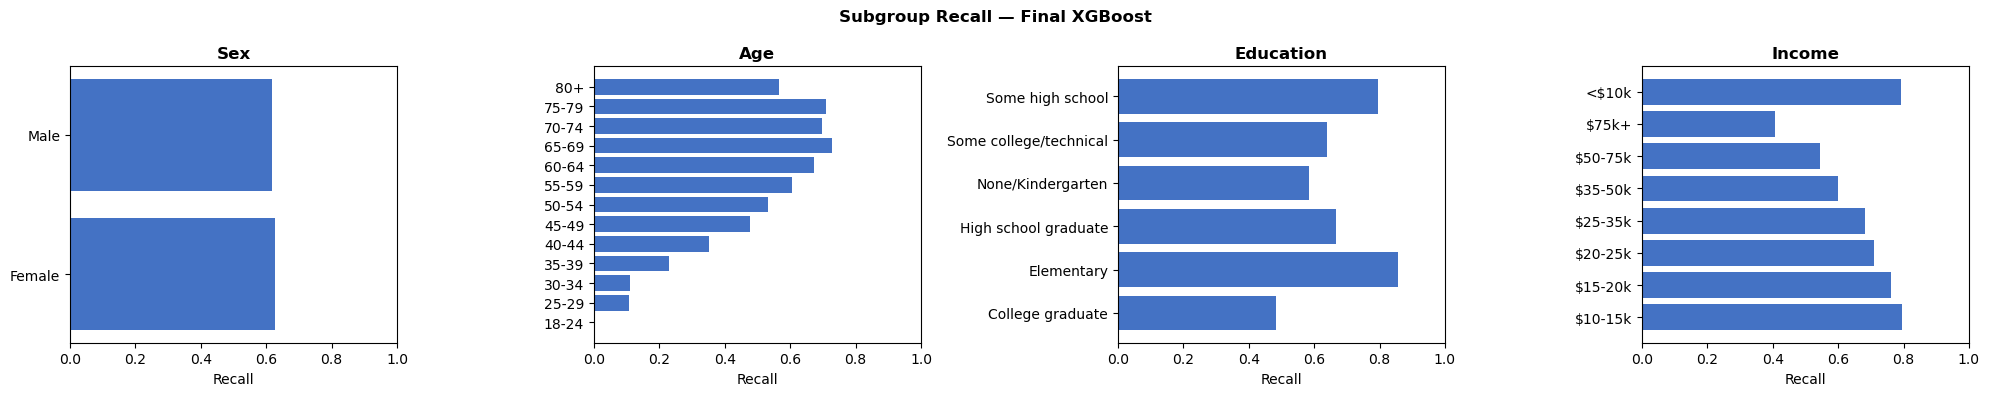


Figure B1-2: Subgroup False Positive Rate — Final XGBoost


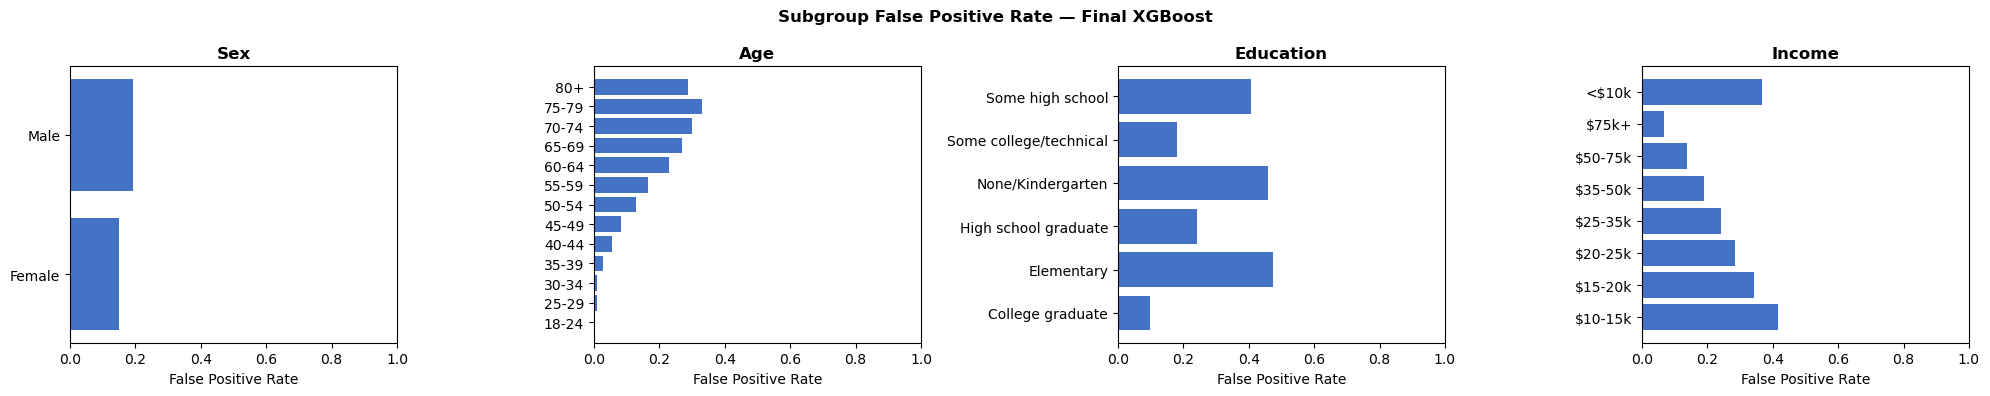

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [33]:
# ==========================================================
# Table B1-2 / Figure B1-1 / Figure B1-2 — moved from Section 13
# ==========================================================
b1_counter.table(
    f"Subgroup Recall / False-Positive-Rate / Precision — Held-Out Test Set "
    f"(threshold={OPTIMAL_THRESHOLD:.2f})"
)
print(fairness_df.to_string(index=False))

with mlflow.start_run(run_id=FINAL_RUN_ID):
    b1_counter.figure("Subgroup Recall (Sensitivity) — Final XGBoost")
    log_subgroup_fairness_plot(fairness_df, "Final XGBoost", metric="recall")

    b1_counter.figure("Subgroup False Positive Rate — Final XGBoost")
    log_subgroup_fairness_plot(fairness_df, "Final XGBoost", metric="false_positive_rate")


In [34]:
# ==========================================================
# B1 — Findings & Interpretation (data-driven root-cause + mitigation)
# ==========================================================
ROOT_CAUSE_HYPOTHESES = {
    "Sex": ("Possible proxy effects via BMI, physical-activity, or health-check-frequency features "
            "that correlate with Sex in BRFSS; could also reflect genuine differences in diabetes "
            "prevalence/presentation by sex reported in the epidemiological literature."),
    "Age": ("Older age bands have both higher diabetes prevalence and different comorbidity clustering "
            "(HighBP, HeartDiseaseorAttack) than younger bands, which the model may weight differently; "
            "smaller sample sizes at the oldest/youngest bands can also inflate the apparent gap."),
    "Education": ("Education can act as a proxy for healthcare access, health literacy, or income, any "
                  "of which may shift the feature distribution independently of true diabetes risk."),
    "Income": ("Income is a known proxy for healthcare access and preventive-care utilisation (e.g. "
              "CholCheck, AnyHealthcare), which can shift both true prevalence and the model's inputs "
              "for lower-income subgroups."),
}
MITIGATION_TEMPLATE = (
    "Recommended mitigation: (1) escalate to the project's human review process (risk register) rather "
    "than auto-adjusting the threshold; (2) check whether the gap persists after controlling for "
    "healthcare-access features (AnyHealthcare, NoDocbcCost, CholCheck); (3) consider a subgroup-aware "
    "threshold only after governance sign-off, given the fairness objective in Proposal Section IV.2.1 "
    "prioritises equal opportunity (recall) over a single global threshold."
)

flagged_summary = ai_verify_fairness_df[
    ai_verify_fairness_df[["dir_flag", "eod_flag", "eodds_flag", "fdr_gap_flag"]].any(axis=1)
]

print("=" * 100)
print("B1 FINDINGS & INTERPRETATION")
print("=" * 100)
if flagged_summary.empty:
    print(
        "No subgroup exceeded the DIR four-fifths rule, the Equal Opportunity Difference threshold "
        f"(|gap| >= {EO_DIFFERENCE_THRESHOLD}), the Equalized Odds Difference threshold, or the FDR-gap "
        "threshold among subgroups with sufficient sample. For a screening tool this is a reassuring "
        "result, but fairness is not a one-time certification — this check should be re-run whenever "
        "the model, threshold, or DATA_PROFILE changes (e.g. moving to \"full\")."
    )
else:
    for attribute in flagged_summary["attribute"].unique():
        attr_rows = flagged_summary[flagged_summary["attribute"] == attribute]
        print(f"\n--- {attribute} ---")
        print(attr_rows[[
            "group", "disparate_impact_ratio", "equal_opportunity_difference",
            "equalized_odds_difference", "fdr_gap",
        ]].to_string(index=False))
        print("Hypothesis:", ROOT_CAUSE_HYPOTHESES.get(attribute, "Not yet characterised for this attribute."))
        print(MITIGATION_TEMPLATE)


B1 FINDINGS & INTERPRETATION

--- Age ---
group  disparate_impact_ratio  equal_opportunity_difference  equalized_odds_difference  fdr_gap
18-24                   0.006                        -0.671                      0.671    0.423
25-29                   0.041                        -0.565                      0.565    0.185
30-34                   0.041                        -0.560                      0.560    0.137
35-39                   0.122                        -0.441                      0.441    0.127
40-44                   0.240                        -0.319                      0.319    0.085
45-49                   0.391                        -0.195                      0.195    0.019
50-54                   0.578                        -0.139                      0.139    0.032
55-59                   0.732                        -0.066                      0.066    0.018
75-79                   1.334                         0.037                      0.101    0.00

### B1 Findings & Interpretation — why fairness gaps matter for a screening tool

A flagged gap in **Equal Opportunity Difference** is the most consequential of the four metrics for
this application: it means the model catches at-risk people at a materially different rate depending
on group membership, which directly compounds healthcare-access disparities that already exist
independent of the model. A flagged **Disparate Impact Ratio** matters slightly differently — it
reflects who gets flagged at all, which drives real-world load on downstream confirmatory testing
capacity rather than diagnostic accuracy per group. A flagged **Equalized Odds** or **FDR gap** points
to a difference in how *trustworthy* a positive or negative result is across groups, which affects how
much a clinician or user should weight the tool's output for that group.

None of these flags are, by themselves, grounds to reject the model — per the risk register, they are
triggers for **human review**: investigate the likely cause (proxy features, true prevalence
differences, or small-sample noise), decide whether it is acceptable, mitigable, or disqualifying, and
record that decision. Silently suppressing a flag, or auto-adjusting the threshold per subgroup without
governance sign-off, would itself be a governance failure.


## Appendix B2 — Explainability Testing

Builds on the SHAP computation already performed in Section 12 (`explainer`, `shap_values_positive`,
`X_shap_sample`, `mean_abs_shap`). Presents the global/local SHAP visuals produced there, then adds
three checks not previously performed:

1. **Explanation stability** — do the top feature-importance rankings hold up across different random
   test subsamples, or are they a one-off artifact of the particular 500-row sample drawn?
2. **Explanation face-validity** — for the specific representative false-negative, false-positive, and
   borderline cases already identified in Section 11.2–11.3, do the local SHAP drivers make clinical
   sense?
3. **XGBoost vs Logistic Regression driver agreement** — do the two model families agree on what
   matters most, using the LR baseline already loaded and evaluated in Section 14?



Figure B2-1: SHAP Summary (Beeswarm) — Final XGBoost


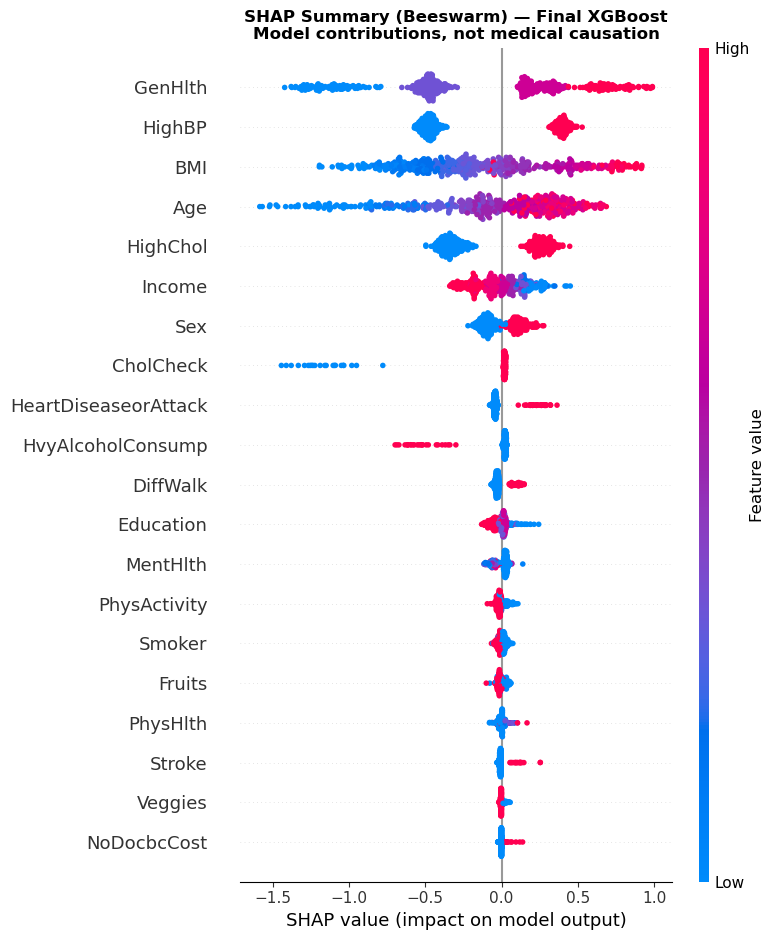


Figure B2-2: Mean |SHAP value| (top 15) — Final XGBoost


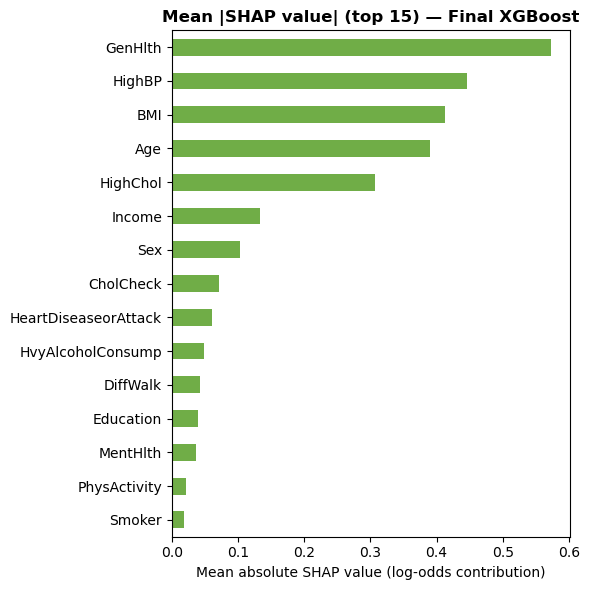


Table B2-1: Mean |SHAP| Feature Importance (top 15) — Final XGBoost
                      mean_abs_shap
GenHlth                    0.572336
HighBP                     0.446461
BMI                        0.412694
Age                        0.390558
HighChol                   0.306313
Income                     0.132471
Sex                        0.102779
CholCheck                  0.070958
HeartDiseaseorAttack       0.060694
HvyAlcoholConsump          0.048987
DiffWalk                   0.042301
Education                  0.039099
MentHlth                   0.036527
PhysActivity               0.021901
Smoker                     0.019019
🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [35]:
# ==========================================================
# Figure B2-1 / Figure B2-2 / Table B2-1 — moved from Section 12
# (global SHAP: beeswarm, mean-|SHAP| bar, and top-15 importance table)
# ==========================================================
with mlflow.start_run(run_id=FINAL_RUN_ID):
    b2_counter.figure("SHAP Summary (Beeswarm) — Final XGBoost")
    fig = plt.figure(figsize=(8, 7))
    shap.summary_plot(shap_values_positive, X_shap_sample, show=False)
    plt.title("SHAP Summary (Beeswarm) — Final XGBoost\nModel contributions, not medical causation",
              fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/shap_summary_beeswarm.png"
        plt.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="explainability")
    plt.show()
    plt.close()

    b2_counter.figure("Mean |SHAP value| (top 15) — Final XGBoost")
    fig, ax = plt.subplots(figsize=(6, 6))
    mean_abs_shap.tail(15).plot(kind="barh", ax=ax, color="#70AD47")
    ax.set_title("Mean |SHAP value| (top 15) — Final XGBoost", fontweight="bold")
    ax.set_xlabel("Mean absolute SHAP value (log-odds contribution)")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/shap_mean_abs_bar.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="explainability")
    plt.show()
    plt.close()

    b2_counter.table("Mean |SHAP| Feature Importance (top 15) — Final XGBoost")
    table_b2_1 = mean_abs_shap.sort_values(ascending=False).head(15).rename("mean_abs_shap").to_frame()
    print(table_b2_1.to_string())

    with tempfile.TemporaryDirectory() as tmp:
        csv_path = f"{tmp}/shap_mean_abs_importance.csv"
        mean_abs_shap.sort_values(ascending=False).to_csv(csv_path, header=["mean_abs_shap"])
        mlflow.log_artifact(csv_path, artifact_path="explainability")



Figure B2-3: SHAP Local Explanation — True Positive (sampled test case, model contribution not a diagnosis)


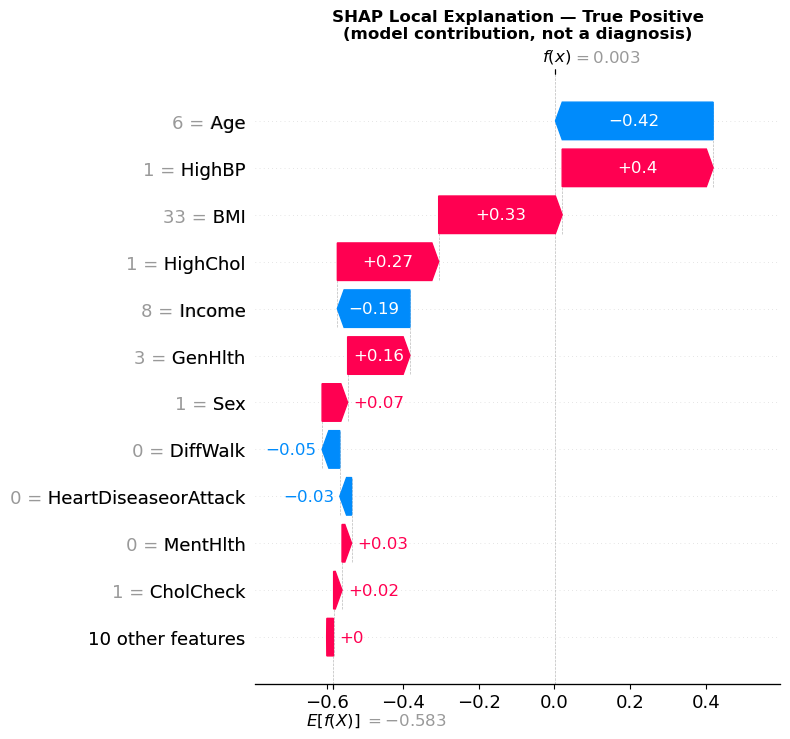


Figure B2-4: SHAP Local Explanation — False Negative (sampled test case, model contribution not a diagnosis)


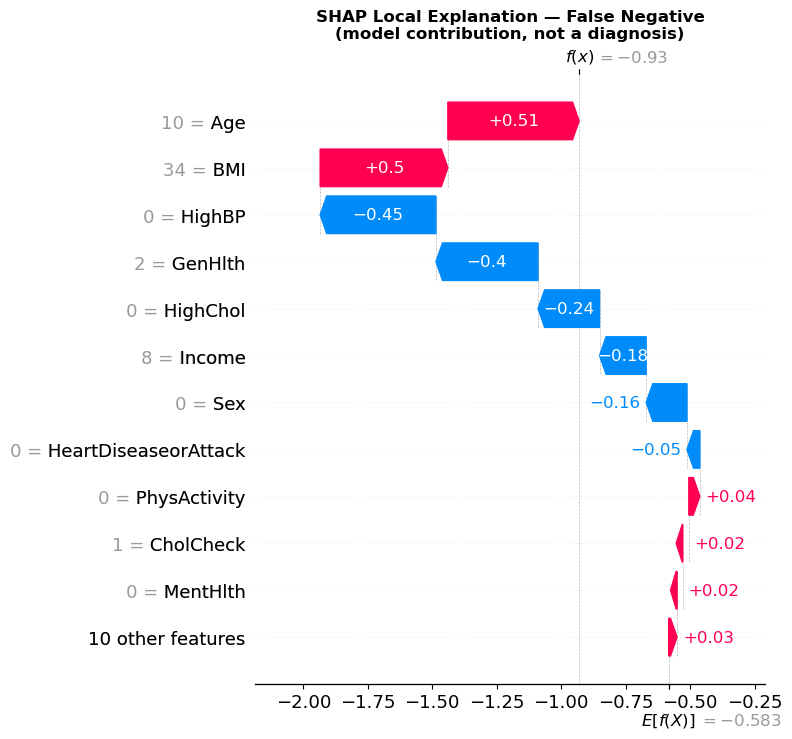

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [36]:
# ==========================================================
# Figure B2-3 / Figure B2-4 — moved from Section 12
# (local SHAP waterfalls: one correctly-flagged positive, one false negative)
# ==========================================================
with mlflow.start_run(run_id=FINAL_RUN_ID):
    for label, row_idx in local_examples.items():
        b2_counter.figure(
            f"SHAP Local Explanation — {label.replace(chr(95), chr(32)).title()} "
            "(sampled test case, model contribution not a diagnosis)"
        )
        fig = plt.figure(figsize=(8, 5))
        explanation = shap.Explanation(
            values=shap_values_positive[row_idx],
            base_values=explainer.expected_value
            if isinstance(explainer.expected_value, (int, float, np.floating))
            else explainer.expected_value[1],
            data=X_shap_sample.iloc[row_idx],
            feature_names=X_shap_sample.columns.tolist(),
        )
        shap.plots.waterfall(explanation, show=False, max_display=12)
        plt.title(f"SHAP Local Explanation — {label.replace(chr(95), chr(32)).title()}\n"
                  f"(model contribution, not a diagnosis)", fontweight="bold")
        plt.tight_layout()
        with tempfile.TemporaryDirectory() as tmp:
            path = f"{tmp}/shap_local_{label}.png"
            plt.savefig(path, dpi=120, bbox_inches="tight")
            mlflow.log_artifact(path, artifact_path="explainability")
        plt.show()
        plt.close()


In [37]:
# ==========================================================
# Table B2-2 — NEW: Explanation STABILITY check
# ==========================================================
from scipy.stats import spearmanr

STABILITY_SUBSAMPLE_SIZE = min(300, X_test.shape[0])
STABILITY_TOP_N = 10

stability_positions_a = X_test.sample(n=STABILITY_SUBSAMPLE_SIZE, random_state=RANDOM_STATE + 101).index
stability_positions_b = X_test.sample(n=STABILITY_SUBSAMPLE_SIZE, random_state=RANDOM_STATE + 202).index

X_stability_a = X_test.loc[stability_positions_a]
X_stability_b = X_test.loc[stability_positions_b]

shap_values_stab_a = explainer.shap_values(X_stability_a)
shap_values_stab_b = explainer.shap_values(X_stability_b)
shap_values_stab_a = shap_values_stab_a[1] if isinstance(shap_values_stab_a, list) else shap_values_stab_a
shap_values_stab_b = shap_values_stab_b[1] if isinstance(shap_values_stab_b, list) else shap_values_stab_b

mean_abs_a = pd.Series(np.abs(shap_values_stab_a).mean(axis=0), index=X_stability_a.columns)
mean_abs_b = pd.Series(np.abs(shap_values_stab_b).mean(axis=0), index=X_stability_b.columns)

rank_a = mean_abs_a.rank(ascending=False)
rank_b = mean_abs_b.rank(ascending=False)

top_features_union = sorted(
    set(mean_abs_a.sort_values(ascending=False).head(STABILITY_TOP_N).index)
    | set(mean_abs_b.sort_values(ascending=False).head(STABILITY_TOP_N).index)
)

rho, p_value = spearmanr(rank_a.reindex(X_test.columns), rank_b.reindex(X_test.columns))

table_b2_2 = pd.DataFrame({
    "feature": top_features_union,
    "rank_subsample_A": [int(rank_a[f]) for f in top_features_union],
    "rank_subsample_B": [int(rank_b[f]) for f in top_features_union],
    "mean_abs_shap_A": [round(float(mean_abs_a[f]), 4) for f in top_features_union],
    "mean_abs_shap_B": [round(float(mean_abs_b[f]), 4) for f in top_features_union],
}).sort_values("rank_subsample_A")

b2_counter.table(
    f"SHAP Feature-Importance Rank Comparison — Subsample A (n={STABILITY_SUBSAMPLE_SIZE}) vs "
    f"Subsample B (n={STABILITY_SUBSAMPLE_SIZE}), independently drawn from the held-out test set"
)
print(table_b2_2.to_string(index=False))

STABILITY_RHO_THRESHOLD = 0.80
print(f"\nSpearman rank correlation across all {X_test.shape[1]} features: "
      f"rho = {rho:.3f} (p = {p_value:.4f})")
if rho >= STABILITY_RHO_THRESHOLD:
    print(
        f"PASS: rho >= {STABILITY_RHO_THRESHOLD} — the feature-importance ranking is stable across "
        "independent test subsamples. The SHAP explanation is not a one-off artifact of a particular "
        "sample and can reasonably be used for governance/reporting purposes."
    )
else:
    print(
        f"REVIEW: rho < {STABILITY_RHO_THRESHOLD} — the feature-importance ranking shows meaningful "
        "sensitivity to which test rows were sampled. Recommend increasing SHAP_SAMPLE_SIZE (Section 12) "
        "before treating any single feature-importance ranking as authoritative for governance reporting."
    )

with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_metric("appendix_b2_shap_stability_spearman_rho", round(float(rho), 4))
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b2_shap_stability_rank_comparison.csv"
        table_b2_2.to_csv(path, index=False)
        mlflow.log_artifact(path, artifact_path="explainability")



Table B2-2: SHAP Feature-Importance Rank Comparison — Subsample A (n=300) vs Subsample B (n=300), independently drawn from the held-out test set
             feature  rank_subsample_A  rank_subsample_B  mean_abs_shap_A  mean_abs_shap_B
             GenHlth                 1                 1           0.5841           0.5855
              HighBP                 2                 2           0.4453           0.4463
                 BMI                 3                 3           0.4005           0.3865
                 Age                 4                 4           0.3879           0.3571
            HighChol                 5                 5           0.3058           0.3000
              Income                 6                 6           0.1407           0.1335
                 Sex                 7                 7           0.1044           0.1053
HeartDiseaseorAttack                 8                 9           0.0601           0.0590
   HvyAlcoholConsump               


Figure B2-5: SHAP Local Explanation — Representative False Negative (actual=1, predicted=0, proba=0.006)


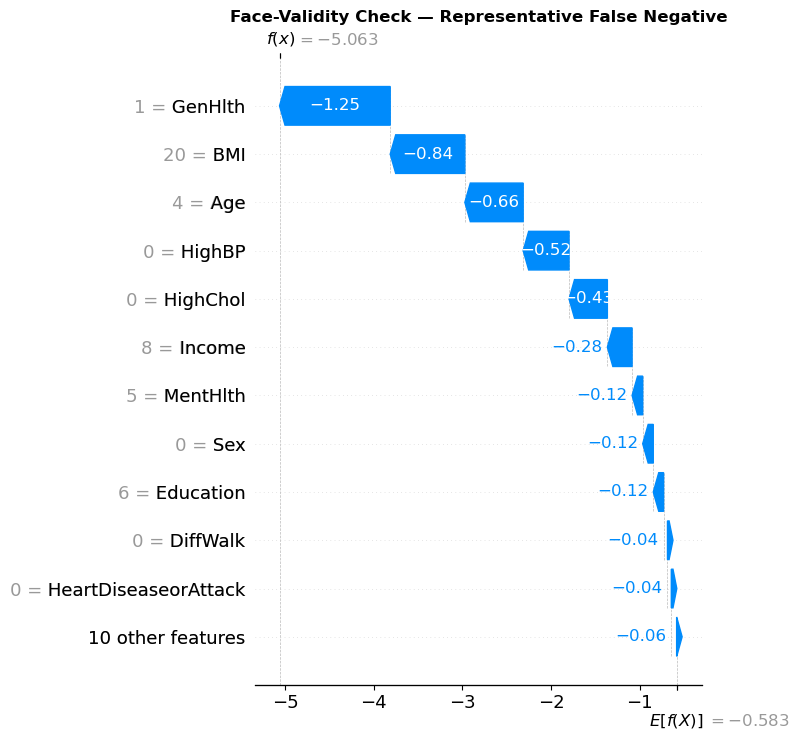

Top 3 SHAP drivers for Representative False Negative:
  - GenHlth = 1.0 (decreases predicted risk): a broad self-rated-health proxy that can reflect undiagnosed symptoms, though it is non-specific.
  - BMI = 20.0 (decreases predicted risk): obesity is one of the strongest established risk factors for type 2 diabetes - clinically plausible driver.
  - Age = 4.0 (decreases predicted risk): diabetes prevalence rises materially with age - clinically plausible driver.


Figure B2-6: SHAP Local Explanation — Representative False Positive (actual=0, predicted=1, proba=0.923)


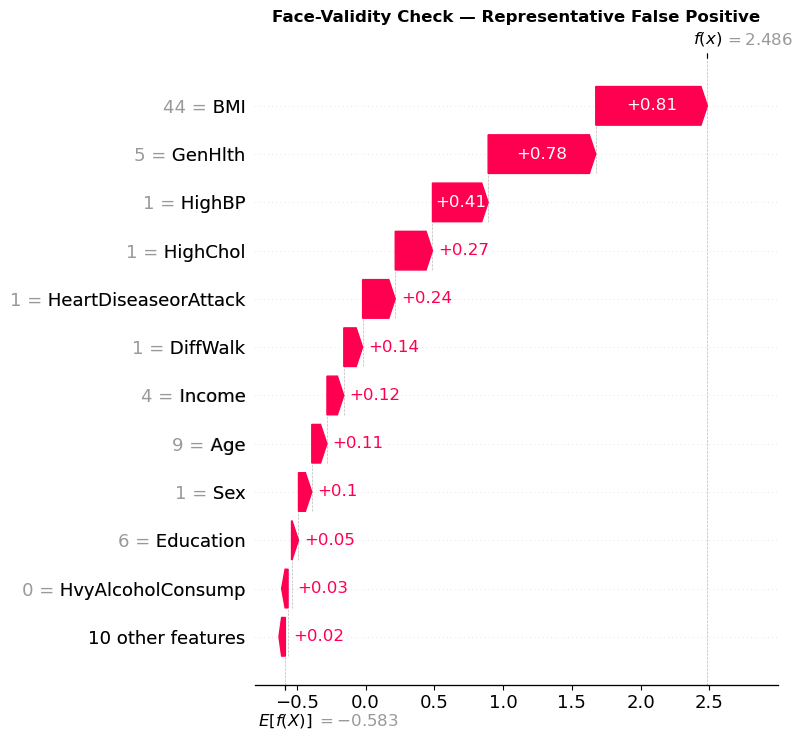

Top 3 SHAP drivers for Representative False Positive:
  - BMI = 44.0 (increases predicted risk): obesity is one of the strongest established risk factors for type 2 diabetes - clinically plausible driver.
  - GenHlth = 5.0 (increases predicted risk): a broad self-rated-health proxy that can reflect undiagnosed symptoms, though it is non-specific.
  - HighBP = 1.0 (increases predicted risk): an established diabetes risk factor (insulin resistance commonly co-occurs with hypertension) - clinically plausible driver.


Figure B2-7: SHAP Local Explanation — Borderline Case (at-risk side) (actual=1, predicted=1, proba=0.500)


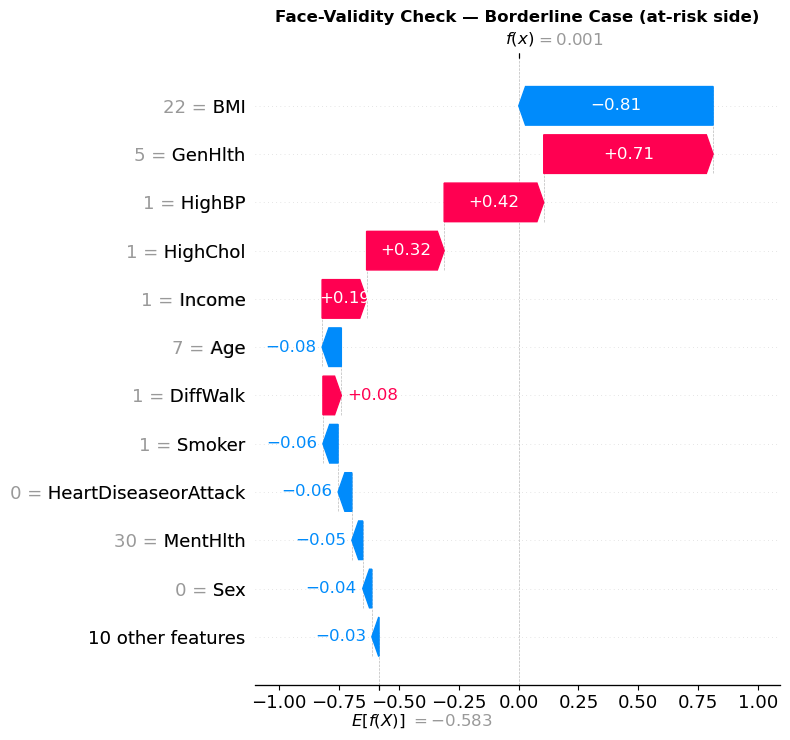

Top 3 SHAP drivers for Borderline Case (at-risk side):
  - BMI = 22.0 (decreases predicted risk): obesity is one of the strongest established risk factors for type 2 diabetes - clinically plausible driver.
  - GenHlth = 5.0 (increases predicted risk): a broad self-rated-health proxy that can reflect undiagnosed symptoms, though it is non-specific.
  - HighBP = 1.0 (increases predicted risk): an established diabetes risk factor (insulin resistance commonly co-occurs with hypertension) - clinically plausible driver.


Figure B2-8: SHAP Local Explanation — Borderline Case (healthy side) (actual=0, predicted=0, proba=0.500)


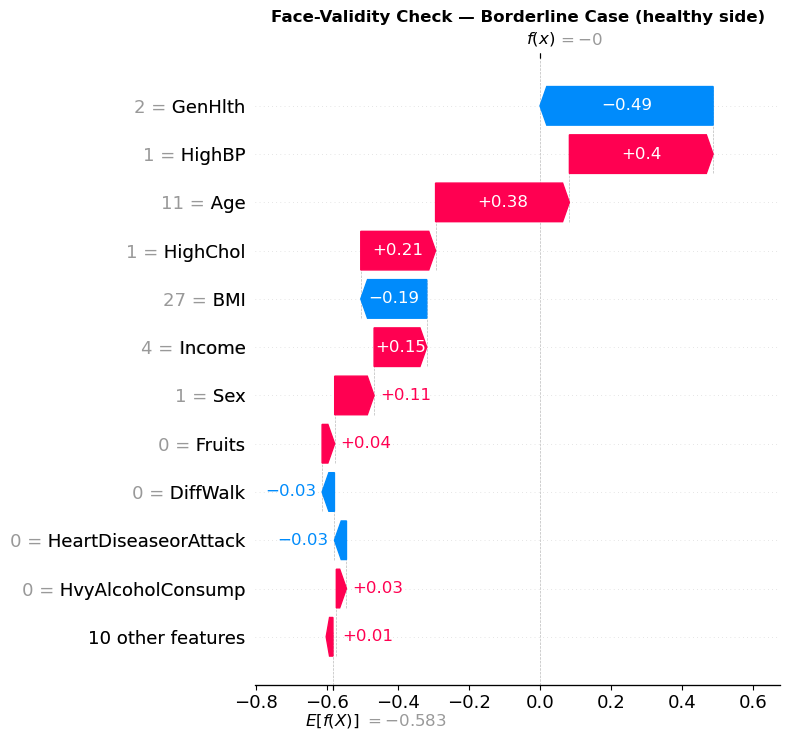

Top 3 SHAP drivers for Borderline Case (healthy side):
  - GenHlth = 2.0 (decreases predicted risk): a broad self-rated-health proxy that can reflect undiagnosed symptoms, though it is non-specific.
  - HighBP = 1.0 (increases predicted risk): an established diabetes risk factor (insulin resistance commonly co-occurs with hypertension) - clinically plausible driver.
  - Age = 11.0 (increases predicted risk): diabetes prevalence rises materially with age - clinically plausible driver.

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [38]:
# ==========================================================
# Figures B2-x — NEW: Explanation FACE-VALIDITY check
# Pulls the specific representative false-negative / false-positive / borderline
# cases already identified in Section 11.2-11.3 and explains each with SHAP.
# ==========================================================
face_validity_cases = {}

if len(most_confident_false_negatives) > 0:
    face_validity_cases["Representative False Negative"] = most_confident_false_negatives.iloc[0]
if len(most_confident_false_positives) > 0:
    face_validity_cases["Representative False Positive"] = most_confident_false_positives.iloc[0]

borderline_at_risk = borderline_cases[borderline_cases["error_type"].isin(["TP", "FN"])]
if len(borderline_at_risk) > 0:
    face_validity_cases["Borderline Case (at-risk side)"] = borderline_at_risk.iloc[0]

borderline_healthy = borderline_cases[borderline_cases["error_type"].isin(["TN", "FP"])]
if len(borderline_healthy) > 0:
    face_validity_cases["Borderline Case (healthy side)"] = borderline_healthy.iloc[0]

if not face_validity_cases:
    print("No representative FN/FP/borderline cases were available from Section 11 to face-validate "
          "(unexpected given a non-trivial test set) — skipping this check.")

with mlflow.start_run(run_id=FINAL_RUN_ID):
    for case_label, case_row in face_validity_cases.items():
        case_features = case_row[X_test.columns].to_frame().T.astype(X_test.dtypes.to_dict())
        case_shap_raw = explainer.shap_values(case_features)
        case_shap_raw = case_shap_raw[1] if isinstance(case_shap_raw, list) else case_shap_raw
        case_shap_values = case_shap_raw[0]

        b2_counter.figure(
            f"SHAP Local Explanation — {case_label} (actual={int(case_row['actual'])}, "
            f"predicted={int(case_row['predicted'])}, proba={case_row['predicted_proba']:.3f})"
        )
        fig = plt.figure(figsize=(8, 5))
        explanation = shap.Explanation(
            values=case_shap_values,
            base_values=explainer.expected_value
            if isinstance(explainer.expected_value, (int, float, np.floating))
            else explainer.expected_value[1],
            data=case_features.iloc[0],
            feature_names=X_test.columns.tolist(),
        )
        shap.plots.waterfall(explanation, show=False, max_display=12)
        plt.title(f"Face-Validity Check — {case_label}", fontweight="bold")
        plt.tight_layout()
        safe_name = case_label.lower().replace(" ", "_").replace("(", "").replace(")", "")
        with tempfile.TemporaryDirectory() as tmp:
            path = f"{tmp}/appendix_b2_face_validity_{safe_name}.png"
            plt.savefig(path, dpi=120, bbox_inches="tight")
            mlflow.log_artifact(path, artifact_path="explainability")
        plt.show()
        plt.close()

        case_shap_series = pd.Series(case_shap_values, index=X_test.columns)
        top_drivers = case_shap_series.abs().sort_values(ascending=False).head(3)
        print(f"Top 3 SHAP drivers for {case_label}:")
        for feat in top_drivers.index:
            direction = "increases" if case_shap_series[feat] > 0 else "decreases"
            value = case_row[feat]
            note = CLINICAL_PLAUSIBILITY_NOTES.get(feat, "not in the reference note list - assess case-by-case.")
            print(f"  - {feat} = {value} ({direction} predicted risk): {note}")
        print()


In [39]:
# ==========================================================
# Table B2-3 — NEW: XGBoost SHAP vs Logistic Regression coefficient comparison
# Reuses `lr_model` / `LR_COMPARISON_AVAILABLE` from Section 14.
# ==========================================================
lr_coefs = None
if LR_COMPARISON_AVAILABLE and lr_model is not None:
    lr_coefs = extract_lr_coefficients(lr_model, X_test.columns)

if lr_coefs is not None:
    TOP_N_COMPARE = 10
    xgb_importance = mean_abs_shap.sort_values(ascending=False)
    lr_importance = lr_coefs.abs().sort_values(ascending=False)

    xgb_rank = xgb_importance.rank(ascending=False)
    lr_rank = lr_importance.rank(ascending=False)

    compare_features = sorted(
        set(xgb_importance.head(TOP_N_COMPARE).index) | set(lr_importance.head(TOP_N_COMPARE).index)
    )

    table_b2_3 = pd.DataFrame({
        "feature": compare_features,
        "xgb_mean_abs_shap": [round(float(xgb_importance.get(f, 0.0)), 4) for f in compare_features],
        "xgb_rank": [int(xgb_rank[f]) if f in xgb_rank.index else None for f in compare_features],
        "lr_abs_coefficient": [round(float(lr_importance.get(f, 0.0)), 4) for f in compare_features],
        "lr_coefficient_sign": [
            "+" if lr_coefs.get(f, 0) > 0 else ("-" if lr_coefs.get(f, 0) < 0 else "0")
            for f in compare_features
        ],
        "lr_rank": [int(lr_rank[f]) if f in lr_rank.index else None for f in compare_features],
    }).sort_values("xgb_rank")

    b2_counter.table(
        f"XGBoost SHAP Importance vs Logistic-Regression Coefficient Magnitude "
        f"— top {TOP_N_COMPARE} each, union shown"
    )
    print(table_b2_3.to_string(index=False))

    top5_agreement = len(set(xgb_importance.head(5).index) & set(lr_importance.head(5).index))
    print(f"\n{top5_agreement} of the top 5 XGBoost SHAP drivers also appear in Logistic Regression's "
          "top 5 (by absolute coefficient magnitude).")
    if top5_agreement >= 3:
        print(
            "The two model families broadly AGREE on the dominant risk drivers, which increases "
            "confidence that the explanation reflects genuine signal in the data rather than an "
            "XGBoost-specific artifact (e.g. an interaction the tree model happens to exploit)."
        )
    else:
        print(
            "The two model families show LIMITED agreement on dominant drivers. This is not necessarily "
            "a problem — XGBoost can capture non-linear/interaction effects a linear LR coefficient "
            "cannot represent — but it means the champion-decision discussion (Section 15) should not "
            "lean on 'the drivers make more sense' as a tie-breaker without first investigating why the "
            "two models disagree."
        )

    with mlflow.start_run(run_id=FINAL_RUN_ID):
        with tempfile.TemporaryDirectory() as tmp:
            path = f"{tmp}/appendix_b2_xgb_vs_lr_driver_comparison.csv"
            table_b2_3.to_csv(path, index=False)
            mlflow.log_artifact(path, artifact_path="explainability")
        mlflow.log_metric("appendix_b2_xgb_lr_top5_driver_agreement", int(top5_agreement))
else:
    print(
        "XGBoost-vs-LR driver comparison skipped: no LR coefficients could be extracted "
        "(either LR_COMPARISON_AVAILABLE is False in Section 14, or the loaded LR model object's "
        "structure was not recognised by extract_lr_coefficients). This does not affect any other "
        "result in this notebook."
    )



Table B2-3: XGBoost SHAP Importance vs Logistic-Regression Coefficient Magnitude — top 10 each, union shown
             feature  xgb_mean_abs_shap  xgb_rank  lr_abs_coefficient lr_coefficient_sign  lr_rank
             GenHlth             0.5723         1              0.5527                   +        5
              HighBP             0.4465         2              0.6810                   +        2
                 BMI             0.4127         3              0.0737                   +       11
                 Age             0.3906         4              0.1516                   +        8
            HighChol             0.3063         5              0.5938                   +        4
              Income             0.1325         6              0.0621                   -       13
                 Sex             0.1028         7              0.2517                   +        6
           CholCheck             0.0710         8              1.2358                   +        1


### B2 Findings & Interpretation — why explainability quality matters for a screening tool

A SHAP explanation is only useful to a clinician, a governance reviewer, or an end user if it is
**stable** and **face-valid**. The stability check above answers *"would I get roughly the same
explanation if I ran this on a different sample of patients?"* — a low rank correlation would mean
any single feature-importance chart risks over-stating confidence in a ranking that is partly sampling
noise, which matters directly for the AI Risk and Impact Assessment's requirement that explanations be
described as *model contributions*, not settled facts.

The face-validity check is the more clinically important one: it asks whether the *specific* drivers
behind a specific person's borderline or wrong prediction make sense to a domain reviewer. Where the
top drivers are established risk factors (BMI, HighBP, HighChol, Age), the explanation supports the
non-causal framing already required in Section 12 — the model is picking up recognised risk signal,
even when it gets the case wrong. Where the top drivers lean on non-physiological proxies (Income,
Education), that is itself a governance-relevant observation: it is consistent with the fairness gaps
investigated in Appendix B1, and is a reason to treat a positive/negative flag for that individual with
more caution rather than as a settled result.

The XGBoost-vs-LR comparison is a secondary corroboration check, not a champion-selection criterion —
disagreement between a tree ensemble and a linear model on driver ranking is expected when true
interaction effects exist, and should not by itself be read as evidence that either model's
explanation is wrong.


## Appendix B3 — Robustness Testing

New in this appendix (robustness was not previously tested in this notebook). Three checks, chosen
for relevance to a real screening deployment built on **self-reported BRFSS survey data**:

1. **Perturbation robustness** — continuous features (`BMI`, `MentHlth`, `PhysHlth`) carry real
   self-report measurement error; small input noise should not flip predictions for most people.
2. **Missing-value robustness** — a real intake form will sometimes have an unanswered field; imputing
   one key feature at a time and measuring the prediction impact approximates that scenario.
3. **Determinism / near-duplicate consistency** — identical inputs must give identical outputs
   (auditability), and near-identical inputs should not produce discontinuous output jumps (user
   trust), particularly for the borderline-band cases already identified in Section 11.3.



Table B3-1: Perturbation Robustness Summary — Gaussian noise (std=7.5%) on ['BMI', 'MentHlth', 'PhysHlth']
features_perturbed              BMI, MentHlth, PhysHlth
noise_std_pct                                     0.075
n_test_rows                                       50736
prediction_flip_rate                             0.0352
mean_abs_probability_shift                       0.0226
median_abs_probability_shift                     0.0103
max_abs_probability_shift                        0.3424

Flip rate by original Section 11 error type:
error_type
TN    0.0133
FP    0.1202
FN    0.0403
TP    0.0650

Figure B3-1: Distribution of Absolute Probability Shift Under Feature Perturbation


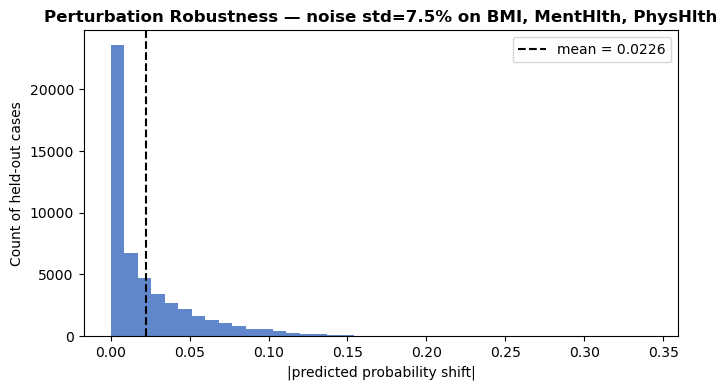

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [40]:
# ==========================================================
# Table B3-1 / Figure B3-1 — Perturbation robustness
# ==========================================================
np.random.seed(RANDOM_STATE)

PERTURBATION_FEATURES = [c for c in ["BMI", "MentHlth", "PhysHlth"] if c in X_test.columns]
PERTURBATION_PCT = 0.075  # +/-7.5%, midpoint of the requested 5-10% range

X_perturbed = X_test.copy()
for col in PERTURBATION_FEATURES:
    noise = np.random.normal(loc=0.0, scale=PERTURBATION_PCT, size=len(X_perturbed))
    X_perturbed[col] = (X_perturbed[col] * (1 + noise)).clip(lower=0)
    if col in ("MentHlth", "PhysHlth"):  # BRFSS caps these at 30 self-reported days
        X_perturbed[col] = X_perturbed[col].clip(upper=30)

base_pred, base_proba = predict_with_threshold(selected_model, X_test, threshold=OPTIMAL_THRESHOLD)
pert_pred, pert_proba = predict_with_threshold(selected_model, X_perturbed, threshold=OPTIMAL_THRESHOLD)

proba_shift = np.abs(pert_proba - base_proba)
flip_mask = base_pred != pert_pred
flip_rate = float(flip_mask.mean())

perturbation_summary = pd.Series({
    "features_perturbed": ", ".join(PERTURBATION_FEATURES),
    "noise_std_pct": PERTURBATION_PCT,
    "n_test_rows": len(X_test),
    "prediction_flip_rate": round(flip_rate, 4),
    "mean_abs_probability_shift": round(float(proba_shift.mean()), 4),
    "median_abs_probability_shift": round(float(np.median(proba_shift)), 4),
    "max_abs_probability_shift": round(float(proba_shift.max()), 4),
})

b3_counter.table(f"Perturbation Robustness Summary — Gaussian noise (std={PERTURBATION_PCT:.1%}) on {PERTURBATION_FEATURES}")
print(perturbation_summary.to_string())

# Flip rate broken down by original Section-11 error type — do perturbations
# destabilise already-wrong predictions more than already-correct ones?
flip_by_error_type = (
    pd.Series(flip_mask, index=X_test.index, name="flipped")
    .to_frame()
    .join(error_results["error_type"])
    .groupby("error_type")["flipped"]
    .mean()
    .round(4)
    .reindex(["TN", "FP", "FN", "TP"])
)
print("\nFlip rate by original Section 11 error type:")
print(flip_by_error_type.to_string())

with mlflow.start_run(run_id=FINAL_RUN_ID):
    b3_counter.figure("Distribution of Absolute Probability Shift Under Feature Perturbation")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(proba_shift, bins=40, color="#4472C4", alpha=0.85)
    ax.axvline(proba_shift.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean = {proba_shift.mean():.4f}")
    ax.set_xlabel("|predicted probability shift|")
    ax.set_ylabel("Count of held-out cases")
    ax.set_title(f"Perturbation Robustness — noise std={PERTURBATION_PCT:.1%} on "
                 f"{', '.join(PERTURBATION_FEATURES)}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b3_perturbation_shift_histogram.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="robustness")
    plt.show()
    plt.close()

    mlflow.log_metric("appendix_b3_perturbation_flip_rate", round(flip_rate, 4))
    mlflow.log_metric("appendix_b3_perturbation_mean_abs_shift", round(float(proba_shift.mean()), 4))
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b3_perturbation_summary.csv"
        perturbation_summary.to_csv(path, header=["value"])
        mlflow.log_artifact(path, artifact_path="robustness")



Table B3-2: Missing-Value Robustness — one key feature imputed at a time (median/mode)
feature_set_to_missing impute_method  imputed_value  prediction_flip_rate  mean_abs_probability_shift  max_abs_probability_shift
               GenHlth        median            2.0                0.1219                      0.0792                     0.4945
                   BMI        median           27.0                0.0981                      0.0625                     0.4132
                HighBP          mode            0.0                0.0884                      0.0505                     0.3655
              HighChol          mode            0.0                0.0630                      0.0398                     0.3085
                   Age        median            8.0                0.0570                      0.0532                     0.5077
                Income        median            7.0                0.0268                      0.0199                     0.2264
         

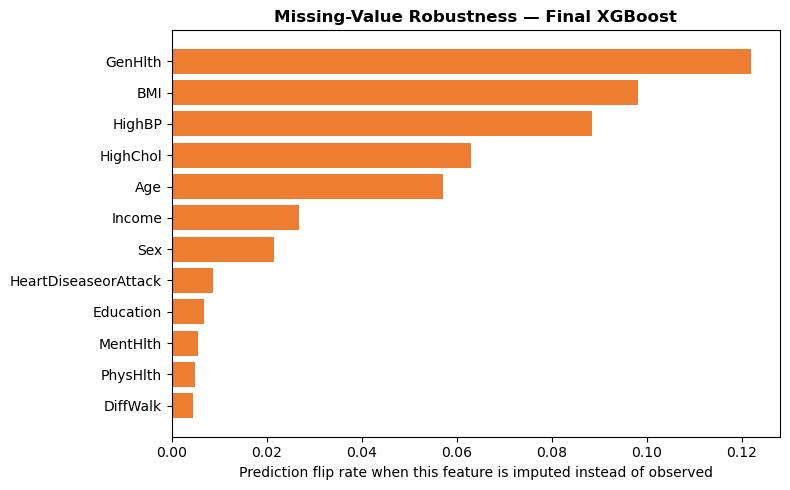

🏃 View run team02_s202_final_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/057bb58d81564c0db9a628b224eab8f9
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


In [41]:
# ==========================================================
# Table B3-2 / Figure B3-2 — Missing-value robustness
# Simulates one missing key feature at a time (median/mode imputation) and
# measures the prediction impact vs the true (fully-observed) baseline.
# ==========================================================
MISSING_TEST_FEATURES = KEY_CLINICAL_FEATURES  # reuse the list defined in Section 11.2

missing_value_records = []
for col in MISSING_TEST_FEATURES:
    if X_train[col].nunique() <= 2:
        fill_value = float(X_train[col].mode().iloc[0])
        impute_method = "mode"
    else:
        fill_value = float(X_train[col].median())
        impute_method = "median"

    X_missing = X_test.copy()
    X_missing[col] = fill_value

    miss_pred, miss_proba = predict_with_threshold(selected_model, X_missing, threshold=OPTIMAL_THRESHOLD)
    shift = np.abs(miss_proba - base_proba)

    missing_value_records.append({
        "feature_set_to_missing": col,
        "impute_method": impute_method,
        "imputed_value": round(fill_value, 2),
        "prediction_flip_rate": round(float((base_pred != miss_pred).mean()), 4),
        "mean_abs_probability_shift": round(float(shift.mean()), 4),
        "max_abs_probability_shift": round(float(shift.max()), 4),
    })

missing_value_df = pd.DataFrame(missing_value_records).sort_values(
    "prediction_flip_rate", ascending=False
).reset_index(drop=True)

b3_counter.table("Missing-Value Robustness — one key feature imputed at a time (median/mode)")
print(missing_value_df.to_string(index=False))

most_sensitive_feature = missing_value_df.iloc[0]["feature_set_to_missing"]
most_sensitive_flip_rate = missing_value_df.iloc[0]["prediction_flip_rate"]
print(
    f"\nMost sensitive to being missing: '{most_sensitive_feature}' "
    f"(flip rate {most_sensitive_flip_rate:.1%} when imputed). This is a candidate for a "
    "required/mandatory field in any intake form built on this model, rather than a field the "
    "UI allows a user to skip."
)

with mlflow.start_run(run_id=FINAL_RUN_ID):
    b3_counter.figure("Prediction Flip Rate by Feature When Simulated Missing (Median/Mode Imputed)")
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = missing_value_df.sort_values("prediction_flip_rate")
    ax.barh(plot_df["feature_set_to_missing"], plot_df["prediction_flip_rate"], color="#ED7D31")
    ax.set_xlabel("Prediction flip rate when this feature is imputed instead of observed")
    ax.set_title("Missing-Value Robustness — Final XGBoost", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b3_missing_value_flip_rates.png"
        fig.savefig(path, dpi=120, bbox_inches="tight")
        mlflow.log_artifact(path, artifact_path="robustness")
    plt.show()
    plt.close()

    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b3_missing_value_robustness.csv"
        missing_value_df.to_csv(path, index=False)
        mlflow.log_artifact(path, artifact_path="robustness")
    mlflow.log_metric("appendix_b3_missing_value_max_flip_rate", float(missing_value_df["prediction_flip_rate"].max()))


In [42]:
# ==========================================================
# Table B3-3 — Determinism / near-duplicate consistency check
# ==========================================================
pred_run1, proba_run1 = predict_with_threshold(selected_model, X_test, threshold=OPTIMAL_THRESHOLD)
pred_run2, proba_run2 = predict_with_threshold(selected_model, X_test, threshold=OPTIMAL_THRESHOLD)

identical_predictions = bool(np.array_equal(pred_run1, pred_run2))
identical_probabilities = bool(np.allclose(proba_run1, proba_run2, atol=1e-12))

# Near-duplicate discontinuity check: a tiny (0.1%) input perturbation should not
# cause a disproportionately large probability jump, especially for cases already
# sitting in the Section 11.3 borderline band.
TINY_NOISE_PCT = 0.001
tiny_noise = np.random.normal(0.0, TINY_NOISE_PCT, size=len(X_test))
X_tiny = X_test.copy()
for col in PERTURBATION_FEATURES:
    X_tiny[col] = X_test[col] * (1 + tiny_noise)

_, tiny_proba = predict_with_threshold(selected_model, X_tiny, threshold=OPTIMAL_THRESHOLD)
tiny_shift = np.abs(tiny_proba - base_proba)

DISCONTINUITY_CONCERN_THRESHOLD = 0.05
n_discontinuous = int((tiny_shift >= DISCONTINUITY_CONCERN_THRESHOLD).sum())

determinism_summary = pd.Series({
    "identical_predictions_across_two_runs": identical_predictions,
    "identical_probabilities_across_two_runs": identical_probabilities,
    "tiny_perturbation_pct": TINY_NOISE_PCT,
    "tiny_perturbation_mean_abs_shift": round(float(tiny_shift.mean()), 6),
    "tiny_perturbation_max_abs_shift": round(float(tiny_shift.max()), 6),
    "discontinuity_concern_threshold": DISCONTINUITY_CONCERN_THRESHOLD,
    "n_rows_exceeding_discontinuity_threshold": n_discontinuous,
    "pct_rows_exceeding_discontinuity_threshold": round(n_discontinuous / len(X_test), 4),
})

b3_counter.table("Determinism and Near-Duplicate Consistency Check")
print(determinism_summary.to_string())

if identical_predictions and identical_probabilities:
    print(
        "\nPASS: identical inputs produced bit-identical predictions and probabilities across two "
        "independent calls — the model is deterministic at inference time, which is required for "
        "auditability (the same case should always get the same result when nothing has changed)."
    )
else:
    print(
        "\nREVIEW: two calls with identical inputs did not produce identical output. Investigate "
        "possible sources of non-determinism (e.g. multi-threaded XGBoost prediction with "
        "n_jobs != 1, or GPU non-determinism) before this model is used in an auditable production "
        "setting."
    )

if n_discontinuous == 0:
    print(
        f"\nNo held-out case showed a probability jump >= {DISCONTINUITY_CONCERN_THRESHOLD} from a "
        f"{TINY_NOISE_PCT:.1%} input perturbation — the model's output surface is smooth in the "
        "region tested, which supports user trust for people whose inputs land near the decision "
        "threshold (Section 11.3's borderline band)."
    )
else:
    print(
        f"\n{n_discontinuous} held-out case(s) ({determinism_summary['pct_rows_exceeding_discontinuity_threshold']:.1%}) "
        f"showed a probability jump >= {DISCONTINUITY_CONCERN_THRESHOLD} from a tiny "
        f"({TINY_NOISE_PCT:.1%}) input perturbation. Combined with the borderline-case analysis in "
        "Section 11.3, this suggests a small subset of users could see materially different results "
        "for near-identical self-reported inputs — worth flagging in the Test Report as a known "
        "model-behaviour caveat for the borderline band specifically."
    )

with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_metric("appendix_b3_determinism_pass", int(identical_predictions and identical_probabilities))
    mlflow.log_metric("appendix_b3_discontinuity_case_count", n_discontinuous)
    with tempfile.TemporaryDirectory() as tmp:
        path = f"{tmp}/appendix_b3_determinism_summary.csv"
        determinism_summary.to_csv(path, header=["value"])
        mlflow.log_artifact(path, artifact_path="robustness")



Table B3-3: Determinism and Near-Duplicate Consistency Check
identical_predictions_across_two_runs             True
identical_probabilities_across_two_runs           True
tiny_perturbation_pct                            0.001
tiny_perturbation_mean_abs_shift               0.00697
tiny_perturbation_max_abs_shift               0.199242
discontinuity_concern_threshold                   0.05
n_rows_exceeding_discontinuity_threshold          1001
pct_rows_exceeding_discontinuity_threshold      0.0197

PASS: identical inputs produced bit-identical predictions and probabilities across two independent calls — the model is deterministic at inference time, which is required for auditability (the same case should always get the same result when nothing has changed).

1001 held-out case(s) (2.0%) showed a probability jump >= 0.05 from a tiny (0.1%) input perturbation. Combined with the borderline-case analysis in Section 11.3, this suggests a small subset of users could see materially different r

### B3 Findings & Interpretation — why robustness matters for a screening tool

BRFSS is **self-reported survey data**: a respondent's stated BMI, mental-health days, or physical-health
days carry real measurement error even before the model sees them. The perturbation test above is a
direct proxy for that reality — a high flip rate under modest (±7.5%) noise would mean the model's
verdict for a meaningful share of people is really an artifact of small self-report imprecision rather
than a stable risk read, which would undermine the entire premise of using this as a *screening* signal.

The missing-value test speaks to a different, very concrete deployment decision: which fields in the
intake form (Streamlit interface) should be **mandatory** versus optional. A feature whose absence (via
imputation) swings a meaningful share of predictions is a feature the UI should not let a user skip
silently — at minimum it should be flagged to the user as reducing confidence in the result.

The determinism check is a governance/auditability requirement in its own right — a screening tool
whose verdict could differ for the same submitted answers would be very difficult to explain or defend
in a review. The near-duplicate discontinuity check extends that concern to the borderline population
identified in Section 11.3: those are exactly the people for whom a small, plausible reporting
difference (a form filled in on a slightly different day) should *not* flip the outcome from "screen
positive" to "screen negative" or vice versa — any case where it does deserves the same human-review
treatment already established for the fairness flags in Appendix B1.


---
### Appendix B summary

| Subsection | New tests added | Existing content moved here |
|---|---|---|
| **B1 — Fairness** | Disparate Impact Ratio, Equal Opportunity Difference, Equalized Odds Difference, Predictive-Parity/FDR gap (Table B1-1) | Subgroup recall/FPR/precision table and bar charts from Section 13 (Table B1-2, Figures B1-1–B1-2) |
| **B2 — Explainability** | Explanation stability check (Table B2-2), face-validity check on representative error cases (Figures), XGBoost-vs-LR driver agreement (Table B2-3) | Global SHAP beeswarm/bar/importance table and local waterfalls from Section 12 (Table B2-1, Figures B2-1–B2-4) |
| **B3 — Robustness** | Perturbation, missing-value, and determinism/consistency testing — all new (Tables B3-1–B3-3, Figures B3-1–B3-2) | — |

This report is descriptive monitoring evidence, consistent with the notebook's existing convention
(Sections 11 and 13): it is designed to **surface findings for human governance review**, not to
auto-certify or auto-reject the model. Any flag raised in B1–B3 should be logged in the project's risk
register alongside the decision taken, per the same process already established for the Section 13
fairness flags.
